In [10]:
!pip install pyabel
# ============================================================
# DEPENDENCY CHECK
# ============================================================
try:
    import abel
except ImportError as exc:
    raise ImportError(
        "PyAbel не установлен. Установите пакет 'PyAbel' один раз в окружении проекта "
        "(например, pip install pyabel), затем перезапустите kernel. "
        "Ноутбук намеренно НЕ устанавливает пакеты автоматически, чтобы расчётное окружение было воспроизводимым."
    ) from exc

print(f"PyAbel доступен: {getattr(abel, '__version__', 'version unknown')}")


PyAbel доступен: 0.9.1


In [11]:
# ============================================================
# SCIENTIFIC CORE IMPORTS
# ============================================================

import io
import urllib.request
from pathlib import Path
from copy import deepcopy
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from scipy.ndimage import (
    rotate,
    shift,
    median_filter,
    gaussian_filter
)
from scipy.optimize import (
    least_squares,
    curve_fit
)

from typing import Any


def _require_finite_2d(image, name="image"):
    """Проверка научного входного массива."""
    arr = np.asarray(image, dtype=np.float64)
    if arr.ndim != 2:
        raise ValueError(
            f"{name} должен быть двумерным; получена форма {arr.shape}."
        )
    if arr.size == 0:
        raise ValueError(f"{name} пуст.")
    if not np.all(np.isfinite(arr)):
        raise ValueError(f"{name} содержит NaN или бесконечные значения.")
    return arr


In [12]:
def load_image(source):
    """Надёжная загрузка изображения без потери исходного динамического диапазона."""
    try:
        if isinstance(source, np.ndarray):
            image = np.asarray(source).copy()
        elif isinstance(source, (str, Path)):
            source = str(source)
            if source.startswith(("http://", "https://")):
                with urllib.request.urlopen(source, timeout=15) as response:
                    image_bytes = response.read()
                with Image.open(io.BytesIO(image_bytes)) as pil_image:
                    image = np.asarray(pil_image).copy()
            else:
                source_path = Path(source)
                if not source_path.exists():
                    raise FileNotFoundError(f"Файл изображения не найден: {source_path}")
                with Image.open(source_path) as pil_image:
                    image = np.asarray(pil_image).copy()
        else:
            raise TypeError("source должен быть путём/URL или numpy.ndarray.")
    except Exception as exc:
        raise RuntimeError(f"Не удалось загрузить изображение: {exc}") from exc

    if image.ndim == 3:
        if image.shape[-1] < 3:
            raise ValueError(f"Неподдерживаемая многоканальная форма: {image.shape}.")
        rgb = np.asarray(image[..., :3], dtype=np.float64)
        image = (0.2126 * rgb[..., 0] + 0.7152 * rgb[..., 1] + 0.0722 * rgb[..., 2])
    elif image.ndim != 2:
        raise ValueError(
            f"Ожидалось 2D grayscale или RGB/RGBA изображение; форма {image.shape}."
        )

    image = np.asarray(image, dtype=np.float64)
    if image.size == 0:
        raise ValueError("Изображение пустое.")
    if not np.all(np.isfinite(image)):
        raise ValueError("Изображение содержит NaN или бесконечные значения.")
    if not np.ptp(image) > 0:
        raise ValueError("Изображение не имеет динамического диапазона: все пиксели одинаковы.")
    return image


In [13]:
# ============================================================
# METROLOGY / CAMERA / QA HELPERS
# ============================================================

LENGTH_UNITS_UM = {
    "um": 1.0,
    "µm": 1.0,
    "μm": 1.0,
    "nm": 1e-3,
    "pm": 1e-6,
    "A": 1e-4,
    "Å": 1e-4,
    "px": None,
}


def length_to_um(value, unit):
    unit_key = str(unit).strip()
    if unit_key not in LENGTH_UNITS_UM or LENGTH_UNITS_UM[unit_key] is None:
        raise ValueError(f"Неизвестная единица длины для физической калибровки: {unit}")
    return float(value) * LENGTH_UNITS_UM[unit_key]


def um_to_unit(value_um, unit):
    unit_key = str(unit).strip()
    if unit_key not in LENGTH_UNITS_UM or LENGTH_UNITS_UM[unit_key] is None:
        raise ValueError(f"Неизвестная единица отображения: {unit}")
    return float(value_um) / LENGTH_UNITS_UM[unit_key]


def resolve_pixel_scale_um(calibration):
    """Возвращает физический размер пикселя в µm/px."""
    if calibration is None or not calibration.get("enabled", False):
        return None

    mode = calibration.get("mode", "direct")
    if mode == "direct":
        value = calibration.get("pixel_size", None)
        unit = calibration.get("pixel_unit", "um")
        if value is None or float(value) <= 0:
            raise ValueError("Для direct-калибровки нужен pixel_size > 0.")
        return length_to_um(value, unit)

    if mode == "magnification":
        camera_pixel_um = calibration.get("camera_pixel_size_um", None)
        magnification = calibration.get("magnification", None)
        if camera_pixel_um is None or float(camera_pixel_um) <= 0:
            raise ValueError("Для magnification-калибровки нужен camera_pixel_size_um > 0.")
        if magnification is None or float(magnification) <= 0:
            raise ValueError("Для magnification-калибровки нужно magnification > 0.")
        return float(camera_pixel_um) / float(magnification)

    raise ValueError("calibration['mode'] должен быть 'direct' или 'magnification'.")


def calibration_summary(calibration):
    scale_um = resolve_pixel_scale_um(calibration)
    if scale_um is None:
        return {
            "enabled": False,
            "pixel_size_um": None,
            "display_unit": "px",
            "relative_uncertainty": None,
            "method": calibration.get("mode", "disabled") if calibration else "disabled",
        }
    rel = float(calibration.get("uncertainty_percent", 0.0)) / 100.0
    return {
        "enabled": True,
        "pixel_size_um": scale_um,
        "display_unit": calibration.get("display_unit", "um"),
        "relative_uncertainty": rel,
        "method": calibration.get("method", calibration.get("mode", "direct")),
    }


def validate_calibration_config(calibration):
    """Строгая проверка метрологической конфигурации до запуска анализа."""
    if calibration is None or not calibration.get("enabled", False):
        return {"enabled": False, "valid": True}
    display_unit = calibration.get("display_unit", "um")
    if display_unit not in LENGTH_UNITS_UM or LENGTH_UNITS_UM[display_unit] is None:
        raise ValueError(f"Неподдерживаемая display_unit: {display_unit}")
    scale_um = resolve_pixel_scale_um(calibration)
    unc = float(calibration.get("uncertainty_percent", 0.0))
    if not 0 <= unc < 100:
        raise ValueError("uncertainty_percent должна быть в диапазоне [0, 100).")
    method = str(calibration.get("method", "")).strip()
    if not method:
        raise ValueError("Для включённой калибровки необходимо указать calibration['method'].")
    return {"enabled": True, "valid": True, "pixel_size_um": scale_um,
            "display_unit": display_unit, "relative_uncertainty": unc / 100.0, "method": method}


def convert_px_to_display(values_px, calibration, output_unit=None):
    """Переводит px в выбранную физическую единицу; при отключённой калибровке возвращает px."""
    values = np.asarray(values_px, dtype=float)
    scale_um = resolve_pixel_scale_um(calibration)
    if scale_um is None:
        return values
    unit = output_unit or calibration.get("display_unit", "um")
    return values * scale_um / LENGTH_UNITS_UM[unit]


def _load_optional_frame(frame_source, name):
    if frame_source is None:
        return None
    arr = load_image(frame_source)
    return _require_finite_2d(arr, name)


def apply_camera_corrections(image, dark_frame=None, flat_field=None, flat_floor=1e-6):
    """Опциональные dark/flat corrections. По умолчанию оба режима отключены."""
    image = _require_finite_2d(image, "image")
    corrected = image.copy()

    if dark_frame is not None:
        dark = _load_optional_frame(dark_frame, "dark_frame")
        if dark.shape != corrected.shape:
            raise ValueError(f"dark_frame имеет форму {dark.shape}, а изображение {corrected.shape}.")
        corrected = corrected - dark

    flat_normalized = None
    if flat_field is not None:
        flat = _load_optional_frame(flat_field, "flat_field")
        if flat.shape != corrected.shape:
            raise ValueError(f"flat_field имеет форму {flat.shape}, а изображение {corrected.shape}.")
        flat_normalized = flat / np.median(flat)
        flat_normalized = np.where(np.abs(flat_normalized) < flat_floor, np.nan, flat_normalized)
        corrected = corrected / flat_normalized

    if not np.all(np.isfinite(corrected)):
        raise ValueError("После dark/flat correction появились NaN/inf.")

    return corrected, {
        "dark_enabled": dark_frame is not None,
        "flat_enabled": flat_field is not None,
    }


def acquisition_saturation_diagnostics(source, image):
    """Проверяет потенциальное насыщение исходного сенсора, если доступен integer-кодовый диапазон."""
    diagnostics = {
        "available": False,
        "dtype": None,
        "bit_depth": None,
        "saturated_pixels": 0,
        "saturated_fraction": 0.0,
        "status": "not_available",
    }

    raw = None
    try:
        if isinstance(source, np.ndarray):
            raw = np.asarray(source)
        elif isinstance(source, (str, Path)):
            with Image.open(source) as pil_image:
                raw = np.asarray(pil_image)
        else:
            # URL/нестандартный источник: безопасно сообщаем, что автоматическая
            # оценка аппаратного full-scale недоступна.
            raw = None
    except Exception as exc:
        diagnostics["status"] = f"unavailable: {exc}"
        return diagnostics

    if raw is None or not np.issubdtype(raw.dtype, np.integer):
        diagnostics["status"] = "not_available_for_noninteger_source"
        return diagnostics

    max_code = np.iinfo(raw.dtype).max
    sat = raw >= max_code
    sat_pixels = np.any(sat[..., :3], axis=-1) if raw.ndim == 3 else sat
    diagnostics["available"] = True
    diagnostics["dtype"] = str(raw.dtype)
    diagnostics["bit_depth"] = int(np.iinfo(raw.dtype).bits)
    diagnostics["saturated_pixels"] = int(np.count_nonzero(sat_pixels))
    diagnostics["saturated_fraction"] = float(np.mean(sat_pixels))

    if diagnostics["saturated_fraction"] > 0:
        diagnostics["status"] = "WARNING_SATURATION"
    else:
        diagnostics["status"] = "OK"
    return diagnostics


def radiometric_convert_intensity(values, radiometry_config):
    """Опционально переводит относительный/калиброванный сигнал в W/cm².

    Коэффициент должен быть получен независимой радиометрической калибровкой;
    программа не предполагает его автоматически.
    """
    values = np.asarray(values, dtype=float)
    if radiometry_config is None or not radiometry_config.get("enabled", False):
        return values
    factor = radiometry_config.get("factor_to_W_cm2", None)
    if factor is None or float(factor) <= 0:
        raise ValueError("Для radiometry.enabled=True нужен factor_to_W_cm2 > 0.")
    return values * float(factor)


def gaussian_psf_correct_width(width_px, psf_width_px):
    """Опциональная модель для Gaussian-PSF: w_obs² ≈ w_true² + w_psf²."""
    width_px = float(width_px)
    psf_width_px = float(psf_width_px)
    if width_px < 0 or psf_width_px < 0:
        raise ValueError("Ширины должны быть неотрицательными.")
    corrected_sq = width_px**2 - psf_width_px**2
    if corrected_sq <= 0:
        return np.nan
    return float(np.sqrt(corrected_sq))


def apply_psf_metadata(profile_results, psf_config):
    """Добавляет PSF-corrected Gaussian widths, не уничтожая исходные измерения."""
    results = deepcopy(profile_results)
    if not psf_config.get("enabled", False):
        for item in results:
            item["psf_correction_enabled"] = False
        return results

    psf_w_px = psf_config.get("w_psf_px", None)
    if psf_w_px is None or float(psf_w_px) <= 0:
        raise ValueError("При включённой PSF correction требуется w_psf_px > 0.")

    for item in results:
        if item.get("success", False):
            w_obs = float(item.get("beam_radius_w", np.nan))
            w_corr = gaussian_psf_correct_width(w_obs, psf_w_px)
            item["psf_correction_enabled"] = True
            item["w_psf_px"] = float(psf_w_px)
            item["beam_radius_w_psf_corrected"] = w_corr
            item["diameter_1e2_psf_corrected"] = 2.0 * w_corr if np.isfinite(w_corr) else np.nan
        else:
            item["psf_correction_enabled"] = True
            item["beam_radius_w_psf_corrected"] = np.nan
            item["diameter_1e2_psf_corrected"] = np.nan
    return results


def build_sensitivity_uncertainty_budget(reference_value, sigma_results=None, center_results=None,
                                         regularization_results=None, method_relative_difference=0.0,
                                         calibration_relative_uncertainty=0.0):
    """Sensitivity-based engineering uncertainty estimate (не заменяет полный GUM budget)."""
    ref = float(reference_value)
    if not np.isfinite(ref) or ref == 0:
        return {"status": "not_available"}

    components = {}
    if sigma_results:
        vals = np.array([x.get("diameter_1e2", np.nan) for x in sigma_results], dtype=float)
        vals = vals[np.isfinite(vals)]
        if vals.size:
            components["preprocessing_sigma"] = float((np.max(vals)-np.min(vals))/(2*abs(ref)))
    if center_results:
        vals = np.array([x.get("diameter_1e2", np.nan) for x in center_results if x.get("success", False)], dtype=float)
        vals = vals[np.isfinite(vals)]
        if vals.size:
            components["abel_center"] = float((np.max(vals)-np.min(vals))/(2*abs(ref)))
    if regularization_results:
        vals = np.array([x.get("diameter_1e2", np.nan) for x in regularization_results], dtype=float)
        vals = vals[np.isfinite(vals)]
        if vals.size:
            components["basex_regularization"] = float((np.max(vals)-np.min(vals))/(2*abs(ref)))

    components["method_difference"] = abs(float(method_relative_difference)) / 2.0
    components["calibration"] = abs(float(calibration_relative_uncertainty))

    u_combined_rel = float(np.sqrt(np.sum(np.square(list(components.values())))))
    return {
        "status": "available",
        "reference_value": ref,
        "relative_sensitivity_envelope_rss": u_combined_rel,
        "sensitivity_envelope_k2": 2.0 * u_combined_rel,
        "absolute_sensitivity_envelope_k2": 2.0 * u_combined_rel * abs(ref),
        "components": components,
        "is_traceable_gum_uncertainty": False,
        "note": "Engineering sensitivity envelope assembled from observed parameter ranges; not a metrologically traceable ISO/GUM uncertainty budget.",
    }


In [14]:
def align_laser_beam(
    img_array,
    threshold_ratio=0.15,
    min_snr=3.0,
    median_size=3,
    debug_plot=True
):
    """
    Находит продольную ось лазерного пучка и поворачивает изображение
    так, чтобы ось стала вертикальной.

    Для поиска оси используется:
        1. мягкий median filter;
        2. оценка фона;
        3. построчные центры энергии;
        4. взвешенная линейная аппроксимация.

    При этом исходное изображение НЕ фильтруется перед вращением.

    Parameters
    ----------
    img_array : np.ndarray
        Исходное 2D изображение.

    threshold_ratio : float
        Дополнительный относительный порог относительно максимума
        сигнала конкретной строки.

    min_snr : float
        Минимальный уровень сигнала над фоном в единицах sigma шума.

    median_size : int
        Размер медианного фильтра, используемого ТОЛЬКО
        для обнаружения оси.

    debug_plot : bool
        Показывать диагностические графики.

    Returns
    -------
    centered_img : np.ndarray
        Геометрически выровненное и центрированное изображение.

    angle_deg : float
        Угол коррекции в градусах.

    diagnostics : dict
        Дополнительная диагностическая информация.
    """

    # ------------------------------------------------------------
    # 1. Проверка входных данных
    # ------------------------------------------------------------

    img_array = np.asarray(img_array, dtype=np.float64)

    if img_array.ndim != 2:
        raise ValueError("img_array должен быть двумерным.")

    if not np.all(np.isfinite(img_array)):
        raise ValueError(
            "img_array содержит NaN или inf."
        )

    if threshold_ratio <= 0 or threshold_ratio >= 1:
        raise ValueError(
            "threshold_ratio должен находиться в диапазоне (0, 1)."
        )

    if min_snr <= 0:
        raise ValueError("min_snr должен быть > 0.")

    h, w = img_array.shape

    y_indices = np.arange(h, dtype=np.float64)
    x_indices = np.arange(w, dtype=np.float64)

    # ------------------------------------------------------------
    # 2. Копия для поиска оси
    # ------------------------------------------------------------

    # ВАЖНО:
    # этот фильтр используется только для определения положения оси.
    # Нельзя использовать его результат как окончательное изображение,
    # потому что мы не хотим преждевременно изменять профиль пучка.
    analysis_img = median_filter(
        img_array,
        size=median_size
    )

    # ------------------------------------------------------------
    # 3. Грубая оценка фона
    # ------------------------------------------------------------

    border = max(5, min(h, w) // 20)

    border_pixels = np.concatenate([
        analysis_img[:border, :].ravel(),
        analysis_img[-border:, :].ravel(),
        analysis_img[:, :border].ravel(),
        analysis_img[:, -border:].ravel()
    ])

    bg_level = np.median(border_pixels)

    # MAD является более устойчивой оценкой шума,
    # чем обычное стандартное отклонение при наличии горячих пикселей.
    mad = np.median(
        np.abs(border_pixels - bg_level)
    )

    noise_std = 1.4826 * mad

    # Защита от абсолютно чистого синтетического изображения
    noise_std = max(noise_std, np.finfo(float).eps)

    # ------------------------------------------------------------
    # 4. Центры энергии каждой строки
    # ------------------------------------------------------------

    x_centers = []
    valid_y = []
    row_signal = []

    global_max = np.max(analysis_img)

    for y in range(h):

        row = analysis_img[y, :]

        row_excess = row - bg_level
        row_excess = np.clip(row_excess, 0, None)

        peak = np.max(row_excess)

        # Если строка почти полностью состоит из фона,
        # использовать её для определения оси бессмысленно.
        if peak < min_snr * noise_std:
            continue

        # Одновременно используем абсолютный шумовой порог
        # и относительный порог.
        threshold = max(
            min_snr * noise_std,
            threshold_ratio * peak
        )

        mask = row_excess >= threshold

        if np.count_nonzero(mask) < 3:
            continue

        signal = row_excess[mask]

        if np.sum(signal) <= 0:
            continue

        x_values = x_indices[mask]

        # Центр энергии:
        x_center = np.sum(
            x_values * signal
        ) / np.sum(signal)

        x_centers.append(x_center)
        valid_y.append(y)

        # Энергия строки используется как вес
        row_signal.append(np.sum(signal))

    if len(valid_y) < 10:
        raise ValueError(
            "Недостаточно информативных строк для определения оси."
        )

    x_centers = np.asarray(x_centers)
    valid_y = np.asarray(valid_y, dtype=np.float64)
    row_signal = np.asarray(row_signal)

    # ------------------------------------------------------------
    # 5. Взвешенный МНК
    # ------------------------------------------------------------

    # Модель:
    #
    #     x = m*y + c
    #
    # Сильные строки получают больший вес.
    #
    # sqrt(weight) используется потому, что lstsq минимизирует
    # сумму квадратов невязок.

    weights = row_signal / np.max(row_signal)

    sqrt_weights = np.sqrt(weights)

    A = np.column_stack([
        valid_y,
        np.ones_like(valid_y)
    ])

    A_weighted = A * sqrt_weights[:, None]
    b_weighted = x_centers * sqrt_weights

    coeffs, _, _, _ = np.linalg.lstsq(
        A_weighted,
        b_weighted,
        rcond=None
    )

    m, c = coeffs

    fitted_centers = m * valid_y + c

    residuals = x_centers - fitted_centers

    rms_axis_error = np.sqrt(
        np.average(
            residuals ** 2,
            weights=weights
        )
    )

    # ------------------------------------------------------------
    # 6. Угол вращения
    # ------------------------------------------------------------

    angle_rad = -np.arctan(m)
    angle_deg = np.degrees(angle_rad)

    print("=== Поиск продольной оси ===")
    print(f"Коэффициент наклона m: {m:.8f}")
    print(f"Свободный член c:       {c:.4f}")
    print(f"Угол коррекции:         {angle_deg:.4f}°")
    print(f"RMS ошибки оси:         {rms_axis_error:.4f} px")
    print(f"Использовано строк:     {len(valid_y)}")
    print(f"Оценка фона:            {bg_level:.4f}")
    print(f"Оценка шума sigma:      {noise_std:.4f}")
    print()

    # ------------------------------------------------------------
    # 7. Вращаем ИСХОДНОЕ изображение
    # ------------------------------------------------------------

    aligned_img = rotate(
        img_array,
        angle_deg,
        reshape=False,
        order=3,
        mode="nearest",
        prefilter=True
    )

    # ------------------------------------------------------------
    # 8. Грубое центрирование по X
    # ------------------------------------------------------------

    profile_x = np.sum(
        np.clip(aligned_img - bg_level, 0, None),
        axis=0
    )

    profile_threshold = max(
        min_snr * noise_std * h,
        threshold_ratio * np.max(profile_x)
    )

    profile_mask = profile_x >= profile_threshold

    if np.count_nonzero(profile_mask) < 3:
        raise ValueError(
            "Не удалось определить поперечный центр после вращения."
        )

    current_center_x = np.sum(
        x_indices[profile_mask] *
        profile_x[profile_mask]
    ) / np.sum(profile_x[profile_mask])

    # Геометрический центр массива.
    # Это важно именно для Abel-подготовки.
    target_center_x = (w - 1) / 2.0

    shift_x = target_center_x - current_center_x

    centered_img = shift(
        aligned_img,
        shift=(0, shift_x),
        order=3,
        mode="nearest",
        prefilter=True
    )

    print("=== Геометрическое центрирование ===")
    print(f"Центр до:               {current_center_x:.4f} px")
    print(f"Центр изображения:      {target_center_x:.4f} px")
    print(f"Смещение:               {shift_x:.4f} px")
    print()

    # ------------------------------------------------------------
    # 9. Диагностика
    # ------------------------------------------------------------

    diagnostics = {
        "background": bg_level,
        "noise_std": noise_std,
        "axis_slope": m,
        "axis_intercept": c,
        "angle_deg": angle_deg,
        "axis_rms_error": rms_axis_error,
        "center_before": current_center_x,
        "center_target": target_center_x,
        "shift_x": shift_x,
        "x_centers": x_centers,
        "valid_y": valid_y,
        "fitted_centers": fitted_centers,
        "weights": weights
    }

    # ------------------------------------------------------------
    # 10. Графики
    # ------------------------------------------------------------

    if debug_plot:

        fig, axes = plt.subplots(
            1, 3,
            figsize=(17, 5)
        )

        # ---- исходное изображение ----

        axes[0].imshow(
            img_array,
            cmap="viridis",
            aspect="auto"
        )

        axes[0].scatter(
            x_centers,
            valid_y,
            s=4,
            alpha=0.5,
            label="Центры строк"
        )

        axes[0].plot(
            fitted_centers,
            valid_y,
            linewidth=2,
            linestyle="--",
            label="Взвешенный МНК"
        )

        axes[0].set_title("Определение оси")
        axes[0].set_xlabel("X, px")
        axes[0].set_ylabel("Y, px")
        axes[0].legend()

        # ---- выровненное изображение ----

        axes[1].imshow(
            centered_img,
            cmap="viridis",
            aspect="auto"
        )

        axes[1].axvline(
            target_center_x,
            linestyle="--",
            linewidth=1.5,
            label="Центр"
        )

        axes[1].set_title(
            f"Выровнено, угол = {angle_deg:.3f}°"
        )
        axes[1].set_xlabel("X, px")
        axes[1].set_ylabel("Y, px")
        axes[1].legend()

        # ---- интегральный профиль ----

        before_profile = np.sum(
            img_array,
            axis=0
        )

        after_profile = np.sum(
            centered_img,
            axis=0
        )

        axes[2].plot(
            before_profile,
            label="До вращения",
            alpha=0.7
        )

        axes[2].plot(
            after_profile,
            label="После вращения + центрирования",
            alpha=0.7
        )

        axes[2].axvline(
            target_center_x,
            linestyle="--",
            linewidth=1.5
        )

        axes[2].set_title("Интегральный поперечный профиль")
        axes[2].set_xlabel("X, px")
        axes[2].set_ylabel("ΣI")
        axes[2].legend()

        plt.tight_layout()
        plt.show()

    return centered_img, angle_deg, diagnostics

In [15]:
# Для тестов сгенерируем искусственный "наклоненный и зашумленный лазерный пучок"
def create_dummy_beam(shape=(500, 500), angle_deg=5, noise_level=0.1):
    y, x = np.mgrid[0:shape[0], 0:shape[1]]
    # Смещаем центр и поворачиваем координаты
    x_c = shape[1] // 3
    y_c = shape[0] // 2
    theta = np.radians(angle_deg)

    x_rot = (x - x_c) * np.cos(theta) - (y - y_c) * np.sin(theta)

    # 2D Гауссиана (вытянутая вдоль Y)
    beam = np.exp(- (x_rot**2) / (2 * 20**2))
    # Добавляем шум (Пуассоновский + Гауссовский)
    noise = np.random.normal(0, noise_level, shape)
    noisy_beam = np.clip(beam + noise, 0, 1)
    return noisy_beam * 255.0

In [16]:
def preprocess_background_and_noise(
    img_array,
    bg_corner_size=40,
    sigma=1.5,
    debug_plot=True
):
    """
    Научная предобработка изображения:

        1. оценка постоянного фона;
        2. вычитание фона;
        3. Gaussian smoothing;
        4. оценка остаточного шума.

    ВАЖНО:
    отрицательные значения после вычитания фона НЕ обрезаются.
    Они являются допустимым представлением шумового отклонения.

    Отрицательные значения можно обрезать только при визуализации
    или при формировании пользовательского display-массива.

    Parameters
    ----------
    img_array : np.ndarray
        Геометрически выровненное изображение.

    bg_corner_size : int
        Размер области в каждом углу для оценки фона.

    sigma : float
        Sigma Gaussian filter в пикселях.

    debug_plot : bool
        Показывать диагностические графики.

    Returns
    -------
    filtered_image : np.ndarray

    info : dict
    """

    img_array = np.asarray(
        img_array,
        dtype=np.float64
    )

    if img_array.ndim != 2:
        raise ValueError(
            "img_array должен быть двумерным."
        )

    if not np.all(np.isfinite(img_array)):
        raise ValueError(
            "img_array содержит NaN или inf."
        )

    if bg_corner_size <= 0:
        raise ValueError(
            "bg_corner_size должен быть > 0."
        )

    if sigma < 0:
        raise ValueError(
            "sigma не может быть отрицательной."
        )

    h, w = img_array.shape

    if 2 * bg_corner_size > min(h, w):
        raise ValueError(
            "bg_corner_size слишком велик."
        )

    # ============================================================
    # 1. Выбор угловых областей
    # ============================================================

    corners = np.concatenate([
        img_array[
            :bg_corner_size,
            :bg_corner_size
        ].ravel(),

        img_array[
            :bg_corner_size,
            -bg_corner_size:
        ].ravel(),

        img_array[
            -bg_corner_size:,
            :bg_corner_size
        ].ravel(),

        img_array[
            -bg_corner_size:,
            -bg_corner_size:
        ].ravel()
    ])

    # ============================================================
    # 2. Оценка фона и шума
    # ============================================================

    bg_level = np.median(corners)

    mad_before = np.median(
        np.abs(
            corners - bg_level
        )
    )

    noise_std_before = (
        1.4826 * mad_before
    )

    conventional_std_before = np.std(
        corners
    )

    # ============================================================
    # 3. Вычитание фона
    # ============================================================

    # НЕ используем clip!
    img_subtracted = (
        img_array - bg_level
    )

    # ============================================================
    # 4. Gaussian smoothing
    # ============================================================

    if sigma > 0:

        img_filtered = gaussian_filter(
            img_subtracted,
            sigma=sigma
        )

    else:

        img_filtered = img_subtracted.copy()

    # ============================================================
    # 5. Оценка остаточного шума
    # ============================================================

    corners_filtered = np.concatenate([
        img_filtered[
            :bg_corner_size,
            :bg_corner_size
        ].ravel(),

        img_filtered[
            :bg_corner_size,
            -bg_corner_size:
        ].ravel(),

        img_filtered[
            -bg_corner_size:,
            :bg_corner_size
        ].ravel(),

        img_filtered[
            -bg_corner_size:,
            -bg_corner_size:
        ].ravel()
    ])

    filtered_bg_median = np.median(
        corners_filtered
    )

    mad_after = np.median(
        np.abs(
            corners_filtered -
            filtered_bg_median
        )
    )

    noise_std_after = (
        1.4826 * mad_after
    )

    if noise_std_after > 0:

        noise_reduction_factor = (
            noise_std_before /
            noise_std_after
        )

    else:

        noise_reduction_factor = np.inf

    # ============================================================
    # 6. Signal metrics
    # ============================================================

    max_before = np.max(
        img_array
    )

    max_after = np.max(
        img_filtered
    )

    # ============================================================
    # 7. Output
    # ============================================================

    info = {
        "background": bg_level,

        "noise_std_before":
            noise_std_before,

        "noise_std_after":
            noise_std_after,

        "conventional_std_before":
            conventional_std_before,

        "noise_reduction_factor":
            noise_reduction_factor,

        "max_before":
            max_before,

        "max_after":
            max_after,

        "sigma":
            sigma
    }

    print("=== Анализ фона и шума ===")
    print(
        f"Медианный фон:                "
        f"{bg_level:.3f}"
    )

    print(
        f"СКО шума до:                  "
        f"{noise_std_before:.3f}"
    )

    print(
        f"Обычное СКО углов:            "
        f"{conventional_std_before:.3f}"
    )

    print(
        f"СКО шума после:               "
        f"{noise_std_after:.3f}"
    )

    print(
        f"Коэффициент подавления шума:  "
        f"{noise_reduction_factor:.2f}"
    )

    print(
        f"Максимум до обработки:        "
        f"{max_before:.3f}"
    )

    print(
        f"Максимум после обработки:     "
        f"{max_after:.3f}"
    )

    print(
        f"Gaussian sigma:                "
        f"{sigma:.3f}"
    )

    print()

    # ============================================================
    # 8. Диагностика
    # ============================================================

    if debug_plot:

        # Для отображения можно отдельно ограничить
        # отрицательные значения нулём.
        display_image = np.clip(
            img_filtered,
            0,
            None
        )

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(13, 5)
        )

        im1 = axes[0].imshow(
            img_subtracted,
            cmap="viridis",
            aspect="auto"
        )

        axes[0].set_title(
            "После вычитания фона"
        )

        axes[0].set_xlabel("X, px")
        axes[0].set_ylabel("Y, px")

        plt.colorbar(
            im1,
            ax=axes[0]
        )

        im2 = axes[1].imshow(
            display_image,
            cmap="viridis",
            aspect="auto"
        )

        axes[1].set_title(
            rf"После Gaussian $\sigma={sigma}$"
        )

        axes[1].set_xlabel("X, px")
        axes[1].set_ylabel("Y, px")

        plt.colorbar(
            im2,
            ax=axes[1]
        )

        plt.tight_layout()
        plt.show()

        # Центральное сечение

        mid_y = h // 2

        plt.figure(
            figsize=(9, 4)
        )

        plt.plot(
            img_array[mid_y],
            label="Исходное"
        )

        plt.plot(
            img_filtered[mid_y],
            label="Обработанное"
        )

        plt.axhline(
            0,
            linestyle="--",
            linewidth=1
        )

        plt.xlabel("X, px")
        plt.ylabel("Intensity")

        plt.title(
            "Центральное поперечное сечение"
        )

        plt.grid(
            True,
            alpha=0.3
        )

        plt.legend()
        plt.tight_layout()
        plt.show()

    return img_filtered, info

In [17]:
# ============================================================
# EXPERIMENT INPUT + ANALYSIS / METROLOGY CONFIGURATION
# ============================================================
# Для нового эксперимента в обычном режиме меняется только IMAGE_SOURCE.
# Остальные параметры можно оставить по умолчанию.

IMAGE_SOURCE = "puchok.bmp"

ANALYSIS_CONFIG = {
    "z_sampling": {"mode": "dense", "n_points": 61, "margin": 10},
    "preprocessing": {"gaussian_sigma": 1.5},
    "basex": {"regularization": 50},
    "gaussian_fit": {"fit_fraction": 0.05, "robust": True, "r0_max": 3.0},
    "camera_correction": {
        "dark_frame": None,
        "flat_field": None,
        "flat_floor": 1e-6,
    },
    "calibration": {
        "enabled": False,
        "mode": "direct",              # direct | magnification
        "pixel_size": 1.0,              # например 0.172 µm/px
        "pixel_unit": "um",            # um | nm | pm | Å
        "camera_pixel_size_um": None,   # для mode='magnification'
        "magnification": None,
        "method": "not calibrated",
        "uncertainty_percent": 0.0,
        "display_unit": "um",
    },
    "psf": {
        "enabled": False,
        # Gaussian beam radius w_PSF в px. Это модельная коррекция,
        # а не полная деконволюция изображения.
        "w_psf_px": None,
    },
    "radiometry": {
        "enabled": False,
        # Коэффициент: calibrated intensity units -> W/cm^2.
        # Без независимой радиометрической калибровки оставляем False.
        "factor_to_W_cm2": None,
    },
    "plots": {"figsize": (12, 6), "dpi": 150, "save_dpi": 300}
}

print("Источник изображения:", IMAGE_SOURCE)
print("Z sampling:", ANALYSIS_CONFIG["z_sampling"])
print("Gaussian sigma:", ANALYSIS_CONFIG["preprocessing"]["gaussian_sigma"])
print("BASEX regularization:", ANALYSIS_CONFIG["basex"]["regularization"])
print("Calibration:", calibration_summary(ANALYSIS_CONFIG["calibration"]))
print("PSF correction:", ANALYSIS_CONFIG["psf"]["enabled"])


Источник изображения: puchok.bmp
Z sampling: {'mode': 'dense', 'n_points': 61, 'margin': 10}
Gaussian sigma: 1.5
BASEX regularization: 50
Calibration: {'enabled': False, 'pixel_size_um': None, 'display_unit': 'px', 'relative_uncertainty': None, 'method': 'direct'}
PSF correction: False


Размер изображения: (309, 269)
Диапазон интенсивности: 4.9318 ... 125.678
Saturation QA: {'available': True, 'dtype': 'uint8', 'bit_depth': 8, 'saturated_pixels': 0, 'saturated_fraction': 0.0, 'status': 'OK'}
=== Поиск продольной оси ===
Коэффициент наклона m: 0.04982701
Свободный член c:       122.3504
Угол коррекции:         -2.8525°
RMS ошибки оси:         0.2869 px
Использовано строк:     309
Оценка фона:            16.0000
Оценка шума sigma:      1.4826

=== Геометрическое центрирование ===
Центр до:               130.0890 px
Центр изображения:      134.0000 px
Смещение:               3.9110 px



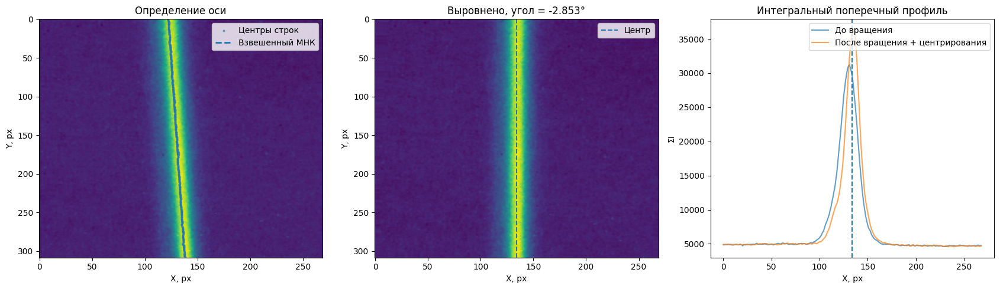

In [18]:
# ============================================================
# ЗАГРУЗКА ЭКСПЕРИМЕНТАЛЬНОГО ИЗОБРАЖЕНИЯ + CAMERA QA
# ============================================================

try:
    raw_test_image = load_image(IMAGE_SOURCE)
except Exception as exc:
    raise RuntimeError(
        "Анализ остановлен на этапе загрузки изображения. "
        "Проверьте IMAGE_SOURCE, формат файла и доступность файла.\n\n"
        f"Причина: {exc}"
    ) from exc

saturation_info = acquisition_saturation_diagnostics(IMAGE_SOURCE, raw_test_image)
print("Размер изображения:", raw_test_image.shape)
print("Диапазон интенсивности:", f"{raw_test_image.min():.6g} ... {raw_test_image.max():.6g}")
print("Saturation QA:", saturation_info)

if min(raw_test_image.shape) < 32:
    warnings.warn(f"Изображение очень мало для устойчивой Abel-реконструкции: {raw_test_image.shape}.")
if saturation_info.get("status") == "WARNING_SATURATION":
    warnings.warn(
        "В исходном integer-изображении обнаружены пиксели на полном кодовом уровне сенсора. "
        "Gaussian/Abel-результаты в этих областях могут быть смещены из-за clipping."
    )

try:
    test_image, camera_correction_info = apply_camera_corrections(
        raw_test_image,
        dark_frame=ANALYSIS_CONFIG["camera_correction"]["dark_frame"],
        flat_field=ANALYSIS_CONFIG["camera_correction"]["flat_field"],
        flat_floor=ANALYSIS_CONFIG["camera_correction"]["flat_floor"],
    )
except Exception as exc:
    raise RuntimeError(
        "Анализ остановлен на этапе camera correction.\n\n"
        f"Причина: {exc}"
    ) from exc

try:
    centered_img, correction_angle, alignment_info = align_laser_beam(
        test_image,
        threshold_ratio=0.20,
        min_snr=3.0,
        median_size=3,
        debug_plot=True
    )
except Exception as exc:
    raise RuntimeError(
        "Анализ остановлен на этапе выравнивания. "
        "По текущему изображению нельзя надёжно определить продольную ось пучка.\n\n"
        f"Причина: {exc}"
    ) from exc


=== Анализ фона и шума ===
Медианный фон:                15.392
СКО шума до:                  1.825
Обычное СКО углов:            1.789
СКО шума после:               1.297
Коэффициент подавления шума:  1.41
Максимум до обработки:        125.238
Максимум после обработки:     104.445
Gaussian sigma:                1.500



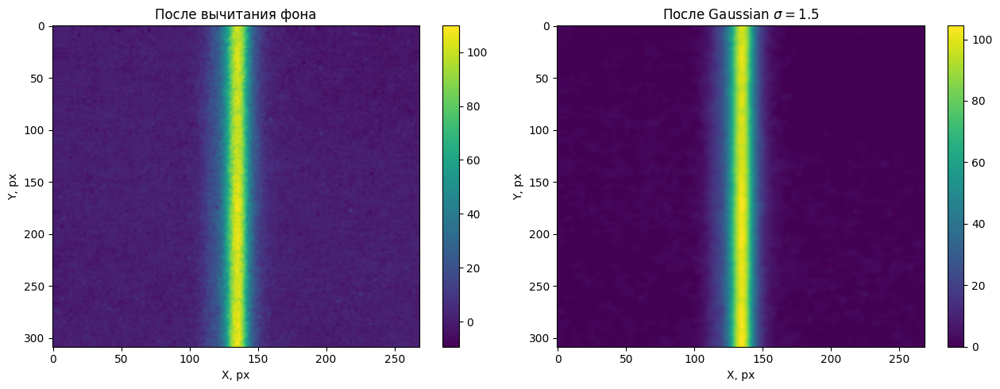

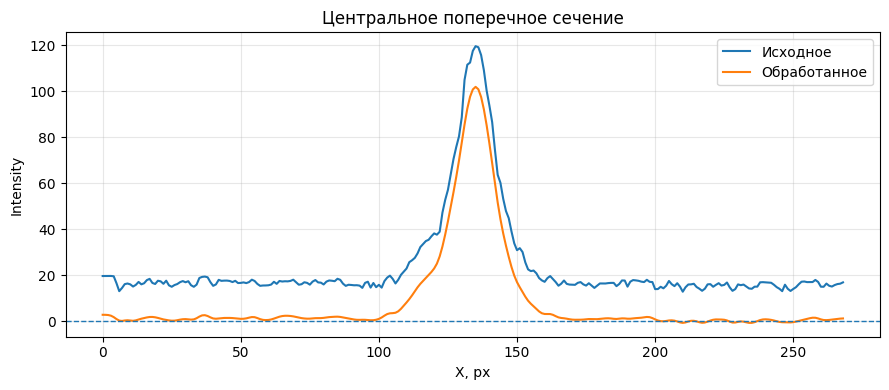

In [19]:
ready_for_abel, preprocess_info = preprocess_background_and_noise(
    centered_img,
    bg_corner_size=40,
    sigma=ANALYSIS_CONFIG["preprocessing"]["gaussian_sigma"],
    debug_plot=True
)


In [20]:
# ============================================================
# PYABEL + ENVIRONMENT REPRODUCIBILITY CHECK
# ============================================================
try:
    import abel
except ImportError as exc:
    raise ImportError(
        "PyAbel не установлен в текущем Python environment. "
        "Установите пакет 'PyAbel' один раз в окружении проекта и перезапустите kernel."
    ) from exc

import scipy
import matplotlib

print("=== SOFTWARE ENVIRONMENT ===")
print("PyAbel:", getattr(abel, "__version__", "version not exposed"))
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("PyAbel доступен.")


=== SOFTWARE ENVIRONMENT ===
PyAbel: 0.9.1
NumPy: 2.1.3
SciPy: 1.16.3
Pandas: 2.2.3
Matplotlib: 3.10.0
PyAbel доступен.


In [21]:
def find_abel_center(
    img_array,
    slice_width=10,
    debug_plot=True
):
    """
    Определяет точную вертикальную ось симметрии изображения
    для последующего Abel-преобразования.

    Поиск выполняется через PyAbel методом сравнения
    противоположных половин изображения.

    Parameters
    ----------
    img_array : np.ndarray
        Предварительно обработанное и геометрически
        выровненное изображение.

    slice_width : int
        Ширина области суммирования около оси.

    debug_plot : bool
        Показывать диагностические графики.

    Returns
    -------
    center_xy : tuple
        Координаты центра (y, x).

    center_x : float
        Точная координата Abel-оси по X.
    """

    import abel

    img_array = np.asarray(
        img_array,
        dtype=np.float64
    )

    if img_array.ndim != 2:
        raise ValueError(
            "Для поиска центра требуется 2D-массив."
        )

    if not np.all(np.isfinite(img_array)):
        raise ValueError(
            "Изображение содержит NaN или inf."
        )

    if slice_width <= 0:
        raise ValueError(
            "slice_width должен быть > 0."
        )

    # Современный API PyAbel.
    #
    # Используем только ось 1, потому что:
    #
    # axis = 0 -> вертикальное направление
    # axis = 1 -> горизонтальное направление
    #
    # Abel-ось должна проходить вертикально через изображение.
    center_xy = abel.tools.center.find_origin(
        img_array,
        method="slice",
        axes=1,
        slice_width=slice_width
    )

    center_y, center_x = center_xy

    print("=== Точный Abel-центр ===")
    print(f"Y-координата: {center_y:.4f} px")
    print(f"X-координата: {center_x:.4f} px")
    print()

    if debug_plot:

        plt.figure(
            figsize=(9, 6)
        )

        plt.imshow(
            img_array,
            cmap="viridis",
            aspect="auto"
        )

        plt.axvline(
            center_x,
            linestyle="--",
            linewidth=2,
            label=f"Abel axis = {center_x:.3f} px"
        )

        plt.xlabel("X, px")
        plt.ylabel("Y, px")

        plt.title(
            "Точная ось симметрии для Abel-преобразования"
        )

        plt.legend()
        plt.tight_layout()
        plt.show()

    return center_xy, center_x

=== Точный Abel-центр ===
Y-координата: 154.0000 px
X-координата: 134.5363 px



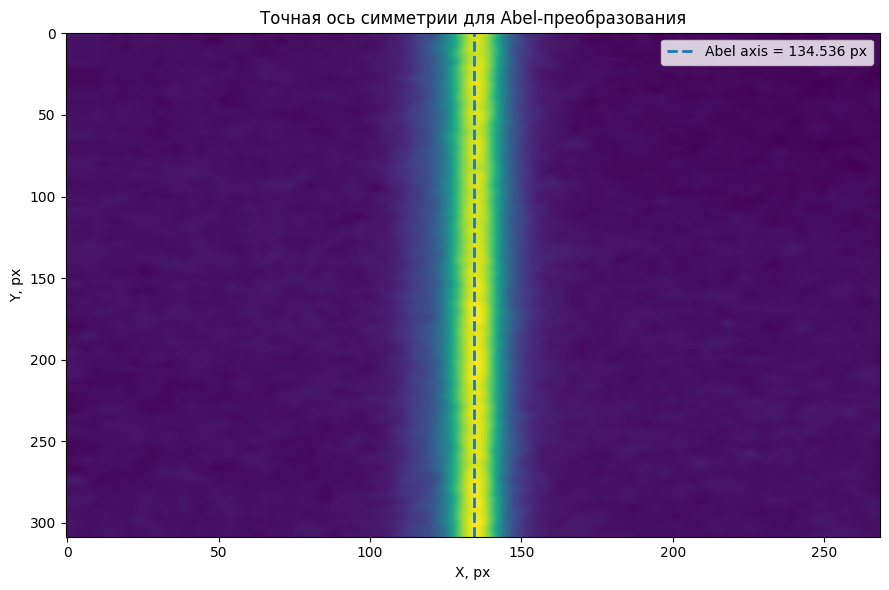

In [22]:
abel_center, abel_center_x = find_abel_center(
    ready_for_abel,
    slice_width=10,
    debug_plot=True
)

In [23]:
def compare_abel_center_methods(
    img_array,
    slice_width=10,
    debug_plot=True
):
    """
    Сравнивает несколько независимых методов определения Abel-origin.

    Анализируем только X-координату, поскольку продольная ось
    уже сделана вертикальной.
    """

    import abel

    img_array = np.asarray(
        img_array,
        dtype=np.float64
    )

    methods = [
        "image_center",
        "com",
        "convolution",
        "gaussian",
        "slice"
    ]

    results = {}

    print("=== Сравнение методов определения центра ===")

    for method in methods:

        try:

            origin = abel.tools.center.find_origin(
                img_array,
                method=method,
                axes=1,
                slice_width=slice_width
            )

            center_y, center_x = origin

            results[method] = {
                "y": center_y,
                "x": center_x
            }

            print(
                f"{method:15s} -> "
                f"X = {center_x:.5f} px"
            )

        except Exception as exc:

            results[method] = {
                "y": np.nan,
                "x": np.nan,
                "error": str(exc)
            }

            print(
                f"{method:15s} -> ERROR: {exc}"
            )

    if debug_plot:

        names = []
        values = []

        for method, result in results.items():

            if np.isfinite(result["x"]):
                names.append(method)
                values.append(result["x"])

        plt.figure(
            figsize=(9, 4)
        )

        plt.bar(
            names,
            values
        )

        plt.axhline(
            (img_array.shape[1] - 1) / 2,
            linestyle="--",
            label="Геометрический центр"
        )

        plt.xlabel("Метод")
        plt.ylabel("X-координата, px")
        plt.title(
            "Сравнение методов определения Abel-центра"
        )

        plt.xticks(
            rotation=20
        )

        plt.legend()
        plt.tight_layout()
        plt.show()

    return results

=== Сравнение методов определения центра ===
image_center    -> X = 134.00000 px
com             -> X = 130.68192 px
convolution     -> X = 134.50000 px
gaussian        -> X = 134.31336 px
slice           -> X = 134.53627 px


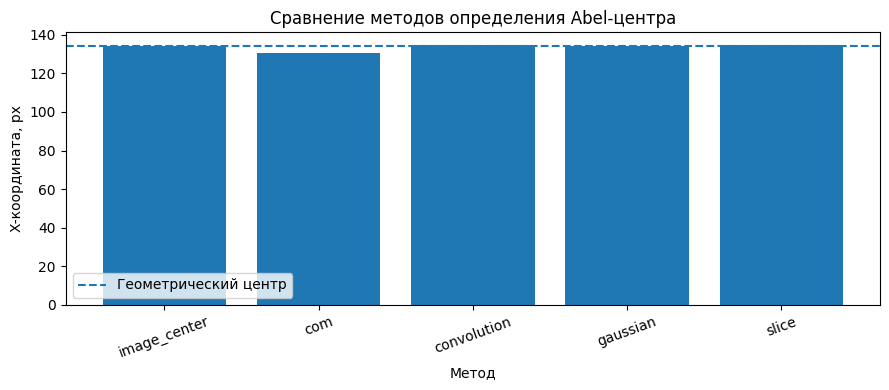

In [24]:
center_comparison = compare_abel_center_methods(
    ready_for_abel,
    slice_width=10,
    debug_plot=True
)

In [25]:
def calculate_left_right_symmetry(
    img_array,
    center_x,
    radial_limit=None,
    noise_floor=None
):
    """
    Робастная оценка симметрии изображения относительно вертикальной оси.

    В отличие от предыдущей версии:
    - не учитывает области, выходящие за границы изображения;
    - может ограничивать анализ радиусом radial_limit;
    - может исключать значения ниже шумового порога.

    Parameters
    ----------
    img_array : np.ndarray
        2D обработанное изображение.

    center_x : float
        Субпиксельная координата оси симметрии.

    radial_limit : float | None
        Максимальный радиус анализа в пикселях.
        Если None, используется весь перекрывающийся диапазон.

    noise_floor : float | None
        Шумовой порог. Если задан, слабые области не учитываются.

    Returns
    -------
    metrics : dict
        Набор метрик симметрии.
    """

    img_array = np.asarray(
        img_array,
        dtype=np.float64
    )

    if img_array.ndim != 2:
        raise ValueError(
            "Ожидалось 2D изображение."
        )

    if not np.all(np.isfinite(img_array)):
        raise ValueError(
            "Изображение содержит NaN или inf."
        )

    h, w = img_array.shape

    x = np.arange(w, dtype=np.float64)

    # Расстояние каждого пикселя от найденной оси.
    radius = np.abs(x - center_x)

    # Выбираем только точки, для которых зеркальная координата
    # также находится внутри изображения.
    mirrored_x = 2.0 * center_x - x

    valid_geometry = (
        (mirrored_x >= 0) &
        (mirrored_x <= w - 1)
    )

    if radial_limit is not None:
        if radial_limit <= 0:
            raise ValueError(
                "radial_limit должен быть > 0."
            )

        valid_geometry &= (
            radius <= radial_limit
        )

    x_valid = x[valid_geometry]
    mirrored_x_valid = mirrored_x[valid_geometry]

    # Интерполируем зеркальное изображение.
    mirrored = np.empty_like(img_array)

    for y in range(h):

        mirrored[y, valid_geometry] = np.interp(
            mirrored_x_valid,
            x,
            img_array[y]
        )

    original = img_array[:, valid_geometry]
    mirrored_valid = mirrored[:, valid_geometry]

    # ------------------------------------------------------------
    # Маска по шуму
    # ------------------------------------------------------------

    if noise_floor is not None:
        signal_mask = (
            0.5 * (
                np.abs(original) +
                np.abs(mirrored_valid)
            ) > noise_floor
        )
    else:
        signal_mask = np.ones_like(
            original,
            dtype=bool
        )

    # ------------------------------------------------------------
    # Разность
    # ------------------------------------------------------------

    difference = (
        original - mirrored_valid
    )

    signal_scale = 0.5 * (
        np.abs(original) +
        np.abs(mirrored_valid)
    )

    # Только физически информативные точки.
    diff_used = difference[signal_mask]
    signal_used = signal_scale[signal_mask]

    if diff_used.size == 0:
        raise ValueError(
            "После фильтрации не осталось информативных точек."
        )

    rms_difference = np.sqrt(
        np.mean(
            diff_used ** 2
        )
    )

    rms_signal = np.sqrt(
        np.mean(
            signal_used ** 2
        )
    )

    normalized_rms = (
        rms_difference / rms_signal
        if rms_signal > 0
        else np.inf
    )

    # ------------------------------------------------------------
    # Корреляция
    # ------------------------------------------------------------

    original_flat = original[signal_mask]
    mirrored_flat = mirrored_valid[signal_mask]

    if (
        np.std(original_flat) > 0
        and np.std(mirrored_flat) > 0
    ):
        correlation = np.corrcoef(
            original_flat,
            mirrored_flat
        )[0, 1]
    else:
        correlation = np.nan

    # ------------------------------------------------------------
    # Максимальная относительная асимметрия
    # ------------------------------------------------------------

    relative_difference = (
        np.abs(difference) /
        np.maximum(signal_scale, np.finfo(float).eps)
    )

    relative_difference_used = (
        relative_difference[signal_mask]
    )

    median_relative_difference = np.median(
        relative_difference_used
    )

    percentile95_relative_difference = np.percentile(
        relative_difference_used,
        95
    )

    metrics = {
        "normalized_rms": normalized_rms,
        "correlation": correlation,
        "median_relative_difference": median_relative_difference,
        "p95_relative_difference": percentile95_relative_difference,
        "number_of_points": diff_used.size
    }

    print("=== Проверка лево/право симметрии ===")
    print(
        f"Нормированная RMS ошибка: "
        f"{normalized_rms:.5f}"
    )

    print(
        f"Корреляция:               "
        f"{correlation:.6f}"
    )

    print(
        f"Медианная относительная "
        f"асимметрия:               "
        f"{median_relative_difference:.5f}"
    )

    print(
        f"95-й процентиль:           "
        f"{percentile95_relative_difference:.5f}"
    )

    print(
        f"Использовано точек:        "
        f"{diff_used.size}"
    )

    return metrics

In [26]:
symmetry_metrics = calculate_left_right_symmetry(
    ready_for_abel,
    center_x=abel_center_x,
    radial_limit=None,
    noise_floor=preprocess_info["noise_std_after"] * 3
)

=== Проверка лево/право симметрии ===
Нормированная RMS ошибка: 0.10861
Корреляция:               0.986099
Медианная относительная асимметрия:               0.22402
95-й процентиль:           0.98801
Использовано точек:        16936


In [27]:
def inverse_abel_basex(
    img_array,
    origin_x,
    regularization=50,
    symmetry_axis=0,
    debug_plot=True
):
    """
    Inverse Abel transform методом BASEX.

    Parameters
    ----------
    img_array : np.ndarray
        Предварительно обработанная 2D projection image.

    origin_x : float
        Найденная координата вертикальной оси симметрии.

    regularization : float
        Tikhonov regularization parameter для BASEX.

    symmetry_axis : int
        0 означает симметрию относительно вертикальной оси,
        то есть левую/правую часть изображения.

    debug_plot : bool
        Показывать результат.

    Returns
    -------
    reconstructed : np.ndarray
        Восстановленное 2D распределение I(r,z).

    transform : abel.Transform
        Объект PyAbel с дополнительной информацией.
    """

    import abel

    img_array = np.asarray(
        img_array,
        dtype=np.float64
    )

    if img_array.ndim != 2:
        raise ValueError(
            "Для Abel inversion нужен 2D-массив."
        )

    if not np.all(np.isfinite(img_array)):
        raise ValueError(
            "Входное изображение содержит NaN или inf."
        )

    if regularization < 0:
        raise ValueError(
            "regularization не может быть отрицательным."
        )

    # PyAbel принимает origin в формате (y, x).
    #
    # Мы точно знаем только X-координату,
    # поэтому Y оставляем None.
    origin = (
        None,
        float(origin_x)
    )

    print("=== Abel inversion: BASEX ===")
    print(f"Метод:               BASEX")
    print(f"Origin X:            {origin_x:.5f} px")
    print(f"Regularization:      {regularization}")
    print()

    transform = abel.Transform(
        img_array,
        direction="inverse",
        method="basex",

        # Точный найденный центр
        origin=origin,

        # Для Abel физически используем левую/правую симметрию.
        symmetry_axis=symmetry_axis,

        # Усредняем обе половины.
        symmetrize_method="average",

        # Требуется для BASEX.
        center_options={
            "odd_size": True,
            "axes": 1,
            "crop": "valid_region"
        },

        # Параметры BASEX.
        transform_options={
            "reg": regularization
        },

        recast_as_float64=True,
        verbose=True
    )

    reconstructed = transform.transform

    # ------------------------------------------------------------
    # Небольшая защита от численного отрицательного хвоста
    # ------------------------------------------------------------

    negative_fraction = np.mean(
        reconstructed < 0
    )

    min_value = np.min(
        reconstructed
    )

    max_value = np.max(
        reconstructed
    )

    print("=== Результат BASEX ===")
    print(f"Размер результата:    {reconstructed.shape}")
    print(f"Минимум:              {min_value:.6g}")
    print(f"Максимум:             {max_value:.6g}")
    print(
        f"Доля отрицательных "
        f"пикселей:             {negative_fraction:.6%}"
    )
    print()

    if debug_plot:

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(14, 5)
        )

        axes[0].imshow(
            img_array,
            cmap="viridis",
            aspect="auto"
        )

        axes[0].set_title(
            "Projection"
        )

        axes[0].set_xlabel("X, px")
        axes[0].set_ylabel("Z, px")

        im = axes[1].imshow(
            reconstructed,
            cmap="viridis",
            aspect="auto"
        )

        axes[1].set_title(
            "Inverse Abel / BASEX"
        )

        axes[1].set_xlabel("r, px")
        axes[1].set_ylabel("Z, px")

        plt.colorbar(
            im,
            ax=axes[1]
        )

        plt.tight_layout()
        plt.show()

    return reconstructed, transform

=== Abel inversion: BASEX ===
Метод:               BASEX
Origin X:            134.53627 px
Regularization:      50

Calculating inverse Abel transform using basex method - 
    image size: 309x267
Calculating inverse Abel transform using basex method - 
    image size: 309x267
A suitable basis set was not found.
A new basis set will be generated.
This may take a few minutes.
But don't worry, it will be saved to disk for future use.
Generating horizontal BASEX basis sets for n = 134, sigma = 1.0 (nbf = 134):
k = 0...50...100...134
Basis set saved for later use to
  basex_basis_134_1.0.npy
Updating regularization...
Calculating correction...
Using memory-cached basis sets
0.25 seconds
0.25 seconds
=== Результат BASEX ===
Размер результата:    (309, 267)
Минимум:              -0.102915
Максимум:             5.39767
Доля отрицательных пикселей:             29.613469%



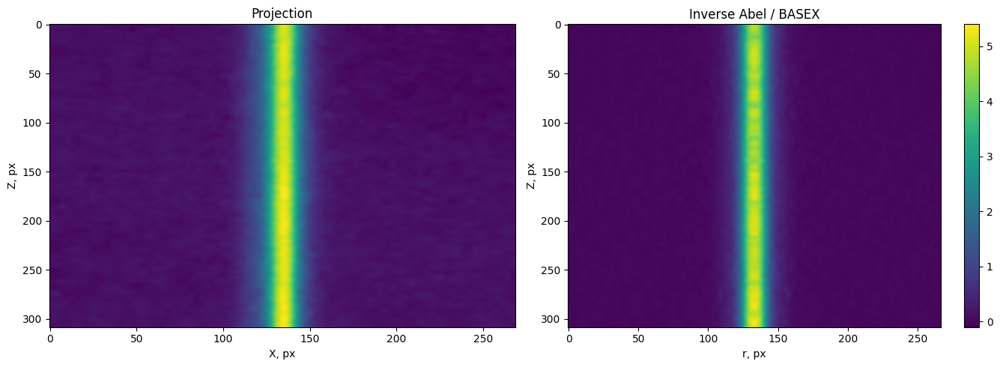

In [28]:
abel_image_basex, basex_transform = inverse_abel_basex(
    ready_for_abel,
    origin_x=abel_center_x,
    regularization=ANALYSIS_CONFIG["basex"]["regularization"],
    debug_plot=True
)

In [29]:
def basex_regularization_sweep(
    img_array,
    origin_x,
    regularization_values=None,
    debug_plot=True
):
    """
    Исследует влияние регуляризации BASEX.

    Для каждого значения рассчитывается:
        - reconstructed image
        - максимум
        - минимум
        - доля отрицательных значений
        - минимальная относительная амплитуда
        - оценка гладкости

    Это исследовательский инструмент, а не финальный auto-selector.
    """

    if regularization_values is None:
        regularization_values = [
            0,
            1,
            5,
            10,
            25,
            50,
            100,
            200
        ]

    import abel

    results = {}

    for reg in regularization_values:

        print(
            f"\n=== BASEX regularization = {reg} ==="
        )

        transform = abel.Transform(
            img_array,
            direction="inverse",
            method="basex",

            origin=(
                None,
                float(origin_x)
            ),

            symmetry_axis=0,
            symmetrize_method="average",

            center_options={
                "odd_size": True,
                "axes": 1,
                "crop": "valid_region"
            },

            transform_options={
                "reg": float(reg)
            },

            recast_as_float64=True,
            verbose=False
        )

        recon = transform.transform

        maximum = np.max(recon)
        minimum = np.min(recon)

        negative_fraction = np.mean(
            recon < 0
        )

        relative_negative_amplitude = (
            abs(minimum) / maximum
            if maximum > 0
            else np.nan
        )

        # --------------------------------------------------------
        # Оценка шероховатости.
        #
        # Используем вторую производную только по X.
        # Большие значения означают сильные локальные осцилляции.
        # --------------------------------------------------------

        second_derivative = np.diff(
            recon,
            n=2,
            axis=1
        )

        roughness = np.sqrt(
            np.mean(
                second_derivative ** 2
            )
        )

        results[reg] = {
            "transform": transform,
            "image": recon,
            "max": maximum,
            "min": minimum,
            "negative_fraction": negative_fraction,
            "relative_negative_amplitude":
                relative_negative_amplitude,
            "roughness": roughness
        }

        print(
            f"min = {minimum:.6g}"
        )

        print(
            f"max = {maximum:.6g}"
        )

        print(
            f"negative fraction = "
            f"{negative_fraction:.3%}"
        )

        print(
            f"relative negative amplitude = "
            f"{relative_negative_amplitude:.4%}"
        )

        print(
            f"roughness = "
            f"{roughness:.6g}"
        )

    if debug_plot:

        regs = np.array(
            list(results.keys()),
            dtype=float
        )

        neg_amp = np.array([
            results[r]["relative_negative_amplitude"]
            for r in results
        ])

        roughness = np.array([
            results[r]["roughness"]
            for r in results
        ])

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(14, 5)
        )

        axes[0].plot(
            regs,
            neg_amp,
            marker="o"
        )

        axes[0].set_xlabel(
            "BASEX regularization"
        )

        axes[0].set_ylabel(
            "Relative negative amplitude"
        )

        axes[0].set_title(
            "Негативный численный хвост"
        )

        axes[0].grid(
            True,
            alpha=0.3
        )

        axes[1].plot(
            regs,
            roughness,
            marker="o"
        )

        axes[1].set_xlabel(
            "BASEX regularization"
        )

        axes[1].set_ylabel(
            "Roughness"
        )

        axes[1].set_title(
            "Гладкость реконструкции"
        )

        axes[1].grid(
            True,
            alpha=0.3
        )

        plt.tight_layout()
        plt.show()

    return results


=== BASEX regularization = 0 ===
Using memory-cached basis sets
Updating regularization...
Calculating correction...
Using memory-cached basis sets
min = -0.112304
max = 6.05214
negative fraction = 31.739%
relative negative amplitude = 1.8556%
roughness = 0.0284579

=== BASEX regularization = 1 ===
Using memory-cached basis sets
Updating regularization...
Calculating correction...
Using memory-cached basis sets
min = -0.112072
max = 6.00861
negative fraction = 31.684%
relative negative amplitude = 1.8652%
roughness = 0.0280849

=== BASEX regularization = 5 ===
Using memory-cached basis sets
Updating regularization...
Calculating correction...
Using memory-cached basis sets
min = -0.111169
max = 5.90863
negative fraction = 31.526%
relative negative amplitude = 1.8815%
roughness = 0.0271283

=== BASEX regularization = 10 ===
Using memory-cached basis sets
Updating regularization...
Calculating correction...
Using memory-cached basis sets
min = -0.110092
max = 5.8209
negative fraction = 

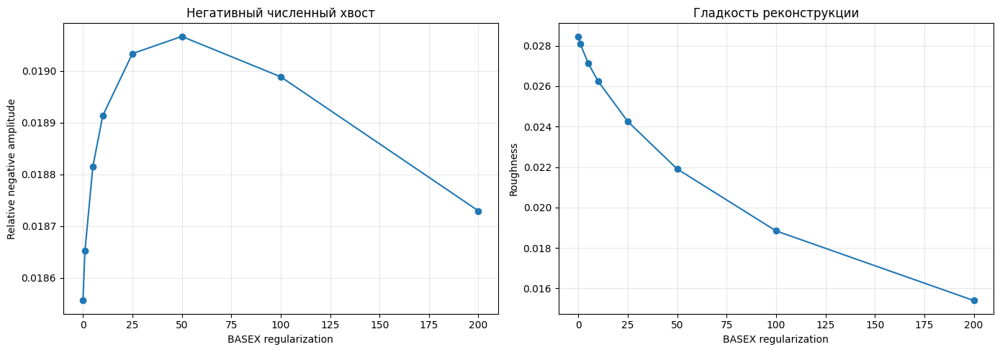

In [30]:
regularization_results = basex_regularization_sweep(
    ready_for_abel,
    origin_x=abel_center_x,
    regularization_values=[
        0,
        1,
        5,
        10,
        25,
        50,
        100,
        200
    ],
    debug_plot=True
)

In [31]:
def inverse_abel_hansenlaw(
    img_array,
    origin_x,
    symmetry_axis=0,
    debug_plot=True
):
    """
    Inverse Abel transform методом Hansen-Law.
    Используется как независимая численная проверка BASEX.
    """

    import abel

    img_array = np.asarray(
        img_array,
        dtype=np.float64
    )

    if img_array.ndim != 2:
        raise ValueError(
            "Для Abel inversion нужен 2D-массив."
        )

    if not np.all(np.isfinite(img_array)):
        raise ValueError(
            "Изображение содержит NaN или inf."
        )

    transform = abel.Transform(
        img_array,
        direction="inverse",
        method="hansenlaw",

        origin=(
            None,
            float(origin_x)
        ),

        symmetry_axis=symmetry_axis,
        symmetrize_method="average",

        center_options={
            "odd_size": True,
            "axes": 1,
            "crop": "valid_region"
        },

        recast_as_float64=True,
        verbose=True
    )

    reconstructed = transform.transform

    print("=== Результат Hansen-Law ===")
    print(
        f"Размер результата: "
        f"{reconstructed.shape}"
    )

    print(
        f"Диапазон: "
        f"{reconstructed.min():.6g} ... "
        f"{reconstructed.max():.6g}"
    )

    if debug_plot:

        plt.figure(
            figsize=(8, 5)
        )

        plt.imshow(
            reconstructed,
            cmap="viridis",
            aspect="auto"
        )

        plt.title(
            "Inverse Abel / Hansen-Law"
        )

        plt.xlabel("r, px")
        plt.ylabel("Z, px")

        plt.colorbar(
            label="Intensity"
        )

        plt.tight_layout()
        plt.show()

    return reconstructed, transform

Calculating inverse Abel transform using hansenlaw method - 
    image size: 309x267
Calculating inverse Abel transform using hansenlaw method - 
    image size: 309x267
0.02 seconds
0.02 seconds
=== Результат Hansen-Law ===
Размер результата: (309, 267)
Диапазон: -0.0549464 ... 6.09159


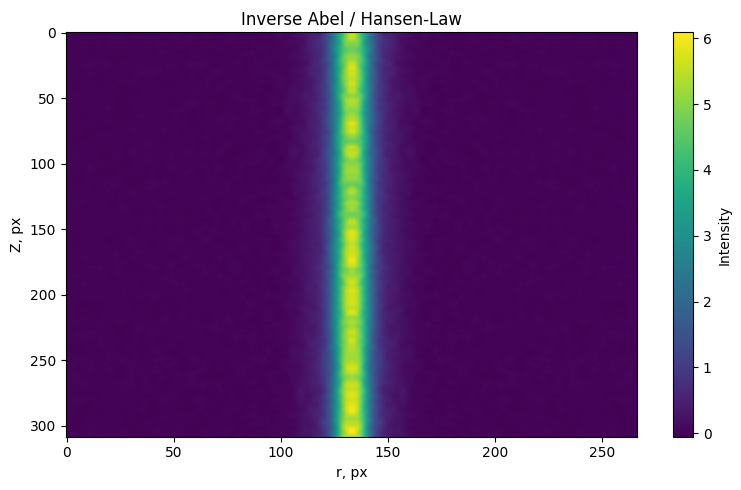

In [32]:
abel_image_hl, hl_transform = inverse_abel_hansenlaw(
    ready_for_abel,
    origin_x=abel_center_x,
    debug_plot=True
)

In [33]:
def extract_radial_profile(abel_image, z_index, center_column=None, max_radius=None, symmetric=True):
    """Извлекает I(r) из Abel-реконструкции.

    По умолчанию используется среднее левой и правой половины, что делает
    последующие Gaussian fits независимыми от произвольного выбора стороны.
    symmetric=False оставлен только как диагностический режим.
    """
    abel_image = _require_finite_2d(abel_image, "abel_image")
    h, w = abel_image.shape
    z_index = int(z_index)
    if not 0 <= z_index < h:
        raise IndexError(f"z_index должен быть в диапазоне 0...{h-1}.")

    if symmetric:
        return extract_symmetric_radial_profile(
            abel_image, z_index=z_index, center_column=center_column, max_radius=max_radius
        )[:2]

    if center_column is None:
        if w % 2 == 0:
            raise ValueError("Для одностороннего Abel-профиля ожидается нечётная ширина результата.")
        center_column = w // 2
    else:
        center_column = int(center_column)
    if not 0 <= center_column < w:
        raise ValueError("Некорректная центральная колонка.")

    profile = abel_image[z_index, center_column:].copy()
    r = np.arange(profile.size, dtype=np.float64)
    if max_radius is not None:
        max_radius = float(max_radius)
        if not np.isfinite(max_radius) or max_radius <= 0:
            raise ValueError("max_radius должен быть положительным.")
        keep = r <= max_radius
        r, profile = r[keep], profile[keep]
    if profile.size < 8:
        raise ValueError("После ограничения радиуса осталось слишком мало точек для анализа.")
    return r, profile


def extract_symmetric_radial_profile(abel_image, z_index, center_column=None, max_radius=None):
    """Строит I(r) как среднее левой и правой половины реконструкции.

    Возвращает также side_consistency — диагностику того, насколько две стороны
    независимого реконструированного профиля согласуются до усреднения.
    """
    abel_image = _require_finite_2d(abel_image, "abel_image")
    h, w = abel_image.shape
    z_index = int(z_index)
    if not 0 <= z_index < h:
        raise IndexError(f"z_index должен быть в диапазоне 0...{h-1}.")

    center = (w - 1) / 2.0 if center_column is None else float(center_column)
    if not (0 <= center <= w - 1):
        raise ValueError("Некорректный center_column.")

    available_radius = min(center, (w - 1) - center)
    if max_radius is None:
        max_radius = available_radius
    max_radius = float(max_radius)
    if max_radius <= 0:
        raise ValueError("max_radius должен быть > 0.")
    max_radius = min(max_radius, available_radius)

    r = np.arange(0.0, np.floor(max_radius) + 1.0, 1.0)
    x_left = center - r
    x_right = center + r
    row = abel_image[z_index]
    left = np.interp(x_left, np.arange(w, dtype=float), row)
    right = np.interp(x_right, np.arange(w, dtype=float), row)

    profile = 0.5 * (left + right)
    denom = max(float(np.max(np.abs(profile))), np.finfo(float).eps)
    side_diff = left - right
    normalized_rms = float(np.sqrt(np.mean(side_diff**2)) / denom)
    corr = float(np.corrcoef(left, right)[0, 1]) if left.size > 1 else np.nan

    return r, profile, {
        "left_profile": left,
        "right_profile": right,
        "normalized_rms_difference": normalized_rms,
        "correlation": corr,
        "radius_max": float(max_radius),
    }


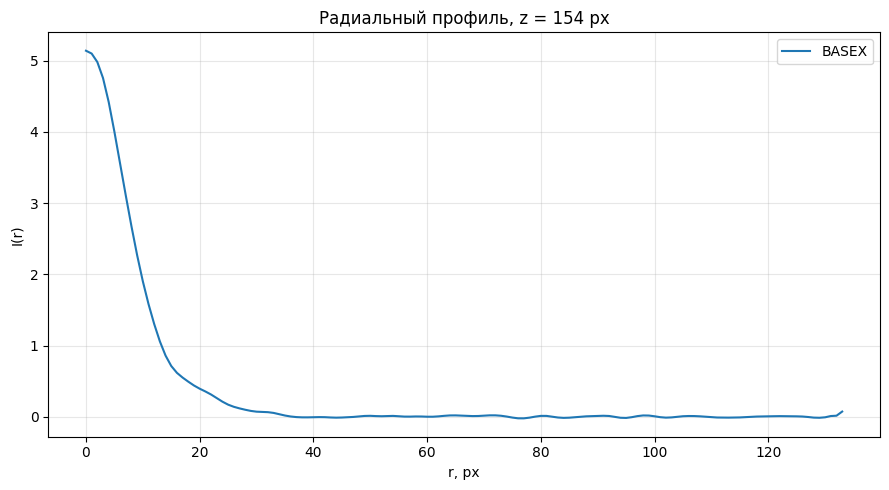

In [34]:
z0 = abel_image_basex.shape[0] // 2

r, profile = extract_radial_profile(
    abel_image_basex,
    z_index=z0
)

plt.figure(figsize=(9, 5))

plt.plot(
    r,
    profile,
    label="BASEX"
)

plt.xlabel("r, px")
plt.ylabel("I(r)")
plt.title(
    f"Радиальный профиль, z = {z0} px"
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()
plt.tight_layout()
plt.show()

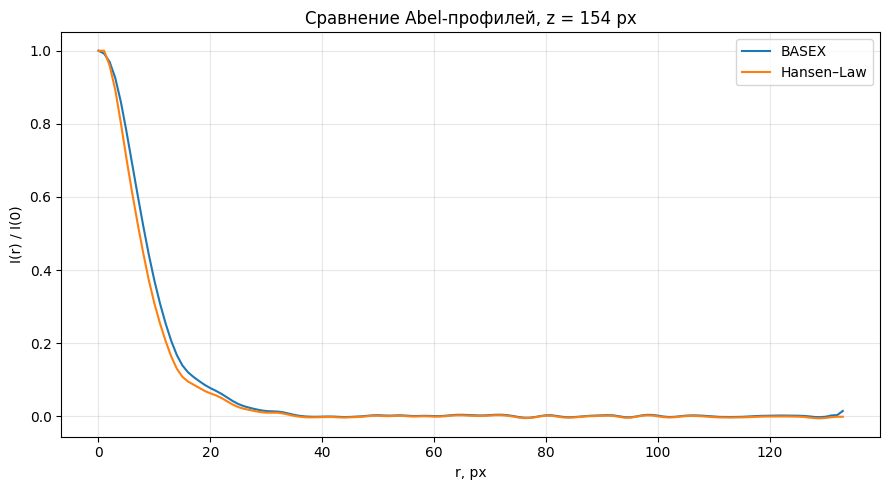

In [35]:
r_basex, profile_basex = extract_radial_profile(
    abel_image_basex,
    z_index=z0
)

r_hl, profile_hl = extract_radial_profile(
    abel_image_hl,
    z_index=z0
)

# Нормировка на максимум.
profile_basex_norm = (
    profile_basex /
    np.max(profile_basex)
)

profile_hl_norm = (
    profile_hl /
    np.max(profile_hl)
)

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    r_basex,
    profile_basex_norm,
    label="BASEX"
)

plt.plot(
    r_hl,
    profile_hl_norm,
    label="Hansen–Law"
)

plt.xlabel("r, px")
plt.ylabel("I(r) / I(0)")
plt.title(
    f"Сравнение Abel-профилей, z = {z0} px"
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()
plt.tight_layout()
plt.show()

In [36]:
def fit_gaussian_radial_profile(
    r,
    profile,
    fit_fraction=0.05,
    robust=True,
    r0_max=3.0
):
    """
    Gaussian fit радиального профиля:

        I(r) = B + A * exp(-(r-r0)^2 / (2*sigma^2))

    Дополнительно рассчитываются:

        R_1/e
        R_1/e²
        D_1/e
        D_1/e²

        Gaussian beam radius w = R_1/e² = 2*sigma
        Gaussian beam diameter 2w = D_1/e²

        FWHM

        R²_signal
        R²_full

        RMSE_signal
        RMSE_full

        NRMSE_full
        max_abs_residual_full

    ВАЖНО:
    R²_signal показывает качество fit только в области,
    использованной оптимизатором.

    R²_full показывает качество Gaussian относительно
    всего доступного радиального профиля.
    """

    r = np.asarray(
        r,
        dtype=np.float64
    )

    profile = np.asarray(
        profile,
        dtype=np.float64
    )

    # ============================================================
    # Проверки входных данных
    # ============================================================

    if r.ndim != 1 or profile.ndim != 1:
        raise ValueError(
            "r и profile должны быть 1D."
        )

    if r.size != profile.size:
        raise ValueError(
            "r и profile должны иметь одинаковый размер."
        )

    if r.size < 8:
        raise ValueError(
            "Слишком мало точек для Gaussian fit."
        )

    if not np.all(np.isfinite(r)):
        raise ValueError(
            "r содержит NaN/inf."
        )

    if not np.all(np.isfinite(profile)):
        raise ValueError(
            "profile содержит NaN/inf."
        )

    if not 0 < fit_fraction < 1:
        raise ValueError(
            "fit_fraction должен быть между 0 и 1."
        )

    if r0_max <= 0:
        raise ValueError(
            "r0_max должен быть > 0."
        )

    # ============================================================
    # 1. Начальные оценки
    # ============================================================

    peak_index = int(
        np.argmax(profile)
    )

    peak_value = float(
        profile[peak_index]
    )

    if peak_value <= 0:
        raise ValueError(
            "Профиль не содержит положительного сигнала."
        )

    # ------------------------------------------------------------
    # Оценка baseline по дальнему хвосту
    # ------------------------------------------------------------

    tail_start = max(
        int(0.8 * len(profile)),
        peak_index + 5
    )

    tail = profile[
        tail_start:
    ]

    if tail.size > 0:

        baseline_guess = float(
            np.median(tail)
        )

    else:

        baseline_guess = 0.0

    signal = (
        profile -
        baseline_guess
    )

    amplitude_guess = max(
        float(np.max(signal)),
        np.finfo(float).eps
    )

    # ============================================================
    # 2. Первичная оценка sigma
    # ============================================================

    target = (
        baseline_guess +
        amplitude_guess / np.e
    )

    above = np.where(
        profile >= target
    )[0]

    if above.size >= 2:

        radius_guess = float(
            r[above[-1]]
        )

    else:

        radius_guess = max(
            1.0,
            float(
                r[
                    min(
                        peak_index + 3,
                        len(r) - 1
                    )
                ]
            )
        )

    sigma_guess = max(
        radius_guess / np.sqrt(2.0),
        0.5
    )

    # ============================================================
    # 3. Оценка r0
    # ============================================================

    r0_lower = 0.0

    r0_upper = min(
        float(r[-1]),
        float(r0_max)
    )

    if r0_upper <= r0_lower:
        raise ValueError(
            "Недостаточный радиальный диапазон "
            "для оценки r0."
        )

    eps = min(
        1e-6,
        0.1 * max(r0_upper, 1.0)
    )

    r0_guess = np.clip(
        float(r[peak_index]),
        r0_lower + eps,
        r0_upper - eps
    )

    # ============================================================
    # 4. Fit mask
    # ============================================================

    threshold = (
        baseline_guess +
        fit_fraction * amplitude_guess
    )

    fit_mask = (
        profile >= threshold
    )

    if np.count_nonzero(
        fit_mask
    ) < 8:

        raise ValueError(
            "Недостаточно точек для Gaussian fit."
        )

    fit_r = r[
        fit_mask
    ]

    fit_y = profile[
        fit_mask
    ]

    # ============================================================
    # 5. Gaussian model
    # ============================================================

    def gaussian_model(
        params,
        x
    ):

        amplitude, r0, sigma, baseline = (
            params
        )

        return (
            baseline +
            amplitude *
            np.exp(
                -(
                    (x - r0) ** 2
                ) /
                (
                    2.0 *
                    sigma ** 2
                )
            )
        )

    def residuals(params):

        return (
            gaussian_model(
                params,
                fit_r
            )
            -
            fit_y
        )

    initial = np.array([
        amplitude_guess,
        r0_guess,
        sigma_guess,
        baseline_guess
    ])

    sigma_upper = max(
        2.0 * float(r[-1]),
        1.0
    )

    lower = np.array([
        0.0,
        r0_lower,
        0.05,
        -np.inf
    ])

    upper = np.array([
        np.inf,
        r0_upper,
        sigma_upper,
        np.inf
    ])

    # ============================================================
    # 6. Optimization
    # ============================================================

    if robust:

        fit = least_squares(
            residuals,
            x0=initial,
            bounds=(
                lower,
                upper
            ),
            loss="soft_l1",
            f_scale=max(
                np.std(fit_y),
                1e-6
            )
        )

    else:

        fit = least_squares(
            residuals,
            x0=initial,
            bounds=(
                lower,
                upper
            )
        )

    if not fit.success:

        raise RuntimeError(
            f"Gaussian fit не сошёлся: "
            f"{fit.message}"
        )

    amplitude, r0, sigma_r, baseline = (
        fit.x
    )

    # ============================================================
    # 7. Физические параметры Gaussian
    # ============================================================

    # Уровень 1/e
    radius_1e = (
        np.sqrt(2.0) *
        sigma_r
    )

    # Уровень 1/e²
    radius_1e2 = (
        2.0 *
        sigma_r
    )

    diameter_1e = (
        2.0 *
        radius_1e
    )

    diameter_1e2 = (
        2.0 *
        radius_1e2
    )

    # Стандартный Gaussian beam radius:
    #
    # I(r) = I0 exp(-2r²/w²)
    #
    # => w = 2 sigma
    beam_radius_w = (
        2.0 *
        sigma_r
    )

    beam_diameter_2w = (
        2.0 *
        beam_radius_w
    )

    fwhm = (
        2.0 *
        np.sqrt(
            2.0 * np.log(2.0)
        )
        *
        sigma_r
    )

    # Реальный максимум fitted Gaussian:
    peak_intensity = (
        baseline +
        amplitude
    )

    # ============================================================
    # 8. Полный fitted profile
    # ============================================================

    fitted = gaussian_model(
        fit.x,
        r
    )

    residual = (
        profile -
        fitted
    )

    fitted_used = gaussian_model(
        fit.x,
        fit_r
    )

    # ============================================================
    # 9. Метрики качества
    # ============================================================

    def calculate_metrics(
        y,
        y_fit
    ):

        residual_local = (
            y -
            y_fit
        )

        ss_res = np.sum(
            residual_local ** 2
        )

        ss_tot = np.sum(
            (
                y -
                np.mean(y)
            ) ** 2
        )

        if ss_tot > 0:

            r_squared = (
                1.0 -
                ss_res /
                ss_tot
            )

        else:

            r_squared = np.nan

        rmse = np.sqrt(
            np.mean(
                residual_local ** 2
            )
        )

        data_range = (
            np.max(y) -
            np.min(y)
        )

        if data_range > 0:

            nrmse = (
                rmse /
                data_range
            )

        else:

            nrmse = np.nan

        max_abs_residual = np.max(
            np.abs(
                residual_local
            )
        )

        return (
            r_squared,
            rmse,
            nrmse,
            max_abs_residual
        )

    # Только точки, участвовавшие в fit
    (
        r2_signal,
        rmse_signal,
        nrmse_signal,
        max_residual_signal
    ) = calculate_metrics(
        fit_y,
        fitted_used
    )

    # Весь радиальный профиль
    (
        r2_full,
        rmse_full,
        nrmse_full,
        max_residual_full
    ) = calculate_metrics(
        profile,
        fitted
    )

    # ============================================================
    # 10. Result
    # ============================================================

    return {

        "success":
            bool(fit.success),

        "message":
            fit.message,

        # -----------------------------
        # Gaussian parameters
        # -----------------------------

        "amplitude":
            amplitude,

        "peak_intensity":
            peak_intensity,

        "r0":
            r0,

        "sigma":
            sigma_r,

        "baseline":
            baseline,

        # -----------------------------
        # Widths
        # -----------------------------

        "radius_1e":
            radius_1e,

        "radius_1e2":
            radius_1e2,

        "diameter_1e":
            diameter_1e,

        "diameter_1e2":
            diameter_1e2,

        # Standard Gaussian beam
        "beam_radius_w":
            beam_radius_w,

        "beam_diameter_2w":
            beam_diameter_2w,

        "fwhm":
            fwhm,

        # -----------------------------
        # Quality
        # -----------------------------

        "r_squared":
            r2_signal,

        "r_squared_signal":
            r2_signal,

        "r_squared_full":
            r2_full,

        "rmse":
            rmse_signal,

        "rmse_signal":
            rmse_signal,

        "rmse_full":
            rmse_full,

        "nrmse_signal":
            nrmse_signal,

        "nrmse_full":
            nrmse_full,

        "max_abs_residual_signal":
            max_residual_signal,

        "max_abs_residual_full":
            max_residual_full,

        # -----------------------------
        # Fit internals
        # -----------------------------

        "fit_mask":
            fit_mask,

        "r":
            r,

        "profile":
            profile,

        "fitted_profile":
            fitted,

        "residual":
            residual,

        "optimizer_cost":
            fit.cost,

        "optimizer_optimality":
            fit.optimality
    }

In [37]:
gaussian_result = fit_gaussian_radial_profile(
    r_basex,
    profile_basex,
    fit_fraction=0.05,
    robust=True
)

print("=== Gaussian fit ===")
print(
    f"r0             = "
    f"{gaussian_result['r0']:.4f} px"
)

print(
    f"sigma          = "
    f"{gaussian_result['sigma']:.4f} px"
)

print(
    f"R_1/e          = "
    f"{gaussian_result['radius_1e']:.4f} px"
)

print(
    f"R_1/e²         = "
    f"{gaussian_result['radius_1e2']:.4f} px"
)

print(
    f"D_1/e          = "
    f"{gaussian_result['diameter_1e']:.4f} px"
)

print(
    f"D_1/e²         = "
    f"{gaussian_result['diameter_1e2']:.4f} px"
)

print(
    f"FWHM           = "
    f"{gaussian_result['fwhm']:.4f} px"
)

print(
    f"R²             = "
    f"{gaussian_result['r_squared']:.6f}"
)

print(
    f"RMSE           = "
    f"{gaussian_result['rmse']:.6g}"
)

=== Gaussian fit ===
r0             = 0.0990 px
sigma          = 6.6186 px
R_1/e          = 9.3602 px
R_1/e²         = 13.2373 px
D_1/e          = 18.7203 px
D_1/e²         = 26.4745 px
FWHM           = 15.5857 px
R²             = 0.999770
RMSE           = 0.0266367


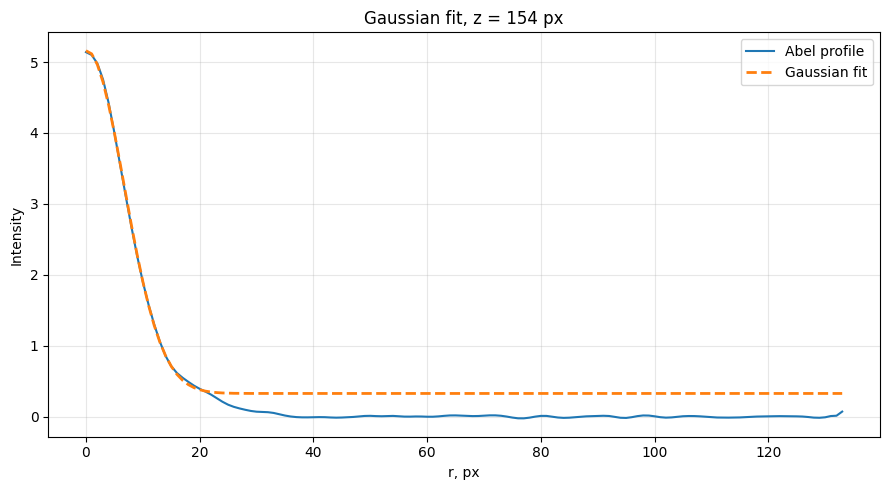

In [38]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    r_basex,
    profile_basex,
    label="Abel profile"
)

plt.plot(
    r_basex,
    gaussian_result["fitted_profile"],
    linestyle="--",
    linewidth=2,
    label="Gaussian fit"
)

plt.xlabel("r, px")
plt.ylabel("Intensity")
plt.title(
    f"Gaussian fit, z = {z0} px"
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()
plt.tight_layout()
plt.show()

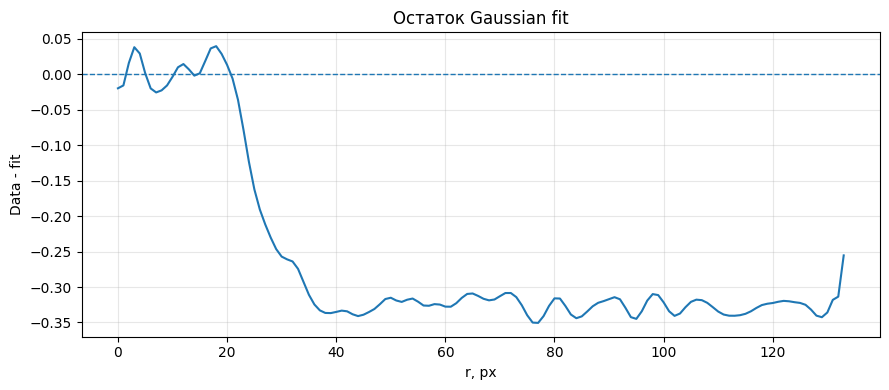

In [39]:
plt.figure(
    figsize=(9, 4)
)

plt.plot(
    r_basex,
    gaussian_result["profile"] -
    gaussian_result["fitted_profile"]
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("r, px")
plt.ylabel("Data - fit")

plt.title(
    "Остаток Gaussian fit"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [40]:
result = {
    "raw_image": ...,
    "aligned_image": ...,
    "processed_image": ...,

    "axis": {
        "angle_deg": ...,
        "slope": ...,
        "rms": ...
    },

    "center": {
        "x": ...,
        "method": "slice"
    },

    "preprocessing": {
        "gaussian_sigma": 1.5,
        "background": ...
    },

    "abel": {
        "method": "basex",
        "regularization": 50,
        "basis_sigma": 1.0
    },

    "reconstruction": ...,

    "profile": ...,

    "fit": ...
}

In [41]:
# ============================================================
# ЕДИНАЯ КОНФИГУРАЦИЯ — ПРОВЕРКА
# ============================================================
print("=== ANALYSIS CONFIG ===")
print("Z sampling mode:", ANALYSIS_CONFIG["z_sampling"]["mode"])
print("Z points:", ANALYSIS_CONFIG["z_sampling"]["n_points"])
print("Z margin:", ANALYSIS_CONFIG["z_sampling"]["margin"])
print("Preprocessing sigma:", ANALYSIS_CONFIG["preprocessing"]["gaussian_sigma"])
print("BASEX regularization:", ANALYSIS_CONFIG["basex"]["regularization"])


=== ANALYSIS CONFIG ===
Z sampling mode: dense
Z points: 61
Z margin: 10
Preprocessing sigma: 1.5
BASEX regularization: 50


In [42]:
def make_z_sampling(
    n_z,
    n_points=61,
    margin=10
):
    """
    Создаёт равномерную выборку продольных координат.

    Parameters
    ----------
    n_z : int
        Полное количество доступных продольных строк.

    n_points : int
        Количество выбираемых z-сечений.

    margin : int
        Сколько строк исключить с каждого края.

    Returns
    -------
    np.ndarray
        Отсортированные уникальные z-индексы.
    """

    n_z = int(n_z)
    n_points = int(n_points)
    margin = int(margin)

    if n_z < 3:
        raise ValueError(
            "n_z должен быть >= 3."
        )

    if n_points < 2:
        raise ValueError(
            "n_points должен быть >= 2."
        )

    if margin < 0:
        raise ValueError(
            "margin не может быть отрицательным."
        )

    first = margin
    last = n_z - 1 - margin

    if first > last:
        raise ValueError(
            f"Слишком большой margin={margin}. "
            f"Для изображения с n_z={n_z} "
            f"допустимый диапазон margin: "
            f"0...{(n_z - 1) // 2}."
        )

    available_positions = (
        last - first + 1
    )

    if n_points > available_positions:
        raise ValueError(
            f"Нельзя выбрать {n_points} уникальных "
            f"z-позиций из {available_positions} доступных. "
            f"Уменьшите n_points или margin."
        )

    positions = np.rint(
        np.linspace(
            first,
            last,
            n_points
        )
    ).astype(int)

    positions = np.unique(
        positions
    )

    if len(positions) != n_points:
        raise RuntimeError(
            "При округлении координат появились дубли. "
            "Уменьшите n_points."
        )

    return positions


def get_z_positions(
    n_z,
    mode="dense",
    n_points=61,
    margin=10
):
    """
    Унифицированный выбор продольных координат.

    mode:
        "diagnostic" -> 15 точек
        "dense"      -> n_points
        "full"       -> все допустимые точки
    """

    mode = str(mode).lower()

    if mode == "diagnostic":

        return make_z_sampling(
            n_z=n_z,
            n_points=min(15, n_z - 2 * margin),
            margin=margin
        )

    elif mode == "dense":

        return make_z_sampling(
            n_z=n_z,
            n_points=n_points,
            margin=margin
        )

    elif mode == "full":

        first = int(margin)
        last = int(n_z - 1 - margin)

        if first > last:
            raise ValueError(
                f"margin={margin} слишком велик "
                f"для n_z={n_z}."
            )

        return np.arange(
            first,
            last + 1,
            dtype=int
        )

    else:

        raise ValueError(
            "Неизвестный режим z sampling. "
            "Используйте: "
            "'diagnostic', 'dense' или 'full'."
        )

In [43]:
# ============================================================
# ПРОДОЛЬНАЯ ВЫБОРКА
# ============================================================

z_positions = get_z_positions(
    n_z=abel_image_basex.shape[0],
    mode=ANALYSIS_CONFIG["z_sampling"]["mode"],
    n_points=ANALYSIS_CONFIG["z_sampling"]["n_points"],
    margin=ANALYSIS_CONFIG["z_sampling"]["margin"]
)

print("=== Z SAMPLING ===")
print(
    f"Режим: {ANALYSIS_CONFIG['z_sampling']['mode']}"
)

print(
    f"Количество сечений: {len(z_positions)}"
)

print(
    f"Диапазон: "
    f"{z_positions[0]} ... {z_positions[-1]} px"
)

print(
    "Первые позиции:",
    z_positions[:10]
)

print(
    "Последние позиции:",
    z_positions[-10:]
)

=== Z SAMPLING ===
Режим: dense
Количество сечений: 61
Диапазон: 10 ... 298 px
Первые позиции: [10 15 20 24 29 34 39 44 48 53]
Последние позиции: [255 260 264 269 274 279 284 288 293 298]


In [44]:
def analyze_all_z_profiles(
    abel_image,
    z_positions,
    fit_fraction=0.05,
    robust=True,
    r0_max=3.0
):
    """
    Анализирует Gaussian-профиль для каждой z-позиции.

    Неудачные fits не останавливают весь анализ.
    Для них численные параметры записываются как NaN.
    """

    z_positions = np.asarray(
        z_positions,
        dtype=int
    )

    results = []

    metric_names = [
        "amplitude",
        "peak_intensity",
        "r0",
        "sigma",
        "baseline",

        "radius_1e",
        "radius_1e2",

        "diameter_1e",
        "diameter_1e2",

        "beam_radius_w",
        "beam_diameter_2w",

        "fwhm",

        "r_squared",
        "r_squared_signal",
        "r_squared_full",

        "rmse",
        "rmse_signal",
        "rmse_full",

        "nrmse_signal",
        "nrmse_full",

        "max_abs_residual_signal",
        "max_abs_residual_full"
    ]

    for z_index in z_positions:

        result = {
            "z_index": int(z_index),
            "success": False,
            "error": None
        }

        # Заполняем числовые поля NaN,
        # чтобы последующие графики были устойчивыми.
        for name in metric_names:
            result[name] = np.nan

        try:

            r, profile = (
                extract_radial_profile(
                    abel_image,
                    z_index=z_index
                )
            )

            fit_result = (
                fit_gaussian_radial_profile(
                    r,
                    profile,
                    fit_fraction=fit_fraction,
                    robust=robust,
                    r0_max=r0_max
                )
            )

            result.update(
                fit_result
            )

            result["success"] = True

        except Exception as exc:

            result["error"] = str(exc)

            print(
                f"Предупреждение: "
                f"z={z_index}: {exc}"
            )

        results.append(
            result
        )

    valid_count = sum(
        item["success"]
        for item in results
    )

    failed_count = (
        len(results) -
        valid_count
    )

    print()
    print("=== BATCH GAUSSIAN ANALYSIS ===")
    print(
        f"Всего сечений:       {len(results)}"
    )
    print(
        f"Успешных fits:       {valid_count}"
    )
    print(
        f"Неудачных fits:      {failed_count}"
    )

    if valid_count == 0:

        raise RuntimeError(
            "Ни одного успешного Gaussian fit."
        )

    return results

In [45]:
# ============================================================
# BASEX: longitudinal Gaussian analysis
# ============================================================

profiles_basex = analyze_all_z_profiles(
    abel_image_basex,
    z_positions,
    fit_fraction=ANALYSIS_CONFIG["gaussian_fit"]["fit_fraction"],
    robust=ANALYSIS_CONFIG["gaussian_fit"]["robust"],
    r0_max=ANALYSIS_CONFIG["gaussian_fit"]["r0_max"]
)

# ============================================================
# Hansen–Law: longitudinal Gaussian analysis
# ============================================================

profiles_hl = analyze_all_z_profiles(
    abel_image_hl,
    z_positions,
    fit_fraction=ANALYSIS_CONFIG["gaussian_fit"]["fit_fraction"],
    robust=ANALYSIS_CONFIG["gaussian_fit"]["robust"],
    r0_max=ANALYSIS_CONFIG["gaussian_fit"]["r0_max"]
)


=== BATCH GAUSSIAN ANALYSIS ===
Всего сечений:       61
Успешных fits:       61
Неудачных fits:      0

=== BATCH GAUSSIAN ANALYSIS ===
Всего сечений:       61
Успешных fits:       61
Неудачных fits:      0


In [46]:
def plot_beam_parameters(
    profile_results,
    pixel_size=None,
    unit="px",
    radiometry=None,
    figsize=(12, 6),
    dpi=150
):
    """Продольные параметры с явным отображением физических единиц."""
    valid = np.array([item.get("success", False) for item in profile_results], dtype=bool)
    z = np.array([item["z_index"] for item in profile_results], dtype=float)

    def get_array(name):
        return np.array([item.get(name, np.nan) for item in profile_results], dtype=float)

    peak = get_array("peak_intensity")
    sigma = get_array("sigma")
    w = get_array("beam_radius_w")
    d1e = get_array("diameter_1e")
    d1e2 = get_array("diameter_1e2")
    fwhm = get_array("fwhm")
    r2_signal = get_array("r_squared_signal")
    r2_full = get_array("r_squared_full")
    nrmse_full = get_array("nrmse_full")

    if pixel_size is not None:
        z_plot = z * pixel_size
        sigma_plot = sigma * pixel_size
        w_plot = w * pixel_size
        d1e_plot = d1e * pixel_size
        d1e2_plot = d1e2 * pixel_size
        fwhm_plot = fwhm * pixel_size
        unit_text = unit
        x_label = f"Продольная координата, {unit}"
        width_label = f"Диаметр, {unit}"
        radius_label = f"Gaussian beam radius w, {unit}"
        sigma_label = f"Gaussian sigma, {unit}"
    else:
        z_plot = z; sigma_plot = sigma; w_plot = w; d1e_plot = d1e; d1e2_plot = d1e2; fwhm_plot = fwhm
        unit_text = "px"; x_label = "Продольная координата, px"; width_label = "Диаметр, px"; radius_label = "Gaussian beam radius w, px"; sigma_label = "Gaussian sigma, px"

    peak_plot = radiometric_convert_intensity(peak, radiometry)
    intensity_label = "Peak intensity, W/cm²" if radiometry and radiometry.get("enabled", False) else "Fitted peak intensity / relative signal"

    for yvals, ylabel, title, extra in [
        (peak_plot, intensity_label, "Продольная эволюция максимальной интенсивности", {}),
        (None, width_label, "Продольная эволюция ширины пучка", {"widths": True}),
        (w_plot, radius_label, "Gaussian beam radius w(z)", {}),
        (sigma_plot, sigma_label, "Gaussian sigma(z)", {}),
        (r2_signal, r"$R^2$", "Качество Gaussian approximation", {"quality": True}),
        (nrmse_full, "NRMSE", "Нормированная ошибка Gaussian fit", {}),
    ]:
        plt.figure(figsize=figsize, dpi=dpi)
        if extra.get("widths"):
            plt.plot(z_plot, d1e_plot, marker="o", markersize=3, label="D 1/e")
            plt.plot(z_plot, d1e2_plot, marker="o", markersize=3, label="D 1/e² = 2w")
            plt.plot(z_plot, fwhm_plot, marker="o", markersize=3, label="FWHM")
            plt.legend()
        elif extra.get("quality"):
            plt.plot(z_plot, r2_signal, marker="o", markersize=3, label=r"$R^2_{signal}$")
            plt.plot(z_plot, r2_full, marker="o", markersize=3, label=r"$R^2_{full}$")
            finite_r2 = np.concatenate([r2_signal[np.isfinite(r2_signal)], r2_full[np.isfinite(r2_full)]])
            if finite_r2.size:
                lo, hi = np.min(finite_r2), np.max(finite_r2); span=max(hi-lo,0.01)
                plt.ylim(lo-0.1*span, min(1.01,hi+0.1*span))
            plt.legend()
        else:
            plt.plot(z_plot, yvals, marker="o", markersize=3)
        plt.xlabel(x_label)
        plt.ylabel(ylabel)
        plt.title(title)
        plt.grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()

    return {"z": z, "valid": valid, "peak_intensity": peak, "sigma": sigma, "beam_radius_w": w,
            "diameter_1e": d1e, "diameter_1e2": d1e2, "fwhm": fwhm,
            "r_squared_signal": r2_signal, "r_squared_full": r2_full, "nrmse_full": nrmse_full,
            "z_plot": z_plot, "unit": unit_text}


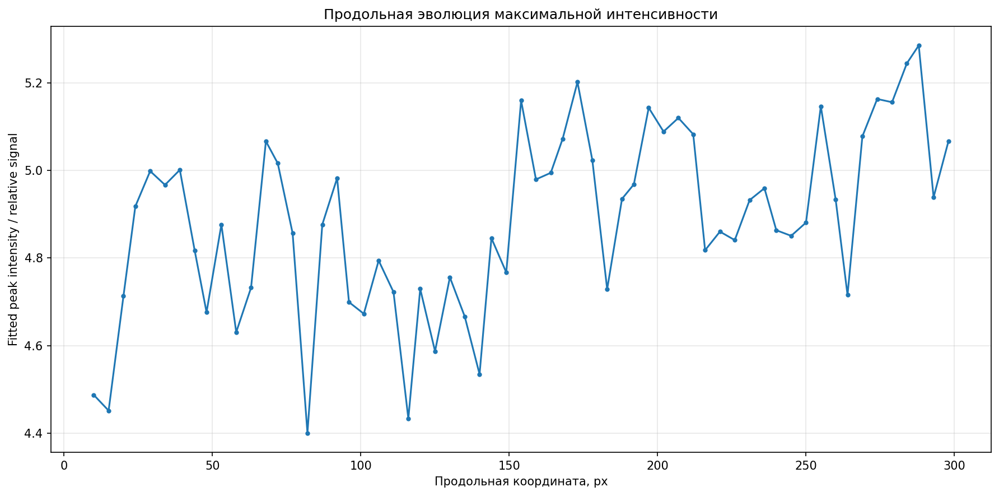

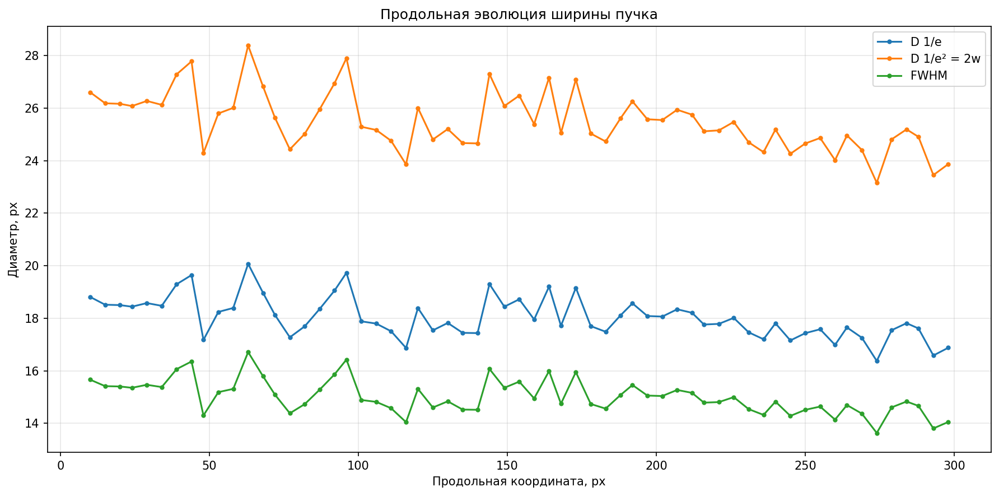

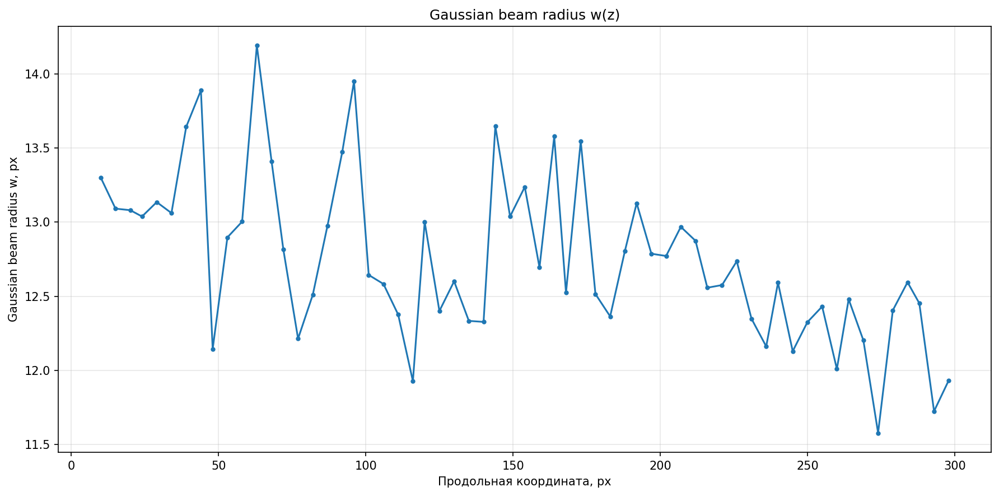

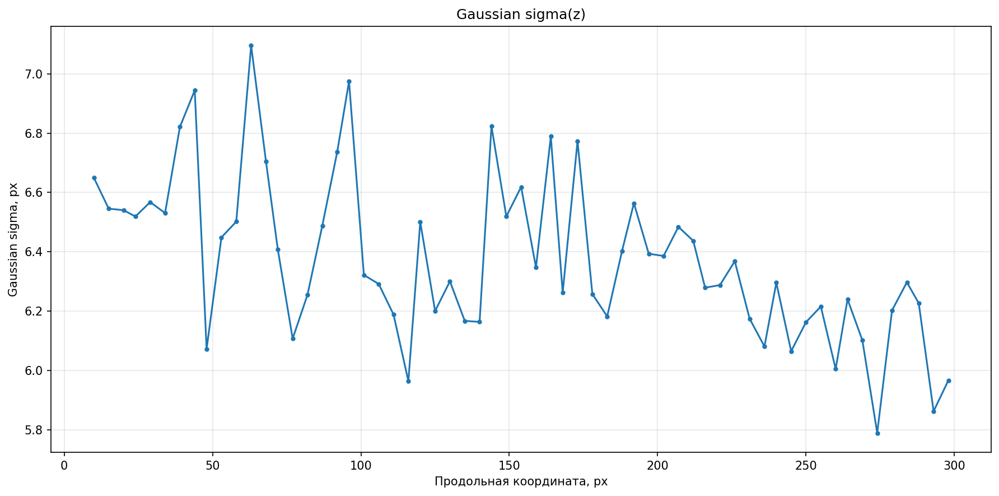

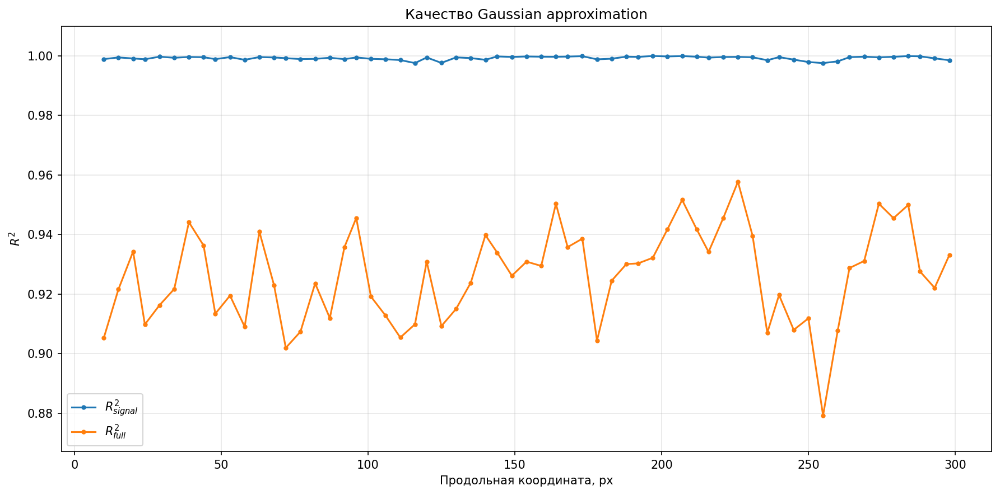

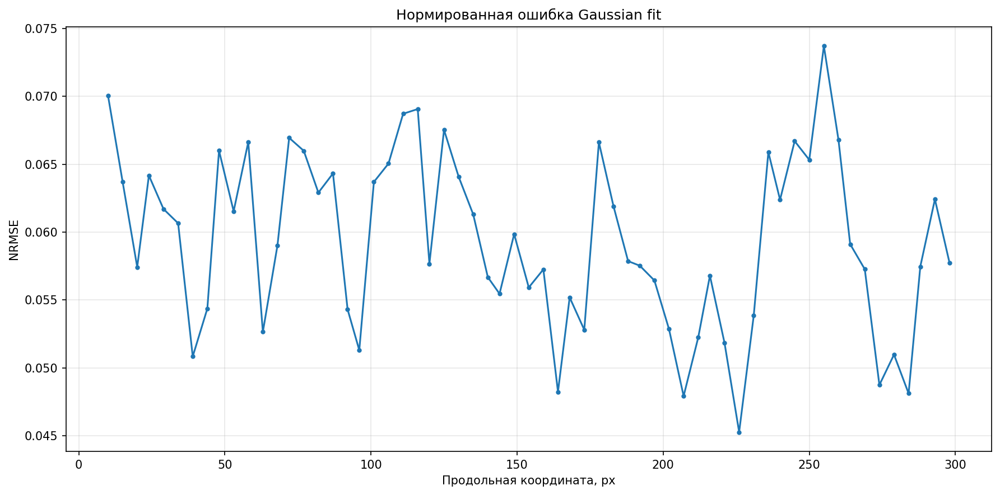

In [47]:
beam_parameters_basex = plot_beam_parameters(
    profiles_basex,
    figsize=ANALYSIS_CONFIG["plots"]["figsize"],
    dpi=ANALYSIS_CONFIG["plots"]["dpi"]
)

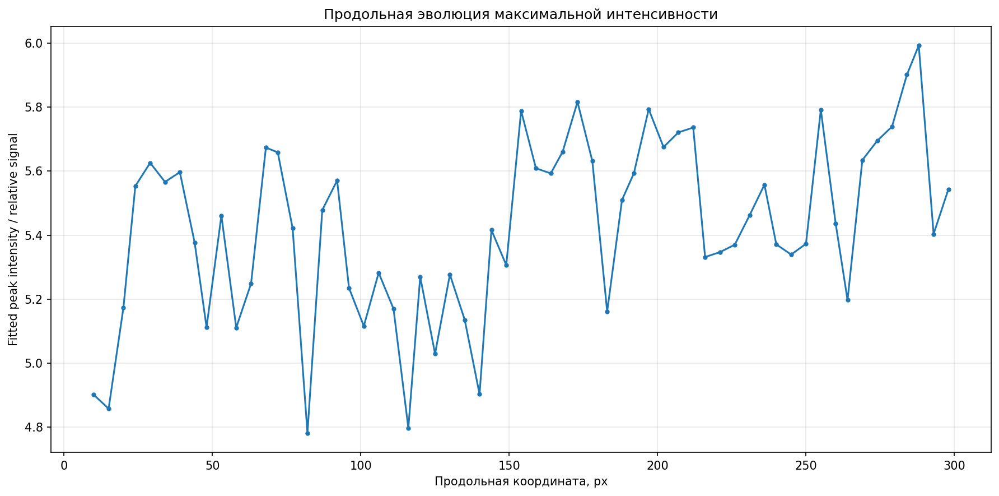

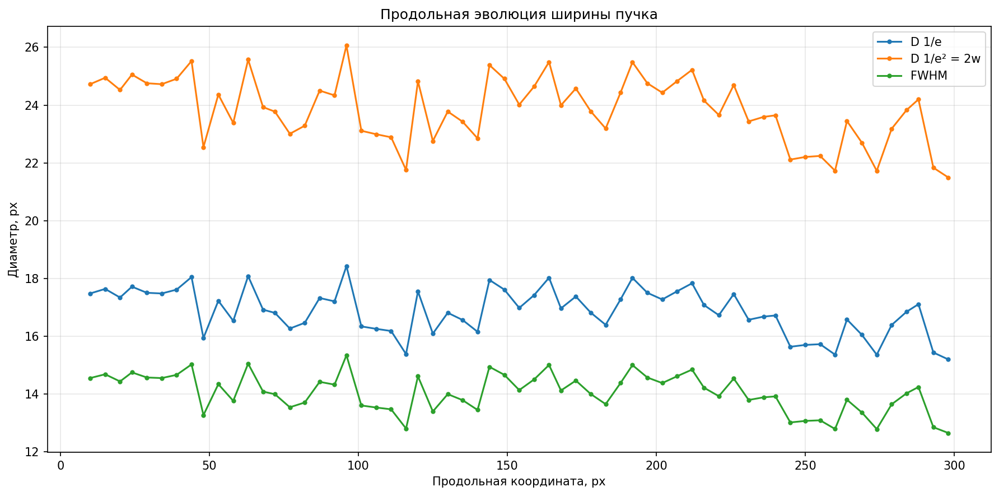

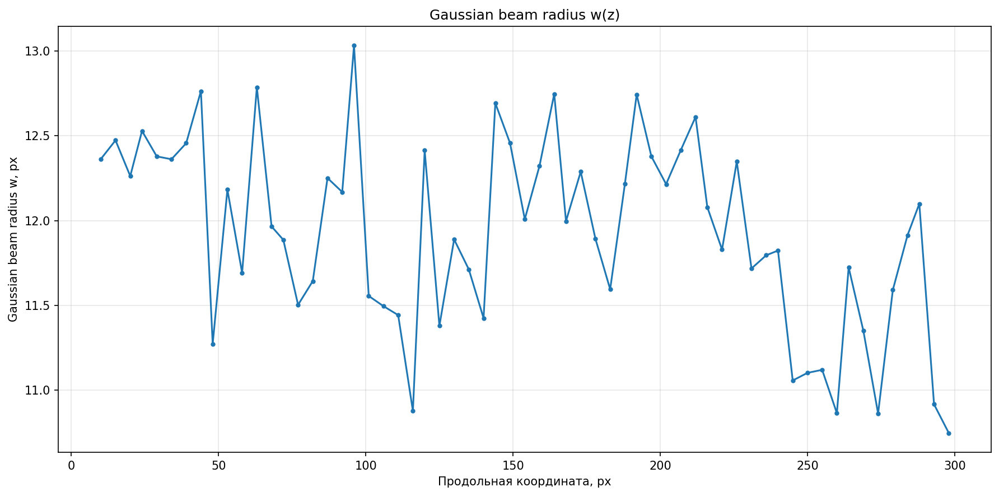

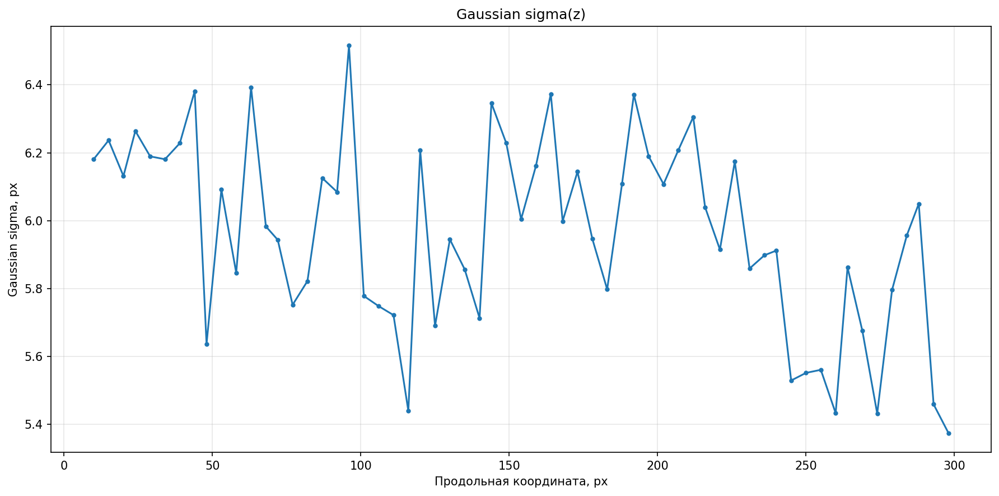

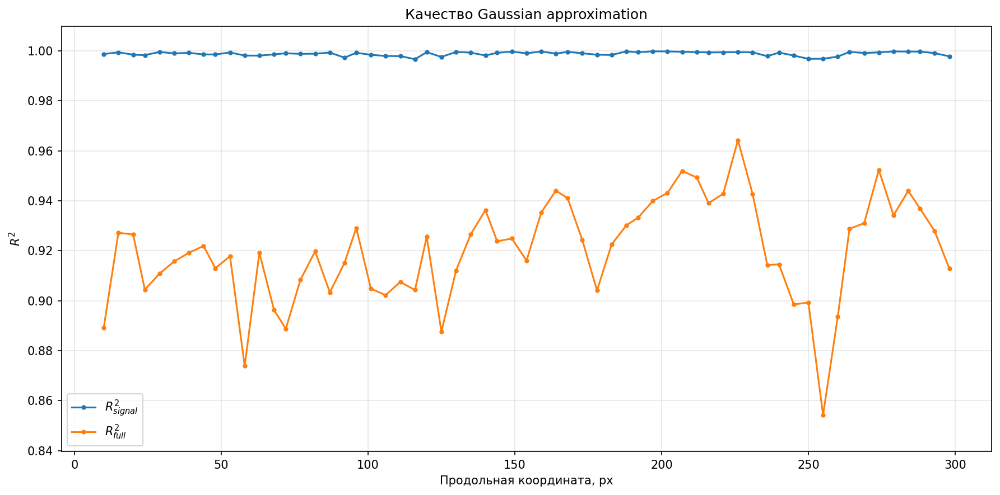

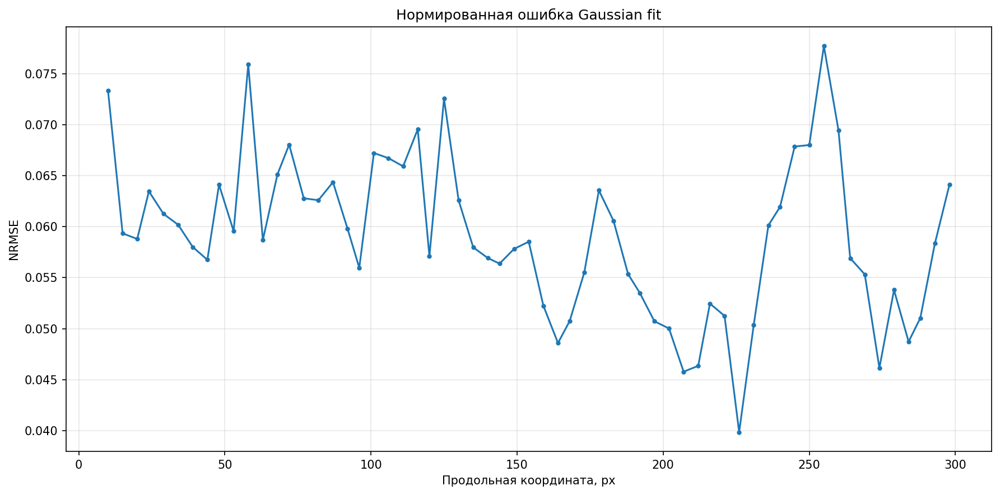

In [48]:
beam_parameters_hl = plot_beam_parameters(
    profiles_hl,
    figsize=ANALYSIS_CONFIG["plots"]["figsize"],
    dpi=ANALYSIS_CONFIG["plots"]["dpi"]
)

In [49]:
def compare_basex_hansenlaw(
    basex_results,
    hansenlaw_results
):
    """
    Сравнивает BASEX и Hansen–Law
    по успешным Gaussian fits.

    Если отдельное сечение не удалось обработать,
    оно исключается только из сравнения этого сечения.
    """

    basex_map = {
        item["z_index"]: item
        for item in basex_results
        if item.get("success", False)
    }

    hl_map = {
        item["z_index"]: item
        for item in hansenlaw_results
        if item.get("success", False)
    }

    common_z = sorted(
        set(basex_map) &
        set(hl_map)
    )

    if len(common_z) < 2:

        raise RuntimeError(
            "Недостаточно общих успешных "
            "сечений для сравнения."
        )

    d_basex = np.array([
        basex_map[z]["diameter_1e2"]
        for z in common_z
    ])

    d_hl = np.array([
        hl_map[z]["diameter_1e2"]
        for z in common_z
    ])

    diff_percent = (
        100.0
        * np.abs(d_basex - d_hl)
        / np.maximum(0.5 * (np.abs(d_basex) + np.abs(d_hl)), np.finfo(float).eps)
    )

    mean_difference = np.mean(
        diff_percent
    )

    max_difference = np.max(
        diff_percent
    )

    print(
        "=== BASEX vs Hansen–Law ==="
    )

    print(
        f"Сравнено сечений: "
        f"{len(common_z)}"
    )

    print(
        f"Среднее абсолютное различие: "
        f"{mean_difference:.3f}%"
    )

    print(
        f"Максимальное абсолютное различие: "
        f"{max_difference:.3f}%"
    )

    # ------------------------------------------------------------
    # График диаметров
    # ------------------------------------------------------------

    plt.figure(
        figsize=(9, 5)
    )

    plt.plot(
        common_z,
        d_basex,
        marker="o",
        label="BASEX"
    )

    plt.plot(
        common_z,
        d_hl,
        marker="o",
        label="Hansen–Law"
    )

    plt.xlabel(
        "Продольная координата, px"
    )

    plt.ylabel(
        "D 1/e², px"
    )

    plt.title(
        "BASEX vs Hansen–Law"
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # График различия
    # ------------------------------------------------------------

    plt.figure(
        figsize=(9, 5)
    )

    plt.plot(
        common_z,
        diff_percent,
        marker="o"
    )

    plt.xlabel(
        "Продольная координата, px"
    )

    plt.ylabel(
        "Различие, %"
    )

    plt.title(
        "Различие D 1/e²"
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()

    return {
        "z": np.asarray(
            common_z
        ),

        "diameter_basex":
            d_basex,

        "diameter_hansenlaw":
            d_hl,

        "relative_difference_percent":
            diff_percent,

        "mean_difference_percent":
            mean_difference,

        "max_difference_percent":
            max_difference
    }

=== BASEX vs Hansen–Law ===
Сравнено сечений: 61
Среднее абсолютное различие: 6.665%
Максимальное абсолютное различие: 11.385%


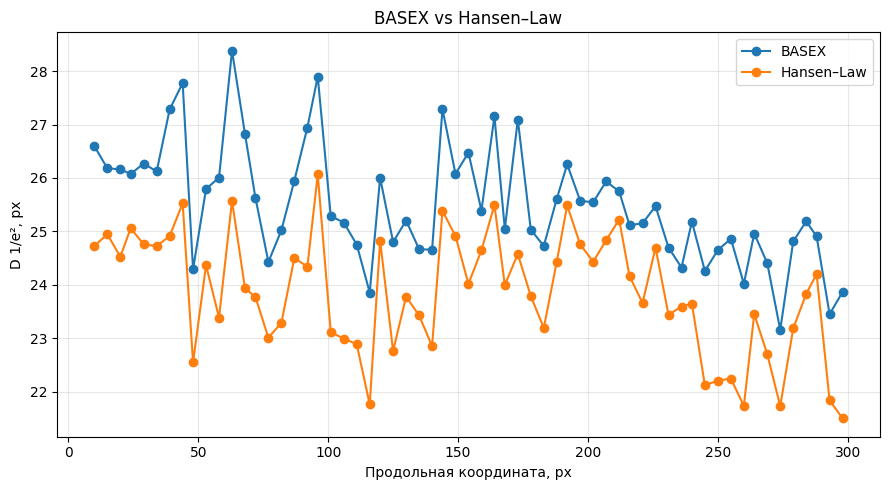

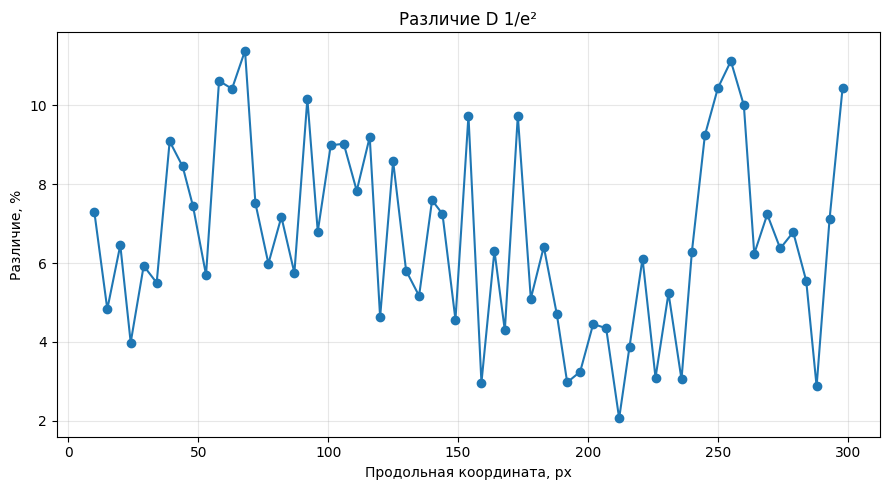

In [50]:
abel_method_comparison = compare_basex_hansenlaw(
    profiles_basex,
    profiles_hl
)

In [51]:
sigma_values = [
    0.0,
    0.5,
    1.0,
    1.5,
    2.0,
    2.5
]

In [52]:
def gaussian_sigma_sensitivity(
    centered_image,
    sigma_values,
    z_index,
    bg_corner_size=40,
    origin_x=None,
    regularization=50
):
    """
    Исследует влияние preprocessing Gaussian sigma
    на восстановленные параметры пучка.
    """

    results = []

    for sigma in sigma_values:

        print(
            f"\n=== Gaussian sigma = {sigma:.2f} ==="
        )

        processed, info = (
            preprocess_background_and_noise(
                centered_image,
                bg_corner_size=bg_corner_size,
                sigma=sigma,
                debug_plot=False
            )
        )

        if origin_x is None:

            _, current_origin_x = (
                find_abel_center(
                    processed,
                    slice_width=10,
                    debug_plot=False
                )
            )

        else:

            current_origin_x = origin_x

        reconstructed, _ = inverse_abel_basex(
            processed,
            origin_x=current_origin_x,
            regularization=regularization,
            debug_plot=False
        )

        r, profile = extract_radial_profile(
            reconstructed,
            z_index=z_index
        )

        fit = fit_gaussian_radial_profile(
            r,
            profile
        )

        results.append({

            "sigma_preprocess":
                sigma,

            "diameter_1e":
                fit["diameter_1e"],

            "diameter_1e2":
                fit["diameter_1e2"],

            "beam_radius_w":
                fit["beam_radius_w"],

            "fwhm":
                fit["fwhm"],

            "r_squared_signal":
                fit["r_squared_signal"],

            "r_squared_full":
                fit["r_squared_full"],

            "nrmse_full":
                fit["nrmse_full"],

            "rmse_full":
                fit["rmse_full"],

            "peak_intensity":
                fit["peak_intensity"],

            "sigma_fit":
                fit["sigma"]
        })

    return results

In [53]:
sigma_results = gaussian_sigma_sensitivity(
    centered_img,
    sigma_values=[
        0.0,
        0.5,
        1.0,
        1.5,
        2.0,
        2.5
    ],
    z_index=z0,
    origin_x=abel_center_x,
    regularization=50
)


=== Gaussian sigma = 0.00 ===
=== Анализ фона и шума ===
Медианный фон:                15.392
СКО шума до:                  1.825
Обычное СКО углов:            1.789
СКО шума после:               1.825
Коэффициент подавления шума:  1.00
Максимум до обработки:        125.238
Максимум после обработки:     109.846
Gaussian sigma:                0.000

=== Abel inversion: BASEX ===
Метод:               BASEX
Origin X:            134.53627 px
Regularization:      50

Calculating inverse Abel transform using basex method - 
    image size: 309x267
Calculating inverse Abel transform using basex method - 
    image size: 309x267
Using memory-cached basis sets
Updating regularization...
Calculating correction...
Using memory-cached basis sets
0.02 seconds
0.02 seconds
=== Результат BASEX ===
Размер результата:    (309, 267)
Минимум:              -0.210411
Максимум:             6.17608
Доля отрицательных пикселей:             34.408446%


=== Gaussian sigma = 0.50 ===
=== Анализ фона и шума ===

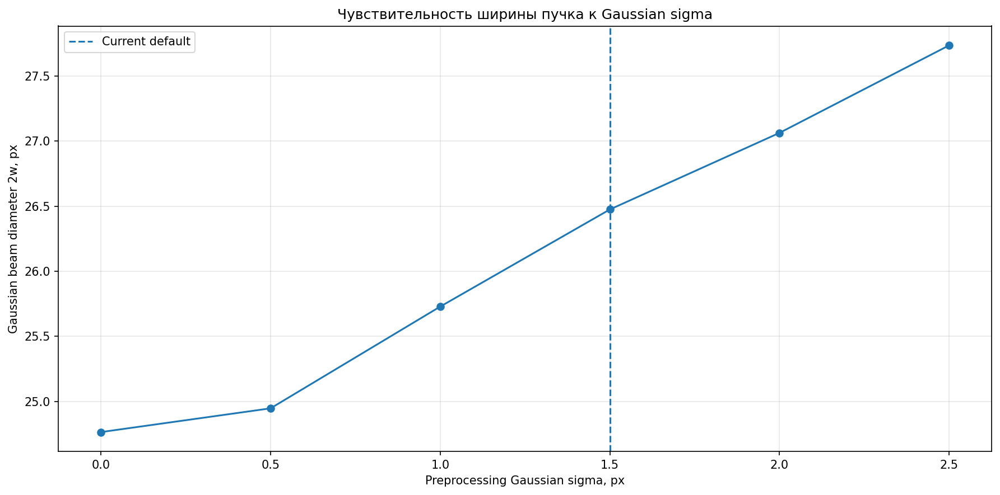

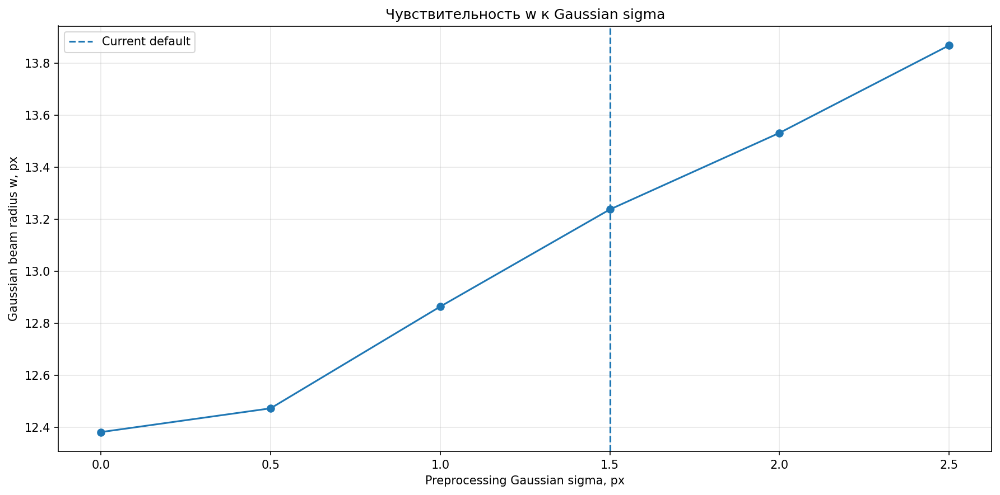

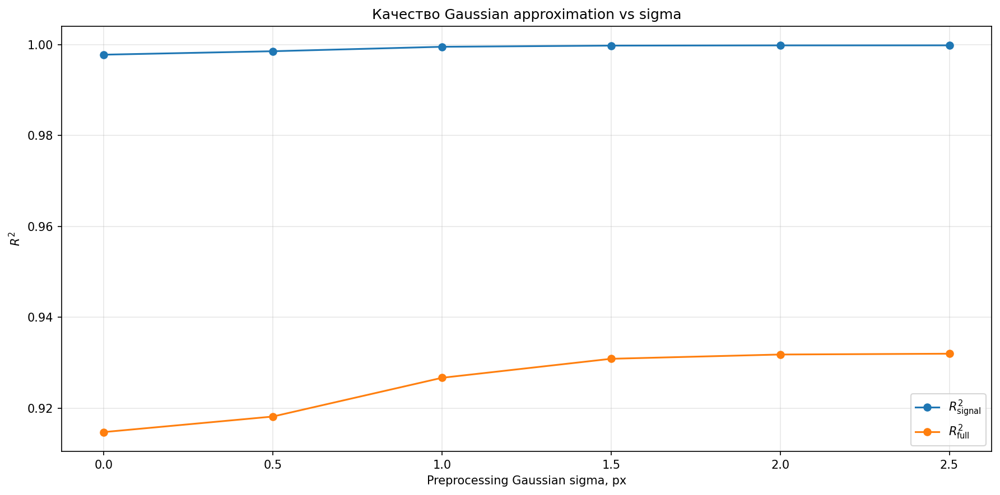

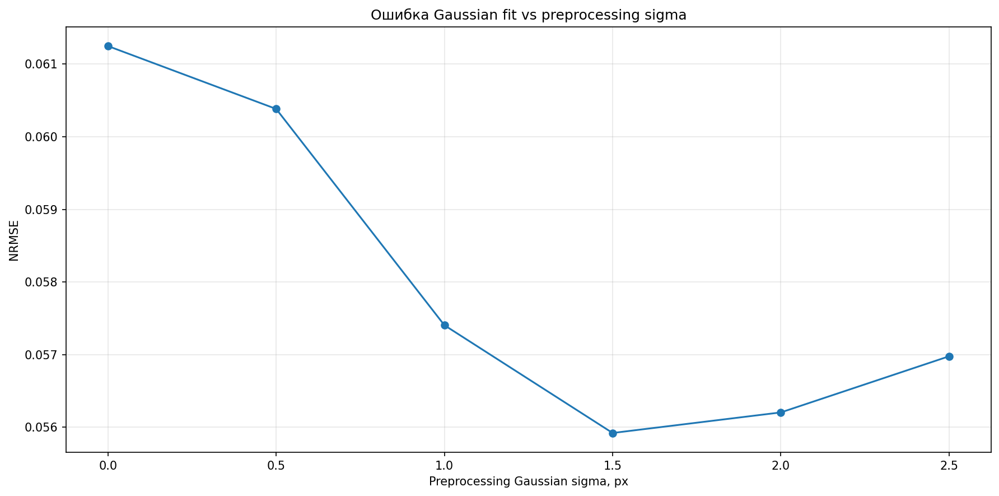

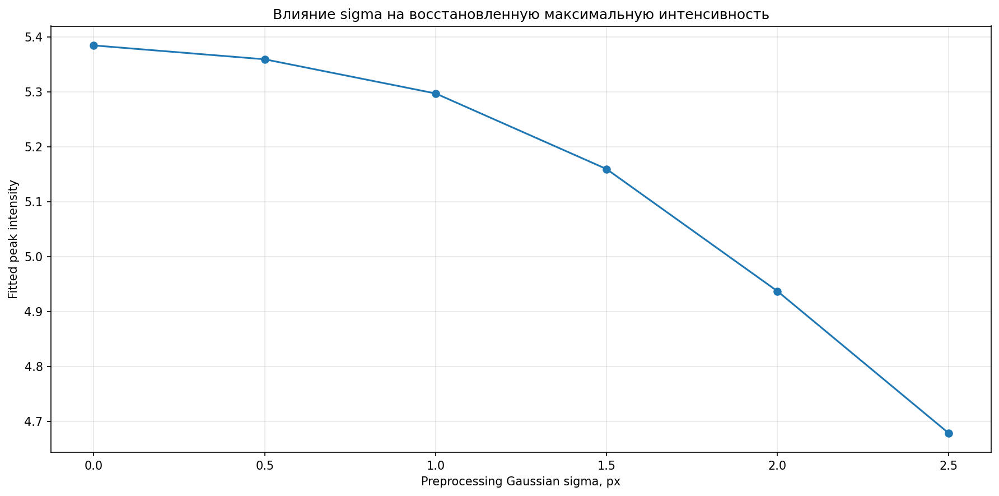

In [54]:
# ============================================================
# VISUALIZATION: Gaussian sigma sensitivity
# ============================================================

sigma_array = np.array([
    item["sigma_preprocess"]
    for item in sigma_results
], dtype=float)

sigma_d1e2 = np.array([
    item["diameter_1e2"]
    for item in sigma_results
], dtype=float)

sigma_w = np.array([
    item["beam_radius_w"]
    for item in sigma_results
], dtype=float)

sigma_r2_signal = np.array([
    item["r_squared_signal"]
    for item in sigma_results
], dtype=float)

sigma_r2_full = np.array([
    item["r_squared_full"]
    for item in sigma_results
], dtype=float)

sigma_nrmse = np.array([
    item["nrmse_full"]
    for item in sigma_results
], dtype=float)

sigma_peak = np.array([
    item["peak_intensity"]
    for item in sigma_results
], dtype=float)


# ============================================================
# 1. Gaussian beam diameter
# ============================================================

plt.figure(
    figsize=ANALYSIS_CONFIG["plots"]["figsize"],
    dpi=ANALYSIS_CONFIG["plots"]["dpi"]
)

plt.plot(
    sigma_array,
    sigma_d1e2,
    marker="o"
)

plt.axvline(
    ANALYSIS_CONFIG[
        "preprocessing"
    ]["gaussian_sigma"],
    linestyle="--",
    label="Current default"
)

plt.xlabel(
    "Preprocessing Gaussian sigma, px"
)

plt.ylabel(
    "Gaussian beam diameter 2w, px"
)

plt.title(
    "Чувствительность ширины пучка к Gaussian sigma"
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 2. Beam radius
# ============================================================

plt.figure(
    figsize=ANALYSIS_CONFIG["plots"]["figsize"],
    dpi=ANALYSIS_CONFIG["plots"]["dpi"]
)

plt.plot(
    sigma_array,
    sigma_w,
    marker="o"
)

plt.axvline(
    ANALYSIS_CONFIG[
        "preprocessing"
    ]["gaussian_sigma"],
    linestyle="--",
    label="Current default"
)

plt.xlabel(
    "Preprocessing Gaussian sigma, px"
)

plt.ylabel(
    "Gaussian beam radius w, px"
)

plt.title(
    "Чувствительность w к Gaussian sigma"
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 3. Gaussian quality
# ============================================================

plt.figure(
    figsize=ANALYSIS_CONFIG["plots"]["figsize"],
    dpi=ANALYSIS_CONFIG["plots"]["dpi"]
)

plt.plot(
    sigma_array,
    sigma_r2_signal,
    marker="o",
    label=r"$R^2_{\mathrm{signal}}$"
)

plt.plot(
    sigma_array,
    sigma_r2_full,
    marker="o",
    label=r"$R^2_{\mathrm{full}}$"
)

plt.xlabel(
    "Preprocessing Gaussian sigma, px"
)

plt.ylabel(
    r"$R^2$"
)

plt.title(
    "Качество Gaussian approximation vs sigma"
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 4. NRMSE
# ============================================================

plt.figure(
    figsize=ANALYSIS_CONFIG["plots"]["figsize"],
    dpi=ANALYSIS_CONFIG["plots"]["dpi"]
)

plt.plot(
    sigma_array,
    sigma_nrmse,
    marker="o"
)

plt.xlabel(
    "Preprocessing Gaussian sigma, px"
)

plt.ylabel(
    "NRMSE"
)

plt.title(
    "Ошибка Gaussian fit vs preprocessing sigma"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# 5. Peak intensity
# ============================================================

plt.figure(
    figsize=ANALYSIS_CONFIG["plots"]["figsize"],
    dpi=ANALYSIS_CONFIG["plots"]["dpi"]
)

plt.plot(
    sigma_array,
    sigma_peak,
    marker="o"
)

plt.xlabel(
    "Preprocessing Gaussian sigma, px"
)

plt.ylabel(
    "Fitted peak intensity"
)

plt.title(
    "Влияние sigma на восстановленную максимальную интенсивность"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [55]:
def regularization_sensitivity(
    processed_image,
    origin_x,
    z_index,
    regularization_values
):
    """
    Исследует влияние BASEX regularization
    на физические параметры одного z-сечения.
    """

    results = []

    for reg in regularization_values:

        print(
            f"\n=== BASEX regularization = {reg} ==="
        )

        reconstructed, _ = inverse_abel_basex(
            processed_image,
            origin_x=origin_x,
            regularization=reg,
            debug_plot=False
        )

        r, profile = extract_radial_profile(
            reconstructed,
            z_index=z_index
        )

        fit = fit_gaussian_radial_profile(
            r,
            profile,
            fit_fraction=ANALYSIS_CONFIG[
                "gaussian_fit"
            ]["fit_fraction"],
            robust=ANALYSIS_CONFIG[
                "gaussian_fit"
            ]["robust"]
        )

        results.append({

            "regularization":
                reg,

            "diameter_1e":
                fit["diameter_1e"],

            "diameter_1e2":
                fit["diameter_1e2"],

            "beam_radius_w":
                fit["beam_radius_w"],

            "fwhm":
                fit["fwhm"],

            "r_squared_signal":
                fit["r_squared_signal"],

            "r_squared_full":
                fit["r_squared_full"],

            "nrmse_full":
                fit["nrmse_full"],

            "rmse_full":
                fit["rmse_full"],

            "peak_intensity":
                fit["peak_intensity"],

            "baseline":
                fit["baseline"],

            "sigma":
                fit["sigma"]
        })

    return results

In [56]:
reg_results_physical = regularization_sensitivity(
    ready_for_abel,
    origin_x=abel_center_x,
    z_index=z0,
    regularization_values=[
        0,
        1,
        5,
        10,
        25,
        50,
        100,
        200
    ]
)


=== BASEX regularization = 0 ===
=== Abel inversion: BASEX ===
Метод:               BASEX
Origin X:            134.53627 px
Regularization:      0

Calculating inverse Abel transform using basex method - 
    image size: 309x267
Calculating inverse Abel transform using basex method - 
    image size: 309x267
Using memory-cached basis sets
Updating regularization...
Calculating correction...
Using memory-cached basis sets
0.01 seconds
0.01 seconds
=== Результат BASEX ===
Размер результата:    (309, 267)
Минимум:              -0.112304
Максимум:             6.05214
Доля отрицательных пикселей:             31.739452%


=== BASEX regularization = 1 ===
=== Abel inversion: BASEX ===
Метод:               BASEX
Origin X:            134.53627 px
Regularization:      1

Calculating inverse Abel transform using basex method - 
    image size: 309x267
Calculating inverse Abel transform using basex method - 
    image size: 309x267
Using memory-cached basis sets
Updating regularization...
Calcula

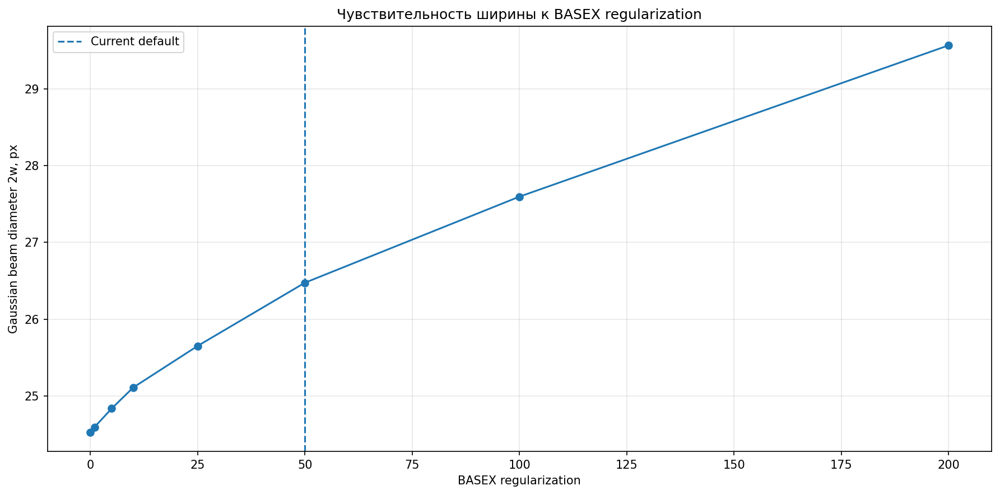

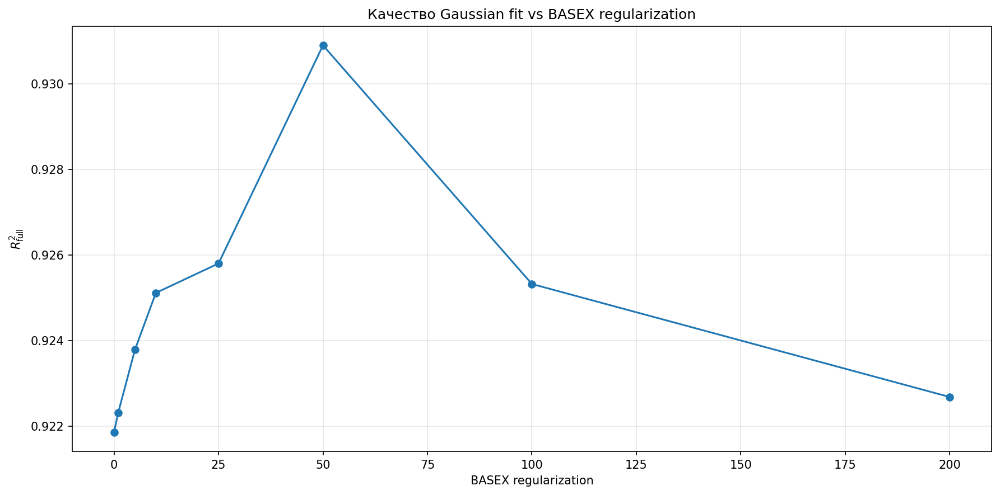

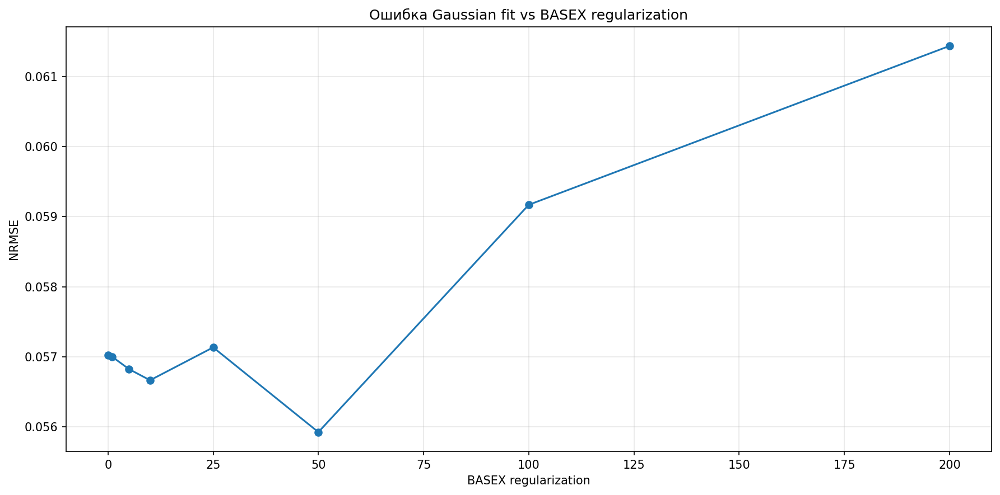

In [57]:
reg_array = np.array([
    item["regularization"]
    for item in reg_results_physical
])

reg_d1e2 = np.array([
    item["diameter_1e2"]
    for item in reg_results_physical
])

reg_r2_full = np.array([
    item["r_squared_full"]
    for item in reg_results_physical
])

reg_nrmse = np.array([
    item["nrmse_full"]
    for item in reg_results_physical
])

reg_peak = np.array([
    item["peak_intensity"]
    for item in reg_results_physical
])


# ============================================================
# Width
# ============================================================

plt.figure(
    figsize=ANALYSIS_CONFIG["plots"]["figsize"],
    dpi=ANALYSIS_CONFIG["plots"]["dpi"]
)

plt.plot(
    reg_array,
    reg_d1e2,
    marker="o"
)

plt.axvline(
    ANALYSIS_CONFIG["basex"]["regularization"],
    linestyle="--",
    label="Current default"
)

plt.xlabel(
    "BASEX regularization"
)

plt.ylabel(
    "Gaussian beam diameter 2w, px"
)

plt.title(
    "Чувствительность ширины к BASEX regularization"
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# Full R²
# ============================================================

plt.figure(
    figsize=ANALYSIS_CONFIG["plots"]["figsize"],
    dpi=ANALYSIS_CONFIG["plots"]["dpi"]
)

plt.plot(
    reg_array,
    reg_r2_full,
    marker="o"
)

plt.xlabel(
    "BASEX regularization"
)

plt.ylabel(
    r"$R^2_{\mathrm{full}}$"
)

plt.title(
    "Качество Gaussian fit vs BASEX regularization"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# NRMSE
# ============================================================

plt.figure(
    figsize=ANALYSIS_CONFIG["plots"]["figsize"],
    dpi=ANALYSIS_CONFIG["plots"]["dpi"]
)

plt.plot(
    reg_array,
    reg_nrmse,
    marker="o"
)

plt.xlabel(
    "BASEX regularization"
)

plt.ylabel(
    "NRMSE"
)

plt.title(
    "Ошибка Gaussian fit vs BASEX regularization"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [58]:
def radial_profile_to_xy_surface(
    r,
    profile,
    xy_step=1.0,
    radius_max=None
):
    """
    Преобразует осесимметричный I(r)
    в двумерное I(x,y).

    I(x,y) = I(sqrt(x²+y²))

    Returns
    -------
    X, Y, I_xy
    """

    r = np.asarray(
        r,
        dtype=np.float64
    )

    profile = np.asarray(
        profile,
        dtype=np.float64
    )

    if r.ndim != 1 or profile.ndim != 1:
        raise ValueError(
            "r и profile должны быть 1D."
        )

    if len(r) != len(profile):
        raise ValueError(
            "r и profile должны иметь одинаковую длину."
        )

    if xy_step <= 0:
        raise ValueError(
            "xy_step должен быть > 0."
        )

    if radius_max is None:
        radius_max = r[-1]

    if radius_max <= 0:
        raise ValueError(
            "radius_max должен быть > 0."
        )

    xy = np.arange(
        -radius_max,
        radius_max + xy_step,
        xy_step
    )

    X, Y = np.meshgrid(
        xy,
        xy
    )

    R = np.sqrt(
        X**2 + Y**2
    )

    intensity_xy = np.interp(
        R.ravel(),
        r,
        profile,
        left=profile[0],
        right=0.0
    ).reshape(
        R.shape
    )

    # За пределами максимально восстановленного радиуса
    # данных нет — их не надо искусственно продолжать.
    intensity_xy[R > r[-1]] = np.nan

    return X, Y, intensity_xy

In [59]:
from matplotlib import colors
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import MultipleLocator


def plot_3d_beam_cross_section(
    abel_image,
    z_index,
    center_column=None,
    xy_step=0.5,
    radius_max=40.0,
    elev=35,
    azim=-60,
    clip_negative_for_display=True,
    color_mode="linear",
    color_gamma=0.7,
    major_tick=10.0,
    minor_tick=5.0,
    calibration=None,
    display_unit=None,
    figsize=(11, 8),
    dpi=180
):
    """3D поперечный профиль с симметризацией левой/правой стороны.

    Физический принцип: Abel предполагает осесимметрию, поэтому для 3D
    используется I(r) = (I_left(r) + I_right(r))/2. Одновременно вычисляется
    side_consistency как независимая QA-метрика. xy_step относится только к
    интерполяции display-сетки и НЕ повышает физическое разрешение.
    """
    r, profile, side_consistency = extract_symmetric_radial_profile(
        abel_image, z_index=z_index, center_column=center_column, max_radius=radius_max
    )
    radius_max = float(r[-1])

    X, Y, intensity_xy = radial_profile_to_xy_surface(
        r, profile, xy_step=xy_step, radius_max=radius_max
    )

    intensity_display = np.clip(intensity_xy, 0, None) if clip_negative_for_display else intensity_xy.copy()
    finite_mask = np.isfinite(intensity_display)
    finite_values = intensity_display[finite_mask]
    if finite_values.size == 0:
        raise ValueError("В 3D-срезе нет конечных значений.")
    vmax = float(np.max(finite_values))
    if vmax <= 0:
        raise ValueError("Максимальная интенсивность <= 0.")

    cmap = plt.get_cmap("viridis")
    if color_mode == "linear":
        norm = colors.Normalize(vmin=0.0, vmax=vmax)
    elif color_mode == "power":
        if color_gamma <= 0:
            raise ValueError("color_gamma должен быть > 0.")
        norm = colors.PowerNorm(gamma=color_gamma, vmin=0.0, vmax=vmax)
    else:
        raise ValueError("color_mode должен быть 'linear' или 'power'.")

    safe_intensity = np.nan_to_num(intensity_display, nan=0.0)
    facecolors = cmap(norm(safe_intensity))

    fig = plt.figure(figsize=figsize, dpi=dpi)
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(
        X, Y, intensity_display,
        facecolors=facecolors,
        rcount=X.shape[0], ccount=X.shape[1],
        linewidth=0, antialiased=True, shade=False
    )

    scale_um = resolve_pixel_scale_um(calibration) if calibration else None
    unit = display_unit or (calibration or {}).get("display_unit", "px")
    if scale_um is not None:
        xy_display = X * scale_um / LENGTH_UNITS_UM[unit]
        y_display = Y * scale_um / LENGTH_UNITS_UM[unit]
        ax.set_xlabel(f"x, {unit}")
        ax.set_ylabel(f"y, {unit}")
        lim_display = radius_max * scale_um / LENGTH_UNITS_UM[unit]
        ax.set_xlim(-lim_display, lim_display)
        ax.set_ylim(-lim_display, lim_display)
        ax.xaxis.set_major_locator(MultipleLocator(major_tick * scale_um / LENGTH_UNITS_UM[unit]))
        ax.yaxis.set_major_locator(MultipleLocator(major_tick * scale_um / LENGTH_UNITS_UM[unit]))
        ax.xaxis.set_minor_locator(MultipleLocator(minor_tick * scale_um / LENGTH_UNITS_UM[unit]))
        ax.yaxis.set_minor_locator(MultipleLocator(minor_tick * scale_um / LENGTH_UNITS_UM[unit]))
        z_label = str(z_index)
    else:
        ax.set_xlabel("x, px")
        ax.set_ylabel("y, px")
        ax.set_xlim(-radius_max, radius_max)
        ax.set_ylim(-radius_max, radius_max)
        ax.xaxis.set_major_locator(MultipleLocator(major_tick))
        ax.yaxis.set_major_locator(MultipleLocator(major_tick))
        ax.xaxis.set_minor_locator(MultipleLocator(minor_tick))
        ax.yaxis.set_minor_locator(MultipleLocator(minor_tick))
        z_label = f"{z_index} px"

    ax.set_zlabel("Intensity / relative signal")
    ax.grid(True)
    ax.set_title(
        f"3D поперечный профиль, z = {z_label}\n"
        f"Post-symmetrization check: RMS={side_consistency['normalized_rms_difference']:.3%}, "
        f"corr={side_consistency['correlation']:.5f}"
    )
    ax.view_init(elev=elev, azim=azim)
    ax.set_box_aspect((1, 1, 0.65))

    scalar_mappable = ScalarMappable(norm=norm, cmap=cmap)
    scalar_mappable.set_array(finite_values)
    fig.colorbar(scalar_mappable, ax=ax, shrink=0.65, pad=0.10, label="Intensity")
    plt.tight_layout()
    plt.show()
    return X, Y, intensity_xy, side_consistency


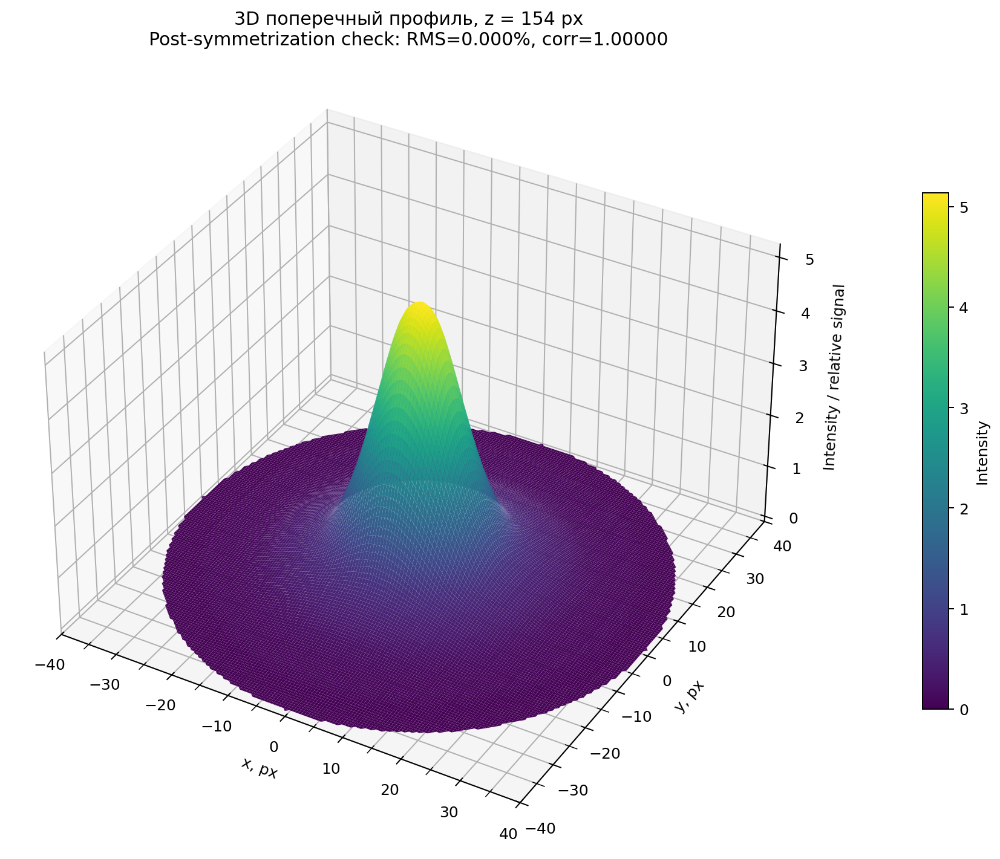

3D left/right consistency: {'left_profile': array([ 5.13902732e+00,  5.09908034e+00,  4.98011915e+00,  4.75517434e+00,
        4.41859253e+00,  4.00272263e+00,  3.55564655e+00,  3.10880918e+00,
        2.67584893e+00,  2.26954571e+00,  1.90410182e+00,  1.58417541e+00,
        1.30368550e+00,  1.05980406e+00,  8.60541401e-01,  7.14773479e-01,
        6.18556852e-01,  5.52138000e-01,  4.94543529e-01,  4.40891381e-01,
        3.96172153e-01,  3.57401367e-01,  3.14609557e-01,  2.64589615e-01,
        2.14220303e-01,  1.72390395e-01,  1.42233603e-01,  1.20048811e-01,
        1.00949460e-01,  8.44925555e-02,  7.37787691e-02,  6.97887009e-02,
        6.67837901e-02,  5.63900194e-02,  3.81992422e-02,  1.97441560e-02,
        6.16983641e-03, -2.13736344e-03, -5.76472106e-03, -5.98206670e-03,
       -4.32460178e-03]), 'right_profile': array([ 5.13902732e+00,  5.09908034e+00,  4.98011915e+00,  4.75517434e+00,
        4.41859253e+00,  4.00272263e+00,  3.55564655e+00,  3.10880918e+00,
        2.675

In [60]:
X, Y, I_xy, side_consistency_3d = plot_3d_beam_cross_section(
    abel_image_basex,
    z_index=z0,
    xy_step=0.5,
    radius_max=40.0,
    color_mode="linear",
    calibration=ANALYSIS_CONFIG["calibration"],
    display_unit=ANALYSIS_CONFIG["calibration"].get("display_unit", "px")
)
print("3D left/right consistency:", side_consistency_3d)


In [61]:
# ============================================================
# OPTIONAL INTERACTIVE 3D DEPENDENCY
# ============================================================
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    IPYWIDGETS_AVAILABLE = True
except ImportError:
    widgets = None
    from IPython.display import display, clear_output
    IPYWIDGETS_AVAILABLE = False
    print("ipywidgets не установлен. Основной научный анализ продолжает работать; интерактивный 3D-слайдер отключён.")


In [62]:
def interactive_3d_cross_section(
    abel_image,
    center_column=None,
    profile_results=None,
    xy_step=0.5,
    radius_max=40.0,
    color_mode="linear",
    color_gamma=0.7,
    calibration=None,
    display_unit=None
):
    """Интерактивный просмотр 3D. Требует optional ipywidgets."""
    if not globals().get("IPYWIDGETS_AVAILABLE", False):
        raise RuntimeError(
            "Интерактивный 3D-слайдер требует ipywidgets. "
            "Основной научный расчёт и статический 3D-график доступны без него."
        )

    abel_image = np.asarray(abel_image, dtype=np.float64)
    if abel_image.ndim != 2:
        raise ValueError("abel_image должен быть 2D.")

    h = abel_image.shape[0]
    slider = widgets.IntSlider(
        value=h // 2, min=0, max=h - 1, step=1, description="z:",
        continuous_update=False, style={"description_width": "initial"}
    )
    info_label = widgets.HTML()
    output = widgets.Output()
    result_map = {int(item["z_index"]): item for item in profile_results} if profile_results is not None else {}

    def update(change=None):
        z_index = int(slider.value)
        try:
            r, profile, side_consistency = extract_symmetric_radial_profile(
                abel_image, z_index=z_index, center_column=center_column, max_radius=radius_max
            )
            positive_profile = np.clip(profile, 0, None)
            text = f"<b>z = {z_index} px</b> | I<sub>max</sub> = {float(np.max(positive_profile)):.5g}"
            if z_index in result_map and result_map[z_index].get("success", False):
                item = result_map[z_index]
                text += f" | w = {item['beam_radius_w']:.3f} px | 2w = {item['beam_diameter_2w']:.3f} px | R²<sub>full</sub> = {item['r_squared_full']:.5f}"
            elif z_index in result_map:
                text += " | Gaussian fit: неуспешен"
            text += f" | left/right RMS = {side_consistency['normalized_rms_difference']:.2%} | corr = {side_consistency['correlation']:.5f}"
            info_label.value = text
            with output:
                clear_output(wait=True)
                plot_3d_beam_cross_section(
                    abel_image, z_index=z_index, center_column=center_column,
                    xy_step=xy_step, radius_max=radius_max, color_mode=color_mode,
                    color_gamma=color_gamma, major_tick=10.0, minor_tick=5.0,
                    calibration=calibration, display_unit=display_unit
                )
        except Exception as exc:
            info_label.value = f"<b>Ошибка:</b> {exc}"
            with output:
                clear_output(wait=True)
                print(repr(exc))

    slider.observe(update, names="value")
    display(slider, info_label, output)
    update()


In [63]:
interactive_3d_cross_section(
    abel_image_basex,
    profile_results=profiles_basex,
    xy_step=0.5,
    radius_max=40.0,
    color_mode="linear",
    calibration=ANALYSIS_CONFIG["calibration"],
    display_unit=ANALYSIS_CONFIG["calibration"].get("display_unit", "px")
)

IntSlider(value=154, continuous_update=False, description='z:', max=308, style=SliderStyle(description_width='…

HTML(value='')

Output()

In [64]:
def center_sensitivity(processed_image, origin_x, z_index, offsets=None, regularization=50):
    """Анализ чувствительности к ошибке центра. Это диагностика неопределённости, а не автоматический выбор центра."""
    if offsets is None:
        offsets = np.array([-2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0])
    offsets = np.asarray(offsets, dtype=float)
    reconstructions=[]

    for offset in offsets:
        test_center = float(origin_x) + float(offset)
        try:
            reconstructed, _ = inverse_abel_basex(
                processed_image, origin_x=test_center,
                regularization=regularization, debug_plot=False
            )
            reconstructions.append({"offset":float(offset), "center":test_center, "reconstructed":reconstructed})
        except Exception as exc:
            reconstructions.append({"offset":float(offset), "center":test_center, "success":False, "error":str(exc)})

    successful=[x for x in reconstructions if x.get("reconstructed") is not None]
    if not successful:
        return [{k:v for k,v in x.items() if k!="reconstructed"} for x in reconstructions]

    common_radius=min((x["reconstructed"].shape[1]-1)//2 for x in successful)
    print(f"Общий радиальный диапазон sensitivity: 0 ... {common_radius} px")
    results=[]

    for item in reconstructions:
        if item.get("reconstructed") is None:
            results.append(item); continue
        try:
            r, profile = extract_radial_profile(item["reconstructed"], z_index=z_index, max_radius=common_radius)
            fit = fit_gaussian_radial_profile(r, profile)
            results.append({
                "offset":item["offset"], "center":item["center"], "success":True,
                "common_radius":common_radius,
                "beam_radius_w":fit["beam_radius_w"], "diameter_1e2":fit["diameter_1e2"],
                "r_squared_full":fit["r_squared_full"], "nrmse_full":fit["nrmse_full"],
                "peak_intensity":fit["peak_intensity"], "sigma":fit["sigma"]
            })
        except Exception as exc:
            results.append({"offset":item["offset"], "center":item["center"], "success":False, "error":str(exc)})
    return results


In [65]:
center_results = center_sensitivity(
    ready_for_abel,
    origin_x=abel_center_x,
    z_index=z0,
    regularization=ANALYSIS_CONFIG[
        "basex"
    ]["regularization"]
)

=== Abel inversion: BASEX ===
Метод:               BASEX
Origin X:            132.53627 px
Regularization:      50

Calculating inverse Abel transform using basex method - 
    image size: 309x265
Calculating inverse Abel transform using basex method - 
    image size: 309x265
Loading basis sets...
(cropped from basex_basis_134_1.0.npy)
Updating regularization...
Calculating correction...
Using memory-cached basis sets
0.03 seconds
0.03 seconds
=== Результат BASEX ===
Размер результата:    (309, 265)
Минимум:              -0.102559
Максимум:             4.78554
Доля отрицательных пикселей:             29.658668%

=== Abel inversion: BASEX ===
Метод:               BASEX
Origin X:            133.03627 px
Regularization:      50

Calculating inverse Abel transform using basex method - 
    image size: 309x267
Calculating inverse Abel transform using basex method - 
    image size: 309x267
Loading basis sets...
Updating regularization...
Calculating correction...
Using memory-cached basis 

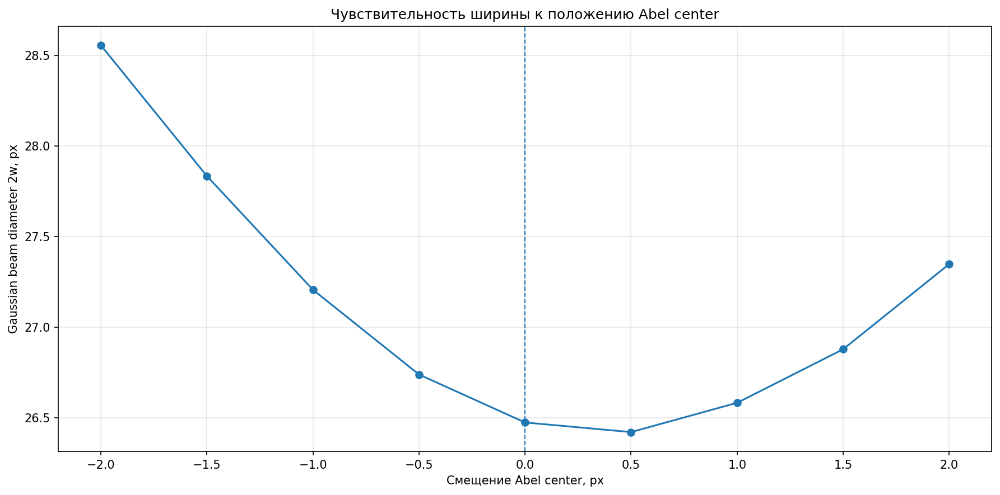

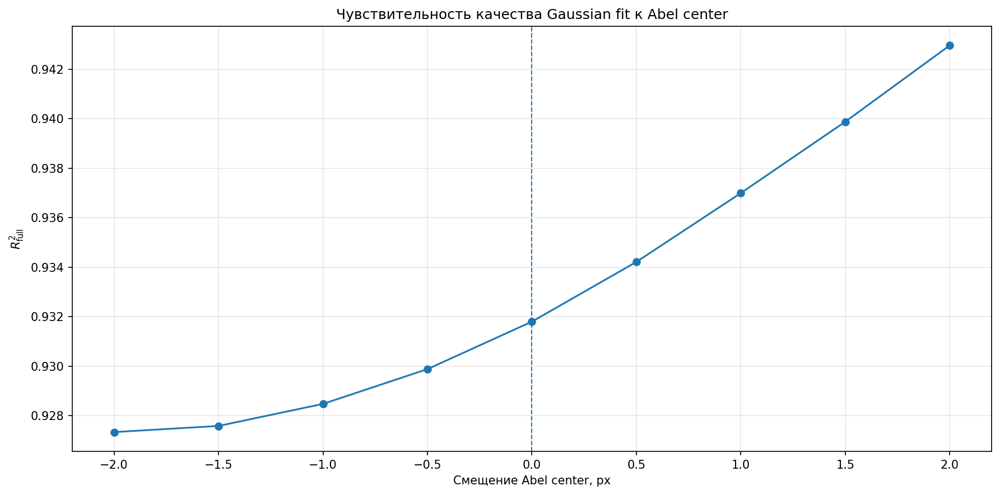

In [66]:
center_offsets = np.array([
    item["offset"]
    for item in center_results
    if item.get("success", False)
])

center_widths = np.array([
    item["diameter_1e2"]
    for item in center_results
    if item.get("success", False)
])

center_r2 = np.array([
    item["r_squared_full"]
    for item in center_results
    if item.get("success", False)
])


plt.figure(
    figsize=ANALYSIS_CONFIG["plots"]["figsize"],
    dpi=ANALYSIS_CONFIG["plots"]["dpi"]
)

plt.plot(
    center_offsets,
    center_widths,
    marker="o"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Смещение Abel center, px"
)

plt.ylabel(
    "Gaussian beam diameter 2w, px"
)

plt.title(
    "Чувствительность ширины к положению Abel center"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()


plt.figure(
    figsize=ANALYSIS_CONFIG["plots"]["figsize"],
    dpi=ANALYSIS_CONFIG["plots"]["dpi"]
)

plt.plot(
    center_offsets,
    center_r2,
    marker="o"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Смещение Abel center, px"
)

plt.ylabel(
    r"$R^2_{\mathrm{full}}$"
)

plt.title(
    "Чувствительность качества Gaussian fit к Abel center"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [67]:
def find_beam_waist(profile_results, calibration=None):
    """Определяет наблюдаемый минимум w(z), отдельно от model-fit propagation z0."""
    valid = sorted([x for x in profile_results if x.get("success", False) and np.isfinite(x.get("beam_radius_w", np.nan))], key=lambda x:x["z_index"])
    if len(valid) < 3:
        raise RuntimeError("Недостаточно успешных сечений для поиска waist.")
    z=np.array([x["z_index"] for x in valid],float); w=np.array([x["beam_radius_w"] for x in valid],float)
    i=int(np.argmin(w)); z0=float(z[i]); w0=float(w[i]); boundary=i in (0,len(w)-1)
    zsub=np.nan; wsub=np.nan; sub=False
    if not boundary:
        zl=z[i-1:i+2]; wl=w[i-1:i+2]
        try:
            a,b,c=np.polyfit(zl,wl,2)
            if np.isfinite(a) and a>0:
                zv=-b/(2*a)
                if zl[0] <= zv <= zl[-1]:
                    zsub=float(zv); wsub=float(a*zv*zv+b*zv+c); sub=np.isfinite(wsub)
        except Exception:
            pass
    scale_um=resolve_pixel_scale_um(calibration) if calibration else None; unit=(calibration or {}).get("display_unit","px")
    if scale_um is None: zd,wd,zsd,wsd=z0,w0,zsub,wsub; suf='px'
    else: zd,wd=um_to_unit(z0*scale_um,unit),um_to_unit(w0*scale_um,unit); zsd=um_to_unit(zsub*scale_um,unit) if np.isfinite(zsub) else np.nan; wsd=um_to_unit(wsub*scale_um,unit) if np.isfinite(wsub) else np.nan; suf=unit
    print("=== Observed beam-width minimum ==="); print(f"z_min_observed = {zd:.6g} {suf}"); print(f"w_min_observed = {wd:.6g} {suf}")
    if sub: print(f"z_min_observed_subpixel ≈ {zsd:.6g} {suf}"); print(f"w_min_observed_subpixel ≈ {wsd:.6g} {suf}")
    print("Это наблюдаемый минимум w(z); model-fitted propagation z0 — отдельный параметр.")
    if boundary: print("WARNING: минимум находится на границе диапазона — истинный waist может быть вне наблюдения.")
    return {"z0":z0,"w0":w0,"z_min_observed":z0,"w_min_observed":w0,"z_min_observed_subpixel":zsub,"w_min_observed_subpixel":wsub,"boundary_limited":boundary,"subpixel_available":sub,"definition":"discrete observed minimum of w(z); optional local quadratic refinement","z":z,"w":w}


In [68]:
waist_basex = find_beam_waist(
    profiles_basex
)

=== Observed beam-width minimum ===
z_min_observed = 274 px
w_min_observed = 11.5777 px
z_min_observed_subpixel ≈ 273.651 px
w_min_observed_subpixel ≈ 11.5742 px
Это наблюдаемый минимум w(z); model-fitted propagation z0 — отдельный параметр.


## Важное различие: `z_min_observed` и `z0` в propagation fit

В проекте встречаются две разные величины, которые раньше легко перепутать.

**1. `z_min_observed`** — положение минимальной ширины `w(z)` непосредственно среди измеренных z-сечений. Это наблюдаемый минимум.

**2. `z0` в Gaussian-beam propagation fit** — параметр модели
\[
w(z)=w_0\sqrt{1+((z-z_0)/z_R)^2}.
\]
Он может оказаться за пределами изображения. Например, если измерения охватывают `10...298 px`, а fit выдаёт `z0=586 px`, это означает: модель считает, что её waist находится дальше области наблюдения. Это **экстраполяция**, а не ошибочно нарисованная физическая точка. При таком результате `z0` нельзя интерпретировать как напрямую измеренный waist; одновременно проверяются `R²`, `ΔBIC`, `zR/span`, корреляция параметров и `z0_inside_data`.

Поэтому в графике теперь не рисуется ложная вертикальная линия далеко за пределами данных. Вместо неё отмечается граница диапазона и явно пишется, что waist экстраполирован.


In [69]:
from scipy.optimize import curve_fit


def gaussian_beam_width_model(z, w0, z0, zR):
    return w0 * np.sqrt(1.0 + ((z - z0) / zR) ** 2)


def fit_gaussian_beam_propagation(profile_results, pixel_size=None, robust=True, display_unit=None):
    """Gaussian-beam propagation fit with explicit identifiability diagnostics.

    Здесь z0 — *модельно оцененное положение waist*. Оно может лежать вне
    экспериментального диапазона: это не ошибка самой математики, а экстраполяция
    модели. Если z0 вне диапазона и/или zR >> длины измерений, положение waist
    считается плохо идентифицируемым и не должно интерпретироваться как прямое
    измерение.
    """
    valid = [x for x in profile_results if x.get("success", False) and np.isfinite(x.get("beam_radius_w", np.nan))]
    if len(valid) < 10:
        raise RuntimeError("Недостаточно точек для Gaussian-beam fit.")

    z = np.array([x["z_index"] for x in valid], dtype=float)
    w = np.array([x["beam_radius_w"] for x in valid], dtype=float)
    if pixel_size is not None:
        if pixel_size <= 0:
            raise ValueError("pixel_size должен быть > 0.")
        z_fit = z * pixel_size
        w_fit = w * pixel_size
    else:
        z_fit, w_fit = z, w

    z_min, z_max = float(z_fit.min()), float(z_fit.max())
    z_span = z_max - z_min
    if z_span <= 0:
        raise RuntimeError("Нет продольного диапазона для propagation fit.")

    k = int(np.argmin(w_fit))
    p0 = [max(float(w_fit[k]), np.finfo(float).eps), float(z_fit[k]), max(z_span, 1.0)]
    lower = [np.finfo(float).eps, z_min - 20.0 * z_span, np.finfo(float).eps]
    upper = [np.inf, z_max + 20.0 * z_span, 1e6 * max(z_span, 1.0)]

    if robust:
        def residual_func(p):
            return gaussian_beam_width_model(z_fit, *p) - w_fit
        lsq = least_squares(
            residual_func, p0, bounds=(lower, upper), loss="soft_l1",
            f_scale=max(np.std(w_fit), 1e-6), max_nfev=100000
        )
        popt = lsq.x
        fitted_w = gaussian_beam_width_model(z_fit, *popt)
        try:
            J = lsq.jac
            dof = max(len(w_fit) - 3, 1)
            s2 = max(2.0 * float(lsq.cost) / dof, np.finfo(float).eps)
            pcov = s2 * np.linalg.pinv(J.T @ J)
        except Exception:
            pcov = np.full((3, 3), np.nan)
    else:
        popt, pcov = curve_fit(
            gaussian_beam_width_model, z_fit, w_fit, p0=p0,
            bounds=(lower, upper), maxfev=100000
        )
        fitted_w = gaussian_beam_width_model(z_fit, *popt)

    w0, z0, zR = map(float, popt)
    residual = w_fit - fitted_w
    sse_g = float(np.sum(residual**2))
    sst = float(np.sum((w_fit - w_fit.mean())**2))
    r2 = 1.0 - sse_g / sst if sst > 0 else np.nan
    rmse = float(np.sqrt(np.mean(residual**2)))

    w_const = np.full_like(w_fit, w_fit.mean())
    sse_c = float(np.sum((w_fit - w_const)**2))
    n = len(w_fit)
    bic_g = n * np.log(max(sse_g / n, np.finfo(float).eps)) + 3 * np.log(n)
    bic_c = n * np.log(max(sse_c / n, np.finfo(float).eps)) + np.log(n)
    delta_bic = float(bic_c - bic_g)
    relative_variation = float((w_fit.max() - w_fit.min()) / w_fit.mean())
    warnings_list_pre = []
    if relative_variation < 1e-3:
        warnings_list_pre.append("Ширина практически постоянна (<0.1%); параметры z0 и zR практически неидентифицируемы.")

    if np.all(np.isfinite(pcov)):
        parameter_std = np.sqrt(np.maximum(np.diag(pcov), 0.0))
        with np.errstate(divide="ignore", invalid="ignore"):
            correlation_matrix = pcov / np.outer(parameter_std, parameter_std)
    else:
        parameter_std = np.full(3, np.nan)
        correlation_matrix = np.full((3, 3), np.nan)

    zR_relative_error = parameter_std[2] / zR if np.isfinite(parameter_std[2]) and zR > 0 else np.nan
    zR_to_span = zR / z_span if z_span > 0 else np.inf
    z0_inside = bool(z_min <= z0 <= z_max)

    warnings_list = list(warnings_list_pre)
    if not np.isfinite(r2) or r2 < 0.8:
        warnings_list.append("Gaussian propagation model объясняет менее 80% вариации w(z).")
    if not z0_inside:
        warnings_list.append("Оцененный waist z0 находится за пределами исследованного диапазона: это экстраполяция, а не прямое наблюдение.")
    if delta_bic < 6:
        warnings_list.append("Gaussian propagation model не даёт убедимого преимущества над constant-width.")
    if zR_to_span > 20:
        warnings_list.append("Rayleigh range значительно больше исследованного диапазона; zR плохо идентифицируется.")
    if np.isfinite(zR_relative_error) and zR_relative_error > 0.5:
        warnings_list.append("zR определяется с высокой относительной неопределённостью.")
    if relative_variation < 0.02:
        warnings_list.append("Ширина пучка меняется менее чем на 2% по исследованному диапазону.")

    print("=== Gaussian beam propagation fit ===")
    print(f"w0 = {w0:.6g}; z0 = {z0:.6g}; zR = {zR:.6g}")
    print(f"R² = {r2:.6f}; RMSE = {rmse:.6g}; ΔBIC = {delta_bic:.6g}")
    print(f"Relative width variation = {relative_variation:.3%}")
    print(f"Waist inside data range: {z0_inside}")
    if np.all(np.isfinite(parameter_std)):
        print(f"std(w0) = {parameter_std[0]:.6g}; std(z0) = {parameter_std[1]:.6g}; std(zR) = {parameter_std[2]:.6g}")
    if warnings_list:
        print("\n=== WARNING ===")
        for msg in warnings_list:
            print("•", msg)

    plt.figure(figsize=(14, 7), dpi=180)
    plt.plot(z_fit, w_fit, linewidth=1.2, label="Reconstructed w(z)")
    zd = np.linspace(z_min, z_max, 1000)
    plt.plot(zd, gaussian_beam_width_model(zd, *popt), linewidth=2.5, label="Gaussian beam model")
    if z0_inside:
        plt.axvline(z0, linestyle="--", label="Fitted waist position z0")
    else:
        edge = z_min if z0 < z_min else z_max
        plt.axvline(edge, linestyle=":", linewidth=1.5, label="Data boundary")
        direction = "<" if z0 < z_min else ">"
        plt.annotate(
            f"Fitted z0 {direction} data range\n(z0={z0:.3g}, extrapolated)",
            xy=(edge, np.interp(edge, zd, gaussian_beam_width_model(zd, *popt))),
            xytext=(0.03, 0.90), textcoords="axes fraction",
            arrowprops={"arrowstyle": "->"}
        )
    plt.xlabel(f"z [{display_unit}]" if display_unit else "z [px]")
    plt.ylabel(f"Beam radius w [{display_unit}]" if display_unit else "Beam radius w [px]")
    plt.title("Gaussian beam propagation")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "success": True, "w0": w0, "z0": z0, "zR": zR,
        "parameter_std": parameter_std, "covariance": pcov,
        "correlation_matrix": correlation_matrix, "r_squared": r2,
        "rmse": rmse, "sse_gaussian": sse_g, "sse_constant": sse_c,
        "bic_gaussian": bic_g, "bic_constant": bic_c, "delta_bic": delta_bic,
        "relative_variation": relative_variation, "zR_relative_error": zR_relative_error,
        "zR_to_span": zR_to_span, "z0_inside_data": z0_inside,
        "warnings": warnings_list, "z": z_fit, "w": w_fit,
        "fitted_w": fitted_w, "residual": residual,
        "definition": "model-fitted Gaussian propagation waist",
    }


In [70]:
# ============================================================
# FULL-RESOLUTION DIAGNOSTIC ANALYSIS
# ============================================================

z_positions_full = get_z_positions(
    n_z=abel_image_basex.shape[0],
    mode="full",
    n_points=ANALYSIS_CONFIG[
        "z_sampling"
    ]["n_points"],
    margin=ANALYSIS_CONFIG[
        "z_sampling"
    ]["margin"]
)

print("=== FULL-RESOLUTION ANALYSIS ===")
print(
    f"Количество z-сечений: "
    f"{len(z_positions_full)}"
)

print(
    f"Диапазон: "
    f"{z_positions_full[0]} ... "
    f"{z_positions_full[-1]} px"
)

# ------------------------------------------------------------
# BASEX
# ------------------------------------------------------------

profiles_basex_full = (
    analyze_all_z_profiles(
        abel_image_basex,
        z_positions_full,
        fit_fraction=ANALYSIS_CONFIG[
            "gaussian_fit"
        ]["fit_fraction"],
        robust=ANALYSIS_CONFIG[
            "gaussian_fit"
        ]["robust"],
        r0_max=ANALYSIS_CONFIG[
            "gaussian_fit"
        ]["r0_max"]
    )
)

# ------------------------------------------------------------
# Hansen–Law
# ------------------------------------------------------------

profiles_hl_full = (
    analyze_all_z_profiles(
        abel_image_hl,
        z_positions_full,
        fit_fraction=ANALYSIS_CONFIG[
            "gaussian_fit"
        ]["fit_fraction"],
        robust=ANALYSIS_CONFIG[
            "gaussian_fit"
        ]["robust"],
        r0_max=ANALYSIS_CONFIG[
            "gaussian_fit"
        ]["r0_max"]
    )
)

print()
print("Full BASEX analysis completed.")
print("Full Hansen–Law analysis completed.")

# ВАЖНО:
# ANALYSIS_CONFIG остаётся в default режиме "dense".

=== FULL-RESOLUTION ANALYSIS ===
Количество z-сечений: 289
Диапазон: 10 ... 298 px

=== BATCH GAUSSIAN ANALYSIS ===
Всего сечений:       289
Успешных fits:       289
Неудачных fits:      0

=== BATCH GAUSSIAN ANALYSIS ===
Всего сечений:       289
Успешных fits:       289
Неудачных fits:      0

Full BASEX analysis completed.
Full Hansen–Law analysis completed.


=== Gaussian beam propagation fit ===
w0 = 0.398573; z0 = 3953.58; zR = 118.928
R² = 0.317226; RMSE = 0.423231; ΔBIC = 98.9469
Relative width variation = 21.967%
Waist inside data range: False
std(w0) = 0.036293; std(z0) = 345.625; std(zR) = 21.6576

=== WARNING ===
• Gaussian propagation model объясняет менее 80% вариации w(z).
• Оцененный waist z0 находится за пределами исследованного диапазона: это экстраполяция, а не прямое наблюдение.


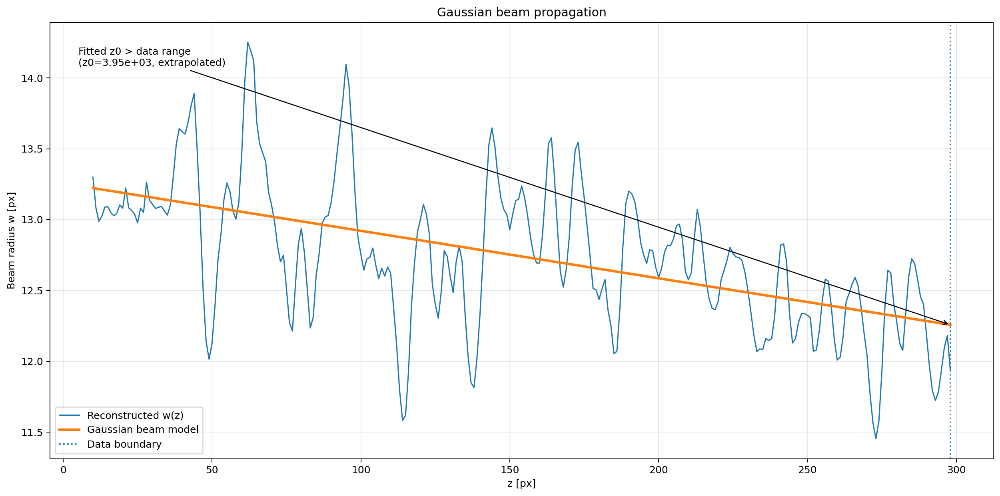

=== Gaussian beam propagation fit ===
w0 = 0.288453; z0 = 4246.11; zR = 98.7651
R² = 0.175834; RMSE = 0.507116; ΔBIC = 44.5549
Relative width variation = 22.697%
Waist inside data range: False
std(w0) = 0.0387836; std(z0) = 549.341; std(zR) = 26.5128

=== WARNING ===
• Gaussian propagation model объясняет менее 80% вариации w(z).
• Оцененный waist z0 находится за пределами исследованного диапазона: это экстраполяция, а не прямое наблюдение.


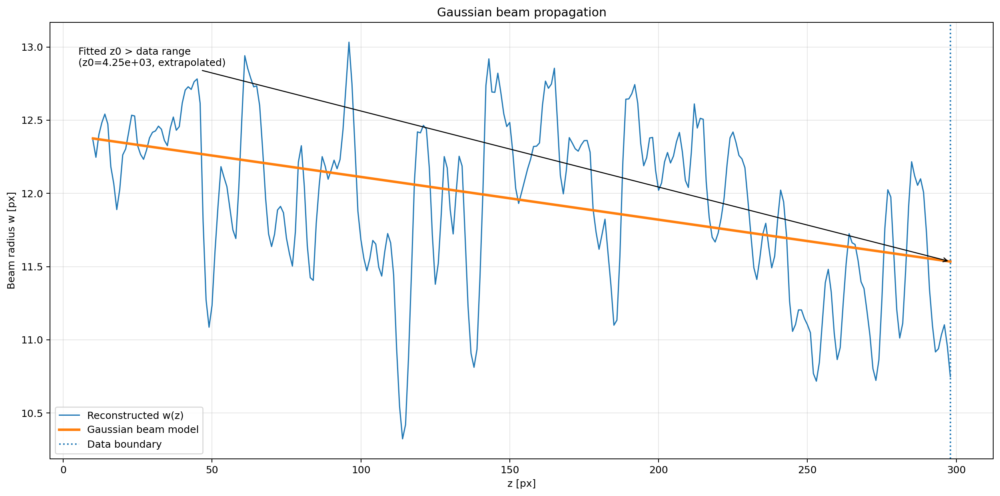

In [71]:
propagation_basex_full = (
    fit_gaussian_beam_propagation(
        profiles_basex_full,
        pixel_size=(
            resolve_pixel_scale_um(ANALYSIS_CONFIG["calibration"]) / LENGTH_UNITS_UM[ANALYSIS_CONFIG["calibration"].get("display_unit", "um")]
            if resolve_pixel_scale_um(ANALYSIS_CONFIG["calibration"]) is not None else None
        ),
        display_unit=(ANALYSIS_CONFIG["calibration"].get("display_unit", "px") if ANALYSIS_CONFIG["calibration"].get("enabled", False) else "px")
    )
)

propagation_hl_full = (
    fit_gaussian_beam_propagation(
        profiles_hl_full,
        pixel_size=(
            resolve_pixel_scale_um(ANALYSIS_CONFIG["calibration"]) / LENGTH_UNITS_UM[ANALYSIS_CONFIG["calibration"].get("display_unit", "um")]
            if resolve_pixel_scale_um(ANALYSIS_CONFIG["calibration"]) is not None else None
        ),
        display_unit=(ANALYSIS_CONFIG["calibration"].get("display_unit", "px") if ANALYSIS_CONFIG["calibration"].get("enabled", False) else "px")
    )
)

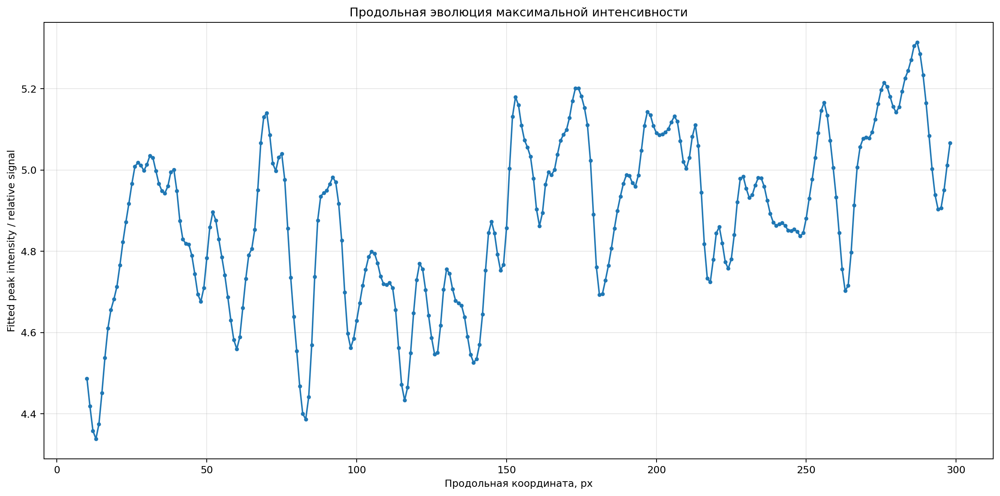

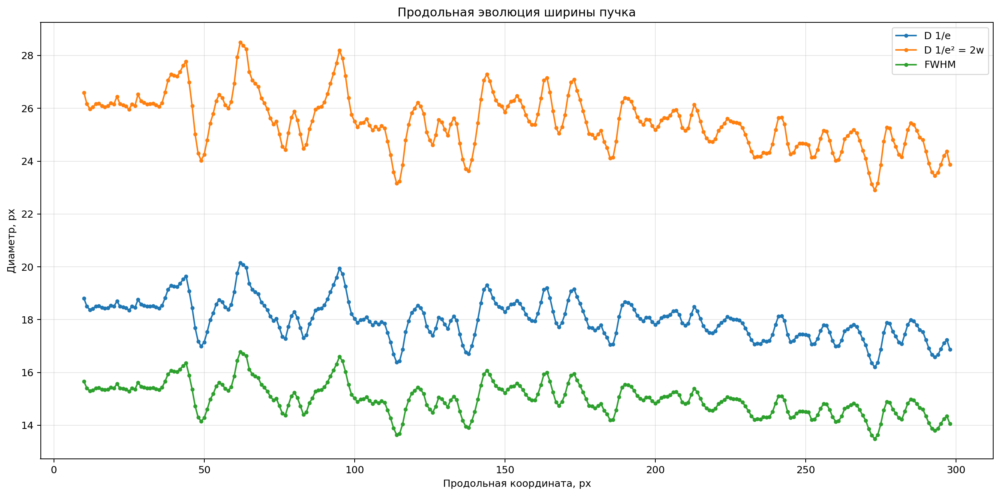

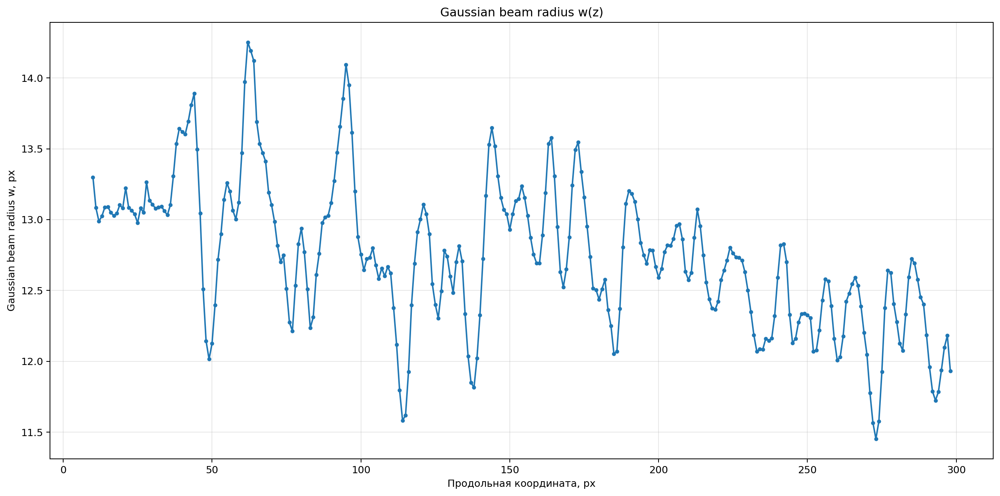

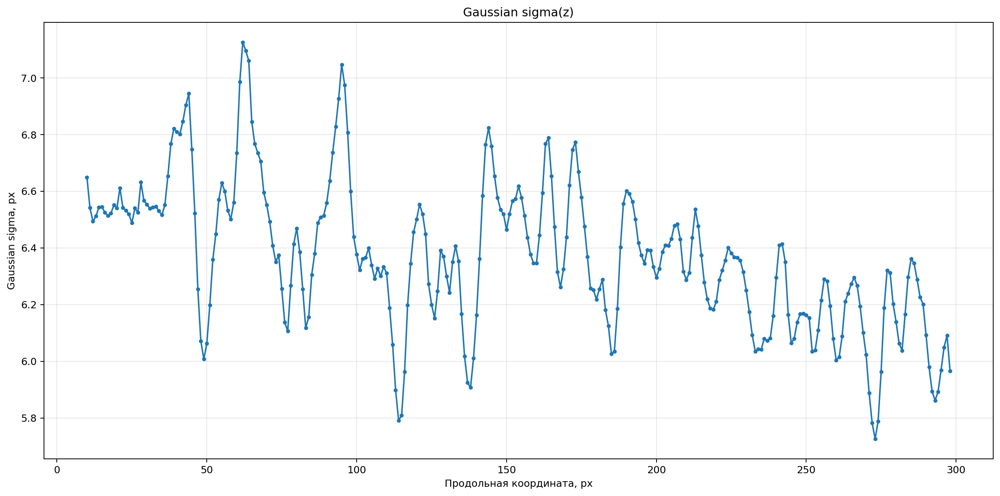

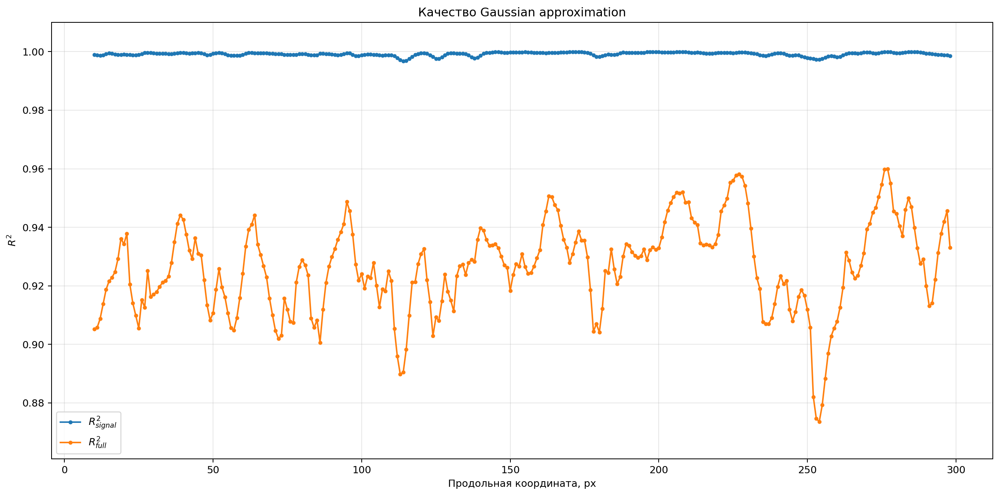

...

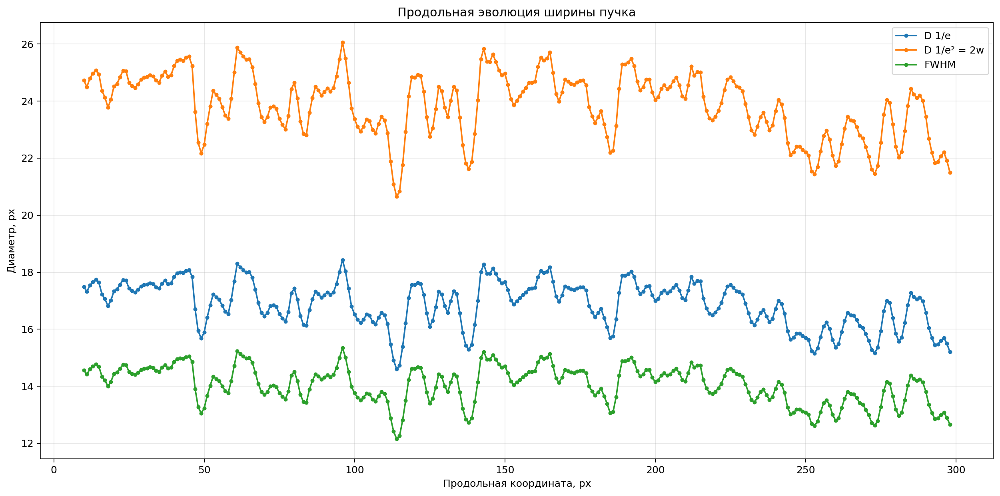

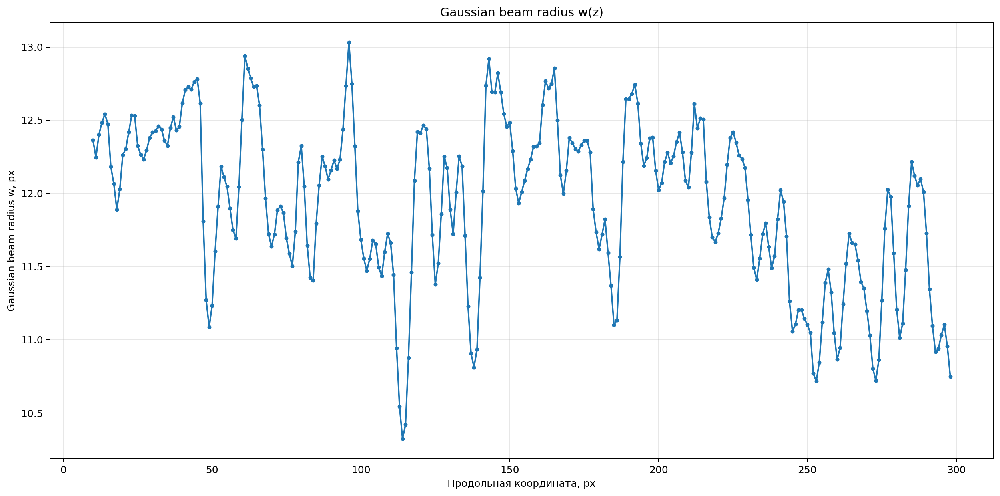

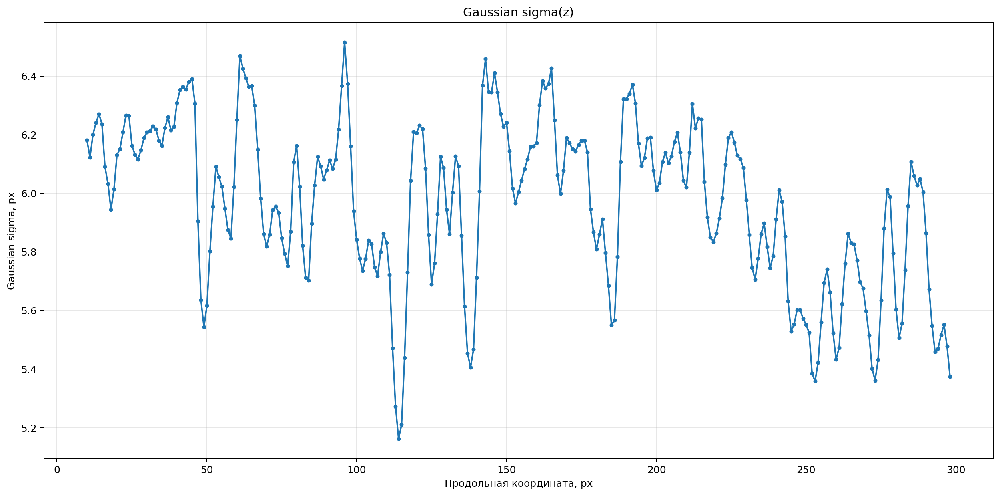

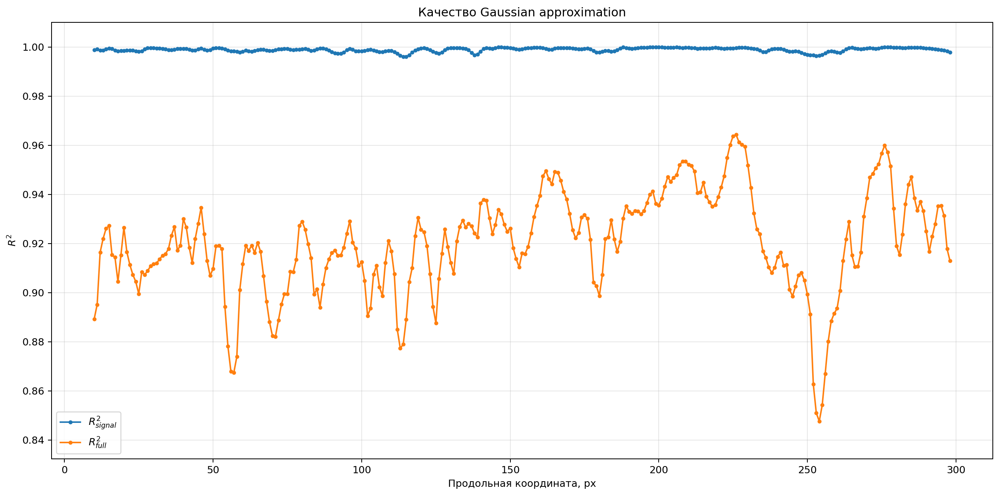

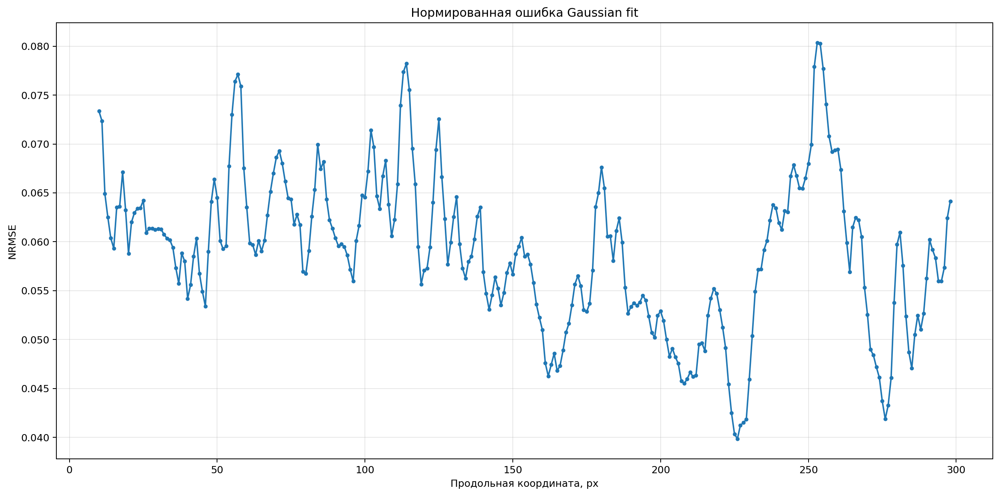

In [72]:
beam_parameters_basex_full = plot_beam_parameters(
    profiles_basex_full,
    pixel_size=(resolve_pixel_scale_um(ANALYSIS_CONFIG["calibration"]) / LENGTH_UNITS_UM[ANALYSIS_CONFIG["calibration"].get("display_unit", "um")] if resolve_pixel_scale_um(ANALYSIS_CONFIG["calibration"]) is not None else None),
    unit=(ANALYSIS_CONFIG["calibration"].get("display_unit", "px") if ANALYSIS_CONFIG["calibration"].get("enabled", False) else "px"),
    radiometry=ANALYSIS_CONFIG["radiometry"],
    figsize=(14,7), dpi=180
)

beam_parameters_hl_full = plot_beam_parameters(
    profiles_hl_full,
    pixel_size=(resolve_pixel_scale_um(ANALYSIS_CONFIG["calibration"]) / LENGTH_UNITS_UM[ANALYSIS_CONFIG["calibration"].get("display_unit", "um")] if resolve_pixel_scale_um(ANALYSIS_CONFIG["calibration"]) is not None else None),
    unit=(ANALYSIS_CONFIG["calibration"].get("display_unit", "px") if ANALYSIS_CONFIG["calibration"].get("enabled", False) else "px"),
    radiometry=ANALYSIS_CONFIG["radiometry"],
    figsize=(14,7), dpi=180
)

=== BASEX vs Hansen–Law ===
Сравнено сечений: 289
Среднее абсолютное различие: 6.584%
Максимальное абсолютное различие: 11.946%


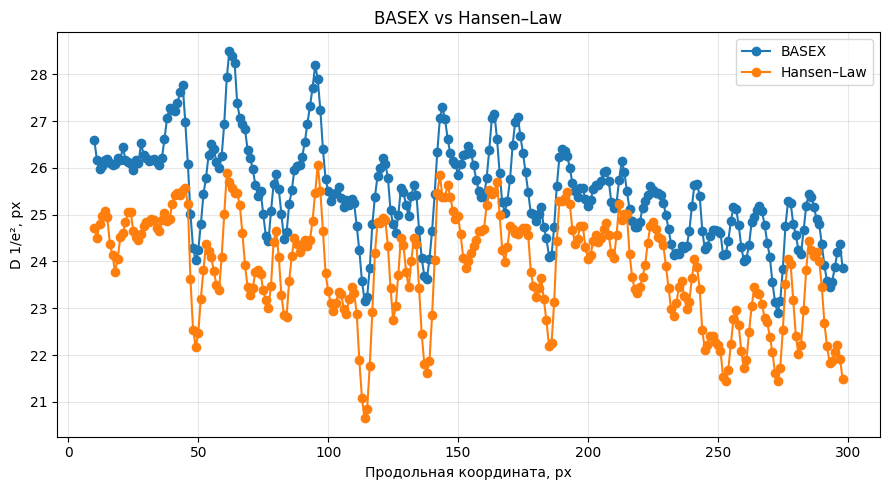

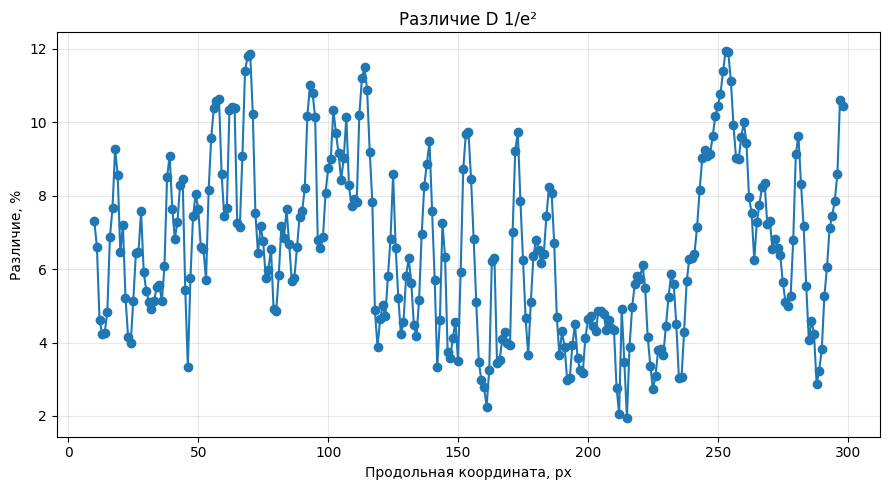

In [73]:
abel_method_comparison_full = (
    compare_basex_hansenlaw(
        profiles_basex_full,
        profiles_hl_full
    )
)

In [74]:
waist_basex_full = find_beam_waist(
    profiles_basex_full
)

waist_hl_full = find_beam_waist(
    profiles_hl_full
)

=== Observed beam-width minimum ===
z_min_observed = 273 px
w_min_observed = 11.4531 px
z_min_observed_subpixel ≈ 272.976 px
w_min_observed_subpixel ≈ 11.453 px
Это наблюдаемый минимум w(z); model-fitted propagation z0 — отдельный параметр.
=== Observed beam-width minimum ===
z_min_observed = 114 px
w_min_observed = 10.3241 px
z_min_observed_subpixel ≈ 114.196 px
w_min_observed_subpixel ≈ 10.3181 px
Это наблюдаемый минимум w(z); model-fitted propagation z0 — отдельный параметр.


In [75]:
# ============================================================
# METROLOGY / UNCERTAINTY / PSF SUMMARY
# ============================================================

calibration_info = calibration_summary(ANALYSIS_CONFIG["calibration"])

psf_profiles_basex_full = apply_psf_metadata(
    profiles_basex_full,
    ANALYSIS_CONFIG["psf"]
)
psf_profiles_hl_full = apply_psf_metadata(
    profiles_hl_full,
    ANALYSIS_CONFIG["psf"]
)

method_rel = float(abel_method_comparison_full.get("mean_difference_percent", np.nan)) / 100.0

target_z=float(np.median([x["z_index"] for x in profiles_basex_full]))
central_valid=[x for x in profiles_basex_full if x.get("success",False) and np.isfinite(x.get("diameter_1e2",np.nan))]
if central_valid:
    reference_item=min(central_valid,key=lambda x:abs(float(x["z_index"])-target_z))
    reference_d=float(reference_item.get("diameter_1e2",np.nan))
else:
    reference_d=np.nan

uncertainty_budget = build_sensitivity_uncertainty_budget(
    reference_d,
    sigma_results=sigma_results,
    center_results=center_results,
    regularization_results=reg_results_physical,
    method_relative_difference=method_rel,
    calibration_relative_uncertainty=calibration_info.get("relative_uncertainty") or 0.0,
)

print("=== METROLOGY SUMMARY ===")
print("Calibration:", calibration_info)
print("PSF correction enabled:", ANALYSIS_CONFIG["psf"]["enabled"])
print("Radiometric calibration enabled:", ANALYSIS_CONFIG["radiometry"]["enabled"])
print("Sensitivity-based uncertainty budget:", uncertainty_budget)


=== METROLOGY SUMMARY ===
Calibration: {'enabled': False, 'pixel_size_um': None, 'display_unit': 'px', 'relative_uncertainty': None, 'method': 'direct'}
PSF correction enabled: False
Radiometric calibration enabled: False
Sensitivity-based uncertainty budget: {'status': 'available', 'reference_value': 26.47453894795363, 'relative_sensitivity_envelope_rss': 0.12214270310276128, 'sensitivity_envelope_k2': 0.24428540620552255, 'absolute_sensitivity_envelope_k2': 6.46734350100478, 'components': {'preprocessing_sigma': 0.05612673181508769, 'abel_center': 0.040301097313186554, 'basex_regularization': 0.09518736861655605, 'method_difference': 0.03292136552780672, 'calibration': 0.0}, 'is_traceable_gum_uncertainty': False, 'note': 'Engineering sensitivity envelope assembled from observed parameter ranges; not a metrologically traceable ISO/GUM uncertainty budget.'}


In [76]:
from dataclasses import dataclass, field
from typing import Any


@dataclass
class BeamAnalysisResult:
    """
    Единый контейнер всех результатов анализа пучка.

    Используется как промежуточный API между
    научным ядром и будущим GUI.
    """

    # --------------------------------------------------------
    # Images
    # --------------------------------------------------------

    raw_image: Any = None
    aligned_image: Any = None
    processed_image: Any = None

    basex_image: Any = None
    hansenlaw_image: Any = None

    # --------------------------------------------------------
    # Metadata
    # --------------------------------------------------------

    image_shape: tuple | None = None

    # --------------------------------------------------------
    # Alignment
    # --------------------------------------------------------

    alignment: dict = field(
        default_factory=dict
    )

    # --------------------------------------------------------
    # Preprocessing
    # --------------------------------------------------------

    preprocessing: dict = field(
        default_factory=dict
    )

    # --------------------------------------------------------
    # Abel center
    # --------------------------------------------------------

    center: dict = field(
        default_factory=dict
    )

    # --------------------------------------------------------
    # Symmetry
    # --------------------------------------------------------

    symmetry: dict = field(
        default_factory=dict
    )

    # --------------------------------------------------------
    # Abel methods
    # --------------------------------------------------------

    abel: dict = field(
        default_factory=dict
    )

    # --------------------------------------------------------
    # Longitudinal profiles
    # --------------------------------------------------------

    profiles_basex: list = field(
        default_factory=list
    )

    profiles_hansenlaw: list = field(
        default_factory=list
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    validation: dict = field(
        default_factory=dict
    )

    # --------------------------------------------------------
    # Waist
    # --------------------------------------------------------

    waist: dict = field(
        default_factory=dict
    )

    # --------------------------------------------------------
    # Propagation
    # --------------------------------------------------------

    propagation: dict = field(
        default_factory=dict
    )

    # --------------------------------------------------------
    # Configuration
    # --------------------------------------------------------

    config: dict = field(
        default_factory=dict
    )

    psf_profiles_basex: list = field(default_factory=list)
    psf_profiles_hansenlaw: list = field(default_factory=list)
    metrology: dict = field(default_factory=dict)
    camera: dict = field(default_factory=dict)

    audit: dict = field(
        default_factory=dict
    )

In [78]:
validate_calibration_config(ANALYSIS_CONFIG["calibration"])

analysis_result = BeamAnalysisResult(
    raw_image=test_image,
    aligned_image=centered_img,
    processed_image=ready_for_abel,
    basex_image=abel_image_basex,
    hansenlaw_image=abel_image_hl,
    image_shape=test_image.shape,
    alignment=alignment_info,
    preprocessing=preprocess_info,
    center={"selected_x": float(abel_center_x), "methods": center_comparison},
    symmetry=symmetry_metrics,
    abel={
        "basex_regularization": ANALYSIS_CONFIG["basex"]["regularization"],
        "basex_result_shape": abel_image_basex.shape,
        "hansenlaw_result_shape": abel_image_hl.shape
    },
    profiles_basex=profiles_basex_full,
    profiles_hansenlaw=profiles_hl_full,
    validation={"basex_hansenlaw": abel_method_comparison_full},
    waist={"basex": waist_basex_full, "hansenlaw": waist_hl_full},
    propagation={"basex": propagation_basex_full, "hansenlaw": propagation_hl_full},
    config=deepcopy(ANALYSIS_CONFIG),
    psf_profiles_basex=psf_profiles_basex_full,
    psf_profiles_hansenlaw=psf_profiles_hl_full,
    metrology={"calibration": calibration_info, "uncertainty_budget": uncertainty_budget, "psf": ANALYSIS_CONFIG["psf"], "radiometry": ANALYSIS_CONFIG["radiometry"]},
    camera={"acquisition": saturation_info, "correction": camera_correction_info},
    audit={}
)
validate_calibration_config(ANALYSIS_CONFIG["calibration"])

analysis_result = BeamAnalysisResult(
    raw_image=test_image,
    aligned_image=centered_img,
    processed_image=ready_for_abel,
    basex_image=abel_image_basex,
    hansenlaw_image=abel_image_hl,
    image_shape=test_image.shape,
    alignment=alignment_info,
    preprocessing=preprocess_info,
    center={"selected_x": float(abel_center_x), "methods": center_comparison},
    symmetry=symmetry_metrics,
    abel={
        "basex_regularization": ANALYSIS_CONFIG["basex"]["regularization"],
        "basex_result_shape": abel_image_basex.shape,
        "hansenlaw_result_shape": abel_image_hl.shape
    },
    profiles_basex=profiles_basex_full,
    profiles_hansenlaw=profiles_hl_full,
    validation={"basex_hansenlaw": abel_method_comparison_full},
    waist={"basex": waist_basex_full, "hansenlaw": waist_hl_full},
    propagation={"basex": propagation_basex_full, "hansenlaw": propagation_hl_full},
    config=deepcopy(ANALYSIS_CONFIG),
    psf_profiles_basex=psf_profiles_basex_full,
    psf_profiles_hansenlaw=psf_profiles_hl_full,
    metrology={"calibration": calibration_info, "uncertainty_budget": uncertainty_budget, "psf": ANALYSIS_CONFIG["psf"], "radiometry": ANALYSIS_CONFIG["radiometry"]},
    camera={"acquisition": saturation_info, "correction": camera_correction_info},
    audit={}
)
analysis_result.metrology = {
    "calibration": calibration_info,
    "uncertainty_budget": uncertainty_budget,
    "psf": ANALYSIS_CONFIG["psf"],
    "radiometry": ANALYSIS_CONFIG["radiometry"],
}
analysis_result.camera = {
    "acquisition": saturation_info,
    "correction": camera_correction_info,
}



In [79]:
print(
    "BeamAnalysisResult created."
)

print(
    "Raw:",
    analysis_result.raw_image.shape
)

print(
    "BASEX:",
    analysis_result.basex_image.shape
)

print(
    "BASEX profiles:",
    len(
        analysis_result.profiles_basex
    )
)

print(
    "Hansen-Law profiles:",
    len(
        analysis_result.profiles_hansenlaw
    )
)

BeamAnalysisResult created.
Raw: (309, 269)
BASEX: (309, 267)
BASEX profiles: 289
Hansen-Law profiles: 289


In [80]:
def scientific_audit_report(alignment_info, symmetry_metrics, abel_method_comparison_full,
                           propagation_basex_full, propagation_hl_full,
                           waist_basex_full, waist_hl_full,
                           profile_results_basex, profile_results_hl,
                           calibration_info=None, saturation_info=None,
                           uncertainty_budget=None, side_consistency_3d=None):
    """Сводный QA/QC отчёт научного анализа + метрология."""
    print("=== SCIENTIFIC QA / QC REPORT ===")
    axis_rms=float(alignment_info.get("axis_rms_error",np.nan))
    corr=float(symmetry_metrics.get("correlation",np.nan))
    asym=float(symmetry_metrics.get("normalized_rms",np.nan))
    mean_diff=float(abel_method_comparison_full.get("mean_difference_percent",np.nan)/100.0)
    max_diff=float(abel_method_comparison_full.get("max_difference_percent",np.nan)/100.0)
    print(f"[ALIGNMENT] RMS axis error = {axis_rms:.4g} px")
    print(f"[SYMMETRY] correlation = {corr:.6f}; normalized RMS asymmetry = {asym:.6f}")
    print(f"[ABEL] BASEX vs Hansen-Law: mean = {mean_diff:.3%}; max = {max_diff:.3%}")
    print(f"[GAUSSIAN] BASEX successful fits = {sum(x.get('success',False) for x in profile_results_basex)}/{len(profile_results_basex)}")
    print(f"[GAUSSIAN] Hansen-Law successful fits = {sum(x.get('success',False) for x in profile_results_hl)}/{len(profile_results_hl)}")
    print(f"[PROPAGATION/BASEX] R²={propagation_basex_full['r_squared']:.4f}; ΔBIC={propagation_basex_full['delta_bic']:.4f}; z0_inside={propagation_basex_full['z0_inside_data']}")
    print(f"[PROPAGATION/HL] R²={propagation_hl_full['r_squared']:.4f}; ΔBIC={propagation_hl_full['delta_bic']:.4f}; z0_inside={propagation_hl_full['z0_inside_data']}")
    dz=abs(float(waist_basex_full['z_min_observed'])-float(waist_hl_full['z_min_observed']))
    print(f"[OBSERVED WAIST] BASEX z_min={waist_basex_full['z_min_observed']:.3f} px; HL z_min={waist_hl_full['z_min_observed']:.3f} px; |Δz|={dz:.3f} px")
    if calibration_info:
        print(f"[CALIBRATION] enabled={calibration_info['enabled']}; scale={calibration_info['pixel_size_um']} µm/px; display={calibration_info['display_unit']}")
    if saturation_info:
        print(f"[SATURATION] status={saturation_info['status']}; saturated_fraction={saturation_info['saturated_fraction']:.3%}")
    if side_consistency_3d:
        print(f"[3D POST-SYMMETRIZATION CHECK] RMS={side_consistency_3d['normalized_rms_difference']:.3%}; corr={side_consistency_3d['correlation']:.6f}")
    if uncertainty_budget and uncertainty_budget.get('status') == 'available':
        print(f"[UNCERTAINTY] sensitivity envelope ×2 = ±{uncertainty_budget['absolute_sensitivity_envelope_k2']:.5g} in the reference width")
    print("Sensitivity — это оценка устойчивости, а не автоматический выбор параметра.")
    print("Propagation z0 и observed z_min — разные физические величины и не должны называться одинаково в отчёте.")
    return {"axis_rms_px":axis_rms,"symmetry_correlation":corr,"symmetry_rms_asymmetry":asym,
            "method_mean_relative_difference":mean_diff,"method_max_relative_difference":max_diff,
            "waist_z_difference_px":dz,
            "calibration":calibration_info,"saturation":saturation_info,
            "uncertainty_budget":uncertainty_budget,"side_consistency_3d":side_consistency_3d}

scientific_audit=scientific_audit_report(
    alignment_info, symmetry_metrics, abel_method_comparison_full,
    propagation_basex_full, propagation_hl_full,
    waist_basex_full, waist_hl_full,
    profiles_basex_full, profiles_hl_full,
    calibration_info=calibration_info,
    saturation_info=saturation_info,
    uncertainty_budget=uncertainty_budget,
    side_consistency_3d=side_consistency_3d
)
analysis_result.audit = scientific_audit


=== SCIENTIFIC QA / QC REPORT ===
[ALIGNMENT] RMS axis error = 0.2869 px
[SYMMETRY] correlation = 0.986099; normalized RMS asymmetry = 0.108607
[ABEL] BASEX vs Hansen-Law: mean = 6.584%; max = 11.946%
[GAUSSIAN] BASEX successful fits = 289/289
[GAUSSIAN] Hansen-Law successful fits = 289/289
[PROPAGATION/BASEX] R²=0.3172; ΔBIC=98.9469; z0_inside=False
[PROPAGATION/HL] R²=0.1758; ΔBIC=44.5549; z0_inside=False
[OBSERVED WAIST] BASEX z_min=273.000 px; HL z_min=114.000 px; |Δz|=159.000 px
[CALIBRATION] enabled=False; scale=None µm/px; display=px
[SATURATION] status=OK; saturated_fraction=0.000%
[3D POST-SYMMETRIZATION CHECK] RMS=0.000%; corr=1.000000
[UNCERTAINTY] sensitivity envelope ×2 = ±6.4673 in the reference width
Sensitivity — это оценка устойчивости, а не автоматический выбор параметра.
Propagation z0 и observed z_min — разные физические величины и не должны называться одинаково в отчёте.


In [81]:
def profiles_to_dataframe(profile_results, calibration=None):
    """Преобразует результаты Gaussian fit в pandas.DataFrame с pixel + physical units."""
    rows=[]
    scale_um = resolve_pixel_scale_um(calibration) if calibration else None
    unit = (calibration or {}).get("display_unit", "px") if calibration else "px"
    for item in profile_results:
        row = {
            "z_px": item.get("z_index",np.nan), "success":item.get("success",False),
            "amplitude":item.get("amplitude",np.nan), "peak_intensity":item.get("peak_intensity",np.nan),
            "baseline":item.get("baseline",np.nan), "r0_px":item.get("r0",np.nan),
            "sigma_px":item.get("sigma",np.nan), "w_px":item.get("beam_radius_w",np.nan),
            "D_1e_px":item.get("diameter_1e",np.nan), "D_1e2_px":item.get("diameter_1e2",np.nan),
            "FWHM_px":item.get("fwhm",np.nan), "R2_signal":item.get("r_squared_signal",np.nan),
            "R2_full":item.get("r_squared_full",np.nan), "NRMSE_full":item.get("nrmse_full",np.nan),
            "max_abs_residual":item.get("max_abs_residual_full",np.nan),
            "peak_intensity_W_cm2": (radiometric_convert_intensity(item.get("peak_intensity",np.nan), ANALYSIS_CONFIG["radiometry"]) if ANALYSIS_CONFIG["radiometry"].get("enabled", False) else np.nan),
        }
        if scale_um is not None:
            factor = scale_um / LENGTH_UNITS_UM[unit]
            row[f"z_{unit}"] = row["z_px"] * factor
            row[f"r0_{unit}"] = row["r0_px"] * factor
            row[f"sigma_{unit}"] = row["sigma_px"] * factor
            row[f"w_{unit}"] = row["w_px"] * factor
            row[f"D_1e_{unit}"] = row["D_1e_px"] * factor
            row[f"D_1e2_{unit}"] = row["D_1e2_px"] * factor
            row[f"FWHM_{unit}"] = row["FWHM_px"] * factor
            row[f"w_psf_corrected_{unit}"] = item.get("beam_radius_w_psf_corrected",np.nan) * factor
            row[f"D_1e2_psf_corrected_{unit}"] = item.get("diameter_1e2_psf_corrected",np.nan) * factor
        rows.append(row)
    return pd.DataFrame(rows)


In [82]:
df_basex = profiles_to_dataframe(profiles_basex_full, ANALYSIS_CONFIG["calibration"])
df_hl = profiles_to_dataframe(profiles_hl_full, ANALYSIS_CONFIG["calibration"])
print("BASEX DataFrame shape:", df_basex.shape)
print("Hansen-Law DataFrame shape:", df_hl.shape)
display(df_basex.head())
# Explicit export examples:
# df_basex.to_csv("profiles_basex.csv", index=False)
# df_hl.to_csv("profiles_hansenlaw.csv", index=False)


BASEX DataFrame shape: (289, 16)
Hansen-Law DataFrame shape: (289, 16)


,z_px,success,amplitude,peak_intensity,baseline,r0_px,sigma_px,w_px,D_1e_px,D_1e2_px,FWHM_px,R2_signal,R2_full,NRMSE_full,max_abs_residual,peak_intensity_W_cm2
0,10,True,4.133645,4.487209,0.353564,1.038330,6.649740,13.299480,18.808304,26.598959,15.658940,0.998890,0.905241,0.070059,0.385505,NaN
1,11,True,4.067778,4.418752,0.350973,1.329627,6.541493,13.082985,18.502135,26.165971,15.404038,0.998850,0.905714,0.070708,0.373598,NaN
2,12,True,4.015209,4.358204,0.342994,1.510668,6.494131,12.988261,18.368175,25.976522,15.292509,0.998689,0.908772,0.069925,0.367476,NaN
3,13,True,4.005926,4.338479,0.332553,1.514989,6.511921,13.023842,18.418494,26.047684,15.334402,0.998776,0.913774,0.067890,0.356824,NaN
4,14,True,4.050356,4.374734,0.324379,1.386632,6.544112,13.088224,18.509544,26.176448,15.410206,0.999156,0.918703,0.065523,0.345490,NaN
